In [3]:
# ============================================================
# PRÉTRAITEMENT COMPLET — GESTION NA PAR MOYENNE MENSUELLE
# Version Python
# ============================================================

# ── 1. Importation des bibliothèques ────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.stats import genextreme, kstest
import warnings
warnings.filterwarnings('ignore')

# Pour les tests statistiques
from pymannkendall import original_test as mk_test
from statsmodels.tsa.stattools import adfuller, kpss
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import genextreme
from scipy.special import gamma


In [4]:
# ── 2. Importation de la base ────────────────────────────────
debits = pd.read_excel(
    "C:/Users/LENOVO/Desktop/FATOU/Débits.xlsx"
)

# Nettoyage des noms de colonnes
debits.columns = (debits.columns
                  .str.lower()
                  .str.replace(r'[^a-z0-9_]', '_', regex=True)
                  .str.replace(r'_+', '_', regex=True)
                  .str.strip('_'))

print("Colonnes :", debits.columns.tolist())

# Conversion de la date
debits['date'] = pd.to_datetime(debits['date'])
debits['annee'] = debits['date'].dt.year
debits['mois']  = debits['date'].dt.month
debits['jour']  = debits['date'].dt.day

cols_debits = ['daka_saidou_d_j1__m3_s_',
               'gourbassi_d_j1__m3_s_',
               'kidira_d_j1__m3_s_',
               'oualia_d_j1__m3_s_']

# Renommage pour simplifier
debits.rename(columns={
    cols_debits[0]: 'dakasaidou_debits',
    cols_debits[1]: 'gourbassi_debits',
    cols_debits[2]: 'kidira_debits',
    cols_debits[3]: 'oualia_debits'
}, inplace=True)

cols_debits = ['dakasaidou_debits', 'gourbassi_debits',
               'kidira_debits', 'oualia_debits']
noms_stations = ['Daka Saidou', 'Gourbassi',
                 'Kidira', 'Oualia']
couleurs = {'Daka Saidou': '#2166ac',
            'Gourbassi':   '#4dac26',
            'Kidira':      '#d01c8b',
            'Oualia':      '#f4a582'}

print("\n=== NA avant traitement ===")
print(debits[cols_debits].isna().sum())


Colonnes : ['date', 'dakasaidou_debits', 'gourbassi_debits', 'kidira_debits', 'oualia_debits']

=== NA avant traitement ===
dakasaidou_debits     941
gourbassi_debits      945
kidira_debits        1829
oualia_debits        1621
dtype: int64


In [5]:
# ============================================================
# GESTION DES NA — MOYENNE CLIMATOLOGIQUE MENSUELLE
# ============================================================
for col in cols_debits:
    debits[col] = debits.groupby('mois')[col].transform(
        lambda x: x.fillna(x.mean())
    )

print("\n=== NA après imputation par moyenne mensuelle ===")
print(debits[cols_debits].isna().sum())

# Année hydrologique
debits['annee_hydro'] = np.where(
    debits['mois'] >= 5,
    debits['annee'],
    debits['annee'] - 1
)

# Vérification NA par année hydrologique
check_na = (debits.groupby('annee_hydro')[cols_debits]
            .apply(lambda x: x.isna().sum())
            .loc[lambda x: (x > 0).any(axis=1)])

if len(check_na) == 0:
    print("✔ Zéro NA résiduel — toutes les années complètes !")
    annees_exclure = []
else:
    print("⚠ NA résiduels détectés :")
    print(check_na)
    annees_exclure = check_na.index.tolist()

# Suppression doublons et tri
debits = debits.drop_duplicates().sort_values('date')
debits.to_csv("debits_propres.csv", index=False)
print("✔ Base propre sauvegardée.")


=== NA après imputation par moyenne mensuelle ===
dakasaidou_debits    0
gourbassi_debits     0
kidira_debits        0
oualia_debits        0
dtype: int64
✔ Zéro NA résiduel — toutes les années complètes !
✔ Base propre sauvegardée.


In [6]:
# ============================================================
# ÉTAPE 2 — DÉTECTION DES VALEURS ABERRANTES
# ============================================================
print("\n=== Valeurs négatives par station ===")
print((debits[cols_debits] < 0).sum())

print("\n=== Bornes IQR et valeurs aberrantes ===")
for col, nom in zip(cols_debits, noms_stations):
    x         = debits[col].dropna()
    Q1        = x.quantile(0.25)
    Q3        = x.quantile(0.75)
    iqr       = Q3 - Q1
    borne_inf = Q1 - 1.5 * iqr
    borne_sup = Q3 + 1.5 * iqr
    n_inf     = (x < borne_inf).sum()
    n_sup     = (x > borne_sup).sum()
    print(f"\n-- {nom} --")
    print(f"   Q1={Q1:.2f} | Q3={Q3:.2f} | IQR={iqr:.2f}")
    print(f"   Borne inf={borne_inf:.2f} | Borne sup={borne_sup:.2f}")
    print(f"   Valeurs < borne inf : {n_inf}")
    print(f"   Valeurs > borne sup : {n_sup} (conservées)")


=== Valeurs négatives par station ===
dakasaidou_debits    0
gourbassi_debits     0
kidira_debits        0
oualia_debits        0
dtype: int64

=== Bornes IQR et valeurs aberrantes ===

-- Daka Saidou --
   Q1=16.85 | Q3=304.00 | IQR=287.15
   Borne inf=-413.87 | Borne sup=734.72
   Valeurs < borne inf : 0
   Valeurs > borne sup : 1414 (conservées)

-- Gourbassi --
   Q1=0.18 | Q3=76.92 | IQR=76.74
   Borne inf=-114.94 | Borne sup=192.04
   Valeurs < borne inf : 0
   Valeurs > borne sup : 2544 (conservées)

-- Kidira --
   Q1=1.61 | Q3=92.42 | IQR=90.81
   Borne inf=-134.59 | Borne sup=228.63
   Valeurs < borne inf : 0
   Valeurs > borne sup : 2585 (conservées)

-- Oualia --
   Q1=0.00 | Q3=77.54 | IQR=77.54
   Borne inf=-116.31 | Borne sup=193.85
   Valeurs < borne inf : 0
   Valeurs > borne sup : 2513 (conservées)



=== Plage des années hydrologiques ===
De 1971 à 2019

✔ Nombre d'années hydrologiques retenues : 49
    annee_hydro  daka_saidou_max  gourbassi_max   kidira_max   oualia_max
0          1971      1180.000000    1111.000000  1438.000000  1379.000000
1          1972      1137.000000     415.299988   404.899994   246.300003
2          1973       991.400024     677.500000   792.099976   915.700012
3          1974      1279.000000    1610.000000  2239.000000  2005.000000
4          1975      1218.000000    1401.000000  1536.000000   952.700012
5          1976      1396.000000     422.100006   393.299988   643.700012
6          1977       797.200012     593.700012   663.099976   573.799988
7          1978       949.000000    1080.000000  1258.000000   617.599976
8          1979       641.500000     285.399994   777.900024   314.899994
9          1980      1354.000000     741.099976   825.500000   536.000000
10         1981      1081.000000     762.400024   793.400024   694.799988
11        

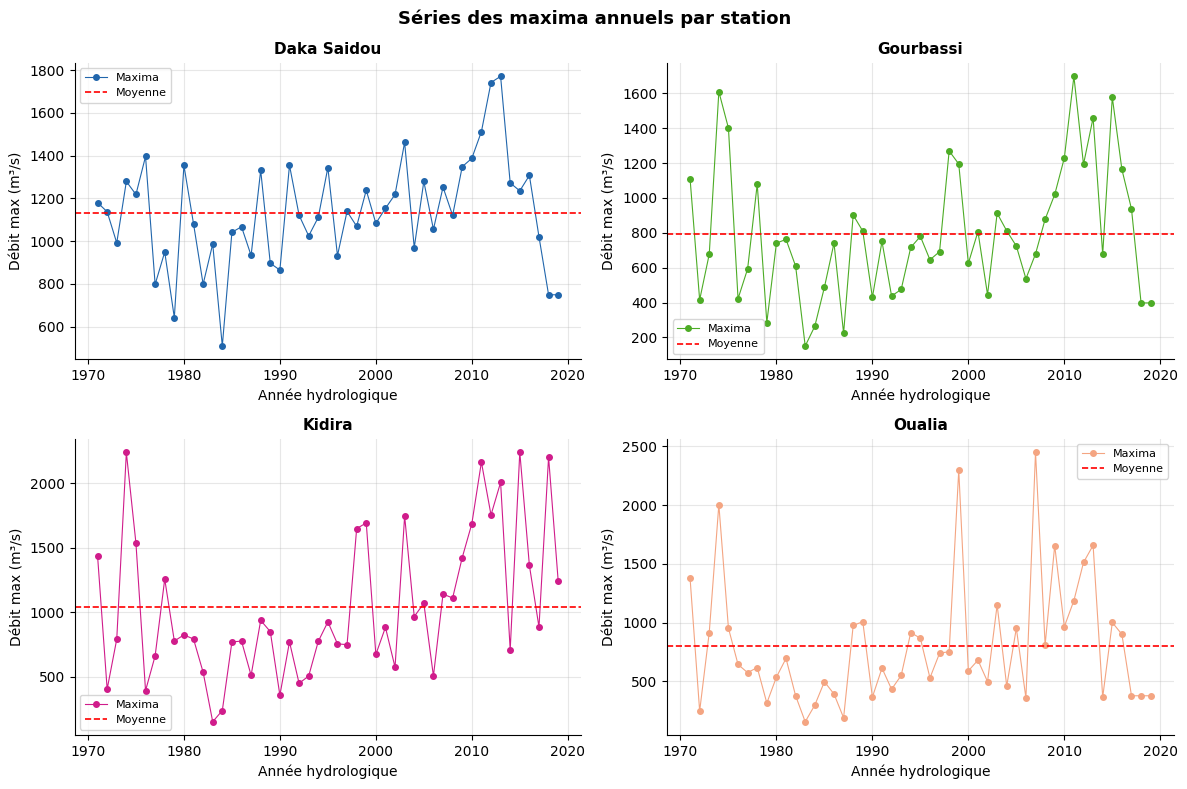

✔ Maxima annuels sauvegardés.


In [7]:
# ============================================================
# ÉTAPE 3 — EXTRACTION DES MAXIMA ANNUELS
# ============================================================
print(f"\n=== Plage des années hydrologiques ===")
print(f"De {debits['annee_hydro'].min()} à "
      f"{debits['annee_hydro'].max()}")

AM = (debits[~debits['annee_hydro'].isin(annees_exclure)]
      .groupby('annee_hydro')[cols_debits]
      .max()
      .reset_index())

AM.columns = ['annee_hydro', 'daka_saidou_max',
              'gourbassi_max', 'kidira_max', 'oualia_max']
AM = AM.sort_values('annee_hydro').reset_index(drop=True)

cols_max = ['daka_saidou_max', 'gourbassi_max',
            'kidira_max', 'oualia_max']

print(f"\n✔ Nombre d'années hydrologiques retenues : {len(AM)}")
print(AM)

# Figure maxima annuels
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (col, nom) in enumerate(zip(cols_max, noms_stations)):
    ax  = axes[i]
    moy = AM[col].mean()
    ax.plot(AM['annee_hydro'], AM[col],
            color=couleurs[nom], marker='o',
            markersize=4, linewidth=0.8, label='Maxima')
    ax.axhline(moy, color='red', linestyle='--',
               linewidth=1.2, label='Moyenne')
    ax.set_title(f"{nom}", fontweight='bold', fontsize=11)
    ax.set_xlabel("Année hydrologique")
    ax.set_ylabel("Débit max (m³/s)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle("Séries des maxima annuels par station",
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig("maxima_annuels.png", dpi=300,
            bbox_inches='tight')
plt.show()
AM.to_csv("maxima_annuels.csv", index=False)
print("✔ Maxima annuels sauvegardés.")



=== Seuils POT (95e percentile) ===
   Daka Saidou : 810.93 m³/s
   Gourbassi : 483.20 m³/s
   Kidira : 599.98 m³/s
   Oualia : 527.10 m³/s
Daka Saidou : 94 pics (seuil = 810.93)
Gourbassi : 68 pics (seuil = 483.20)
Kidira : 66 pics (seuil = 599.98)
Oualia : 47 pics (seuil = 527.10)
✔ Pics POT sauvegardés.


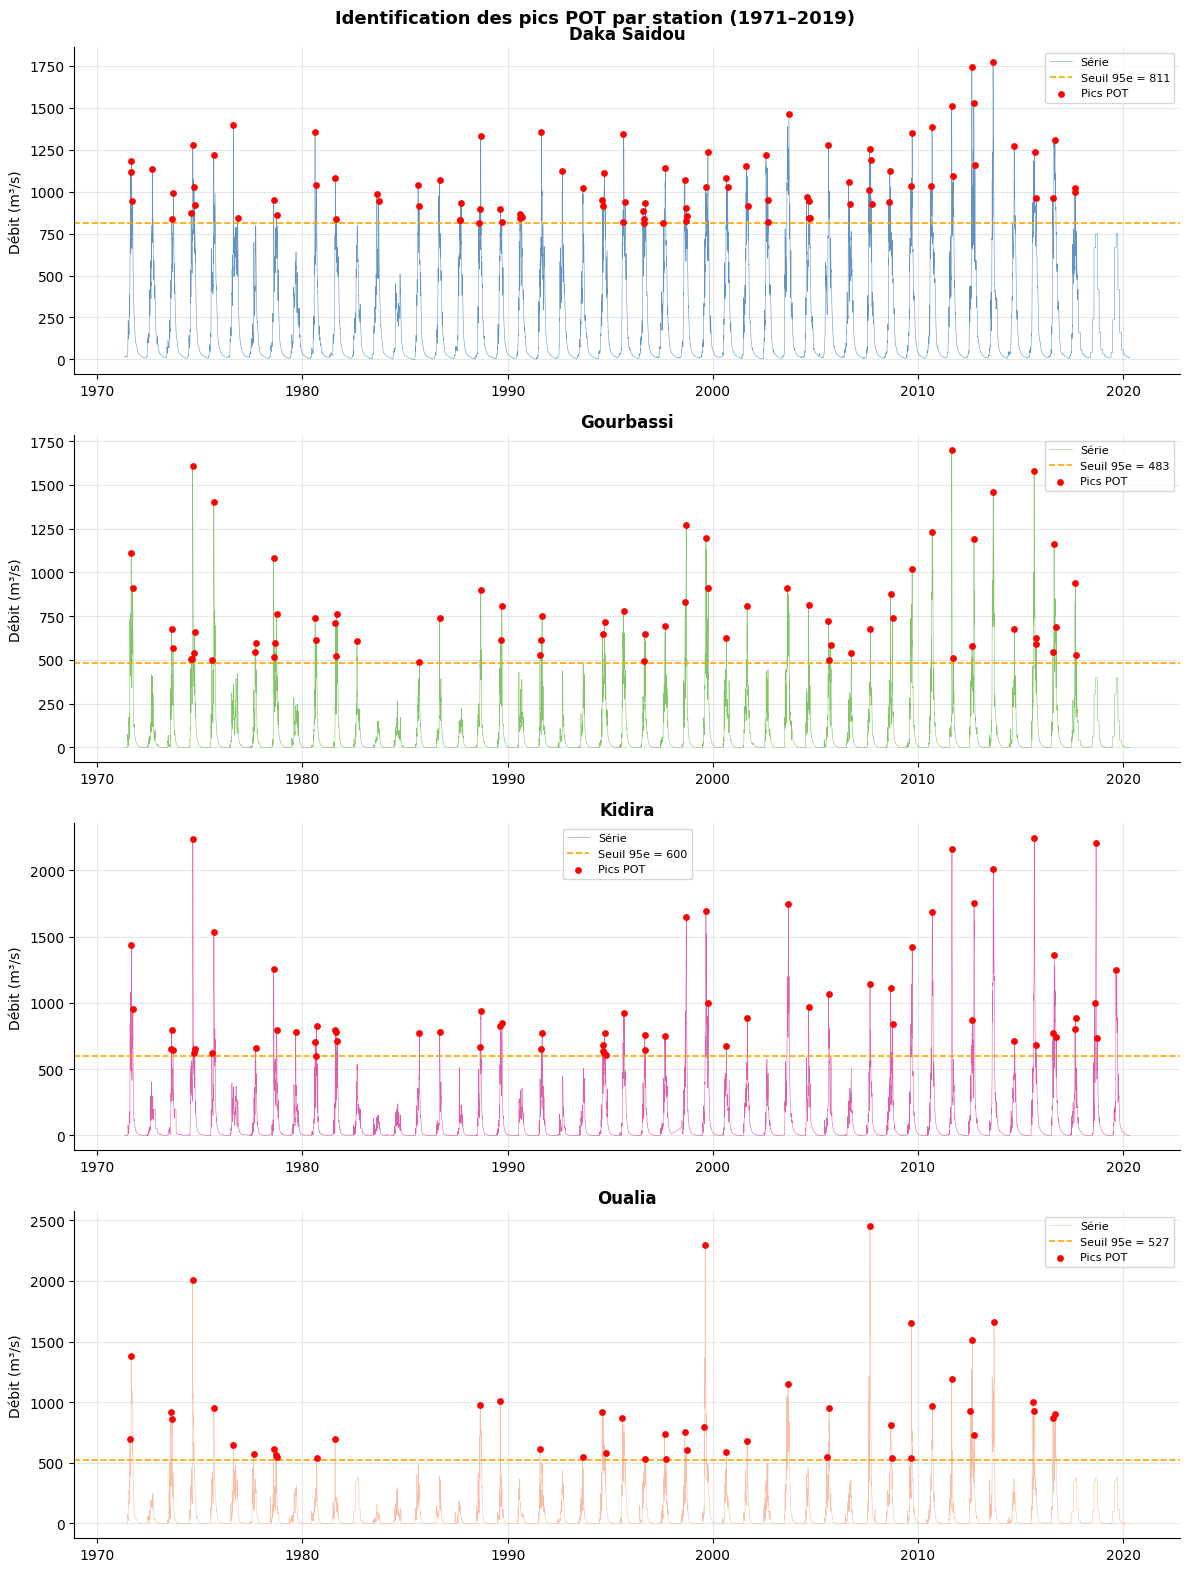

In [8]:

# ============================================================
# ÉTAPE 4 — EXTRACTION POT
# ============================================================
seuils = {col: debits[col][debits[col] > 0]
          .quantile(0.95)
          for col in cols_debits}

print("\n=== Seuils POT (95e percentile) ===")
for col, nom in zip(cols_debits, noms_stations):
    print(f"   {nom} : {seuils[col]:.2f} m³/s")

def decluster(dates, valeurs, seuil, gap=7):
    depasse    = np.where(
        (valeurs > seuil) & (~np.isnan(valeurs)))[0]
    if len(depasse) == 0:
        return pd.DataFrame(columns=['date', 'valeur'])
    pics_idx   = []
    groupe_idx = depasse[0]
    groupe_val = valeurs[depasse[0]]
    for i in range(1, len(depasse)):
        idx = depasse[i]
        ecart = (dates[idx] - dates[depasse[i-1]]) / np.timedelta64(1, 'D')
        if ecart < gap:
            if valeurs[idx] > groupe_val:
                groupe_idx = idx
                groupe_val = valeurs[idx]
        else:
            pics_idx.append(groupe_idx)
            groupe_idx = idx
            groupe_val = valeurs[idx]
    pics_idx.append(groupe_idx)
    return pd.DataFrame({
        'date':   dates[pics_idx],
        'valeur': valeurs[pics_idx]
    })

dates_arr = debits['date'].values
POT_list  = []

for col, nom in zip(cols_debits, noms_stations):
    seuil  = seuils[col]
    valeurs = debits[col].values
    pot    = decluster(dates_arr, valeurs, seuil)
    pot['station'] = nom
    pot['exces']   = pot['valeur'] - seuil
    POT_list.append(pot)
    print(f"{nom} : {len(pot)} pics (seuil = {seuil:.2f})")

POT_all = pd.concat(POT_list, ignore_index=True)
POT_all.to_csv("pics_pot.csv", index=False)
print("✔ Pics POT sauvegardés.")

# Figure POT
fig, axes = plt.subplots(4, 1, figsize=(12, 16))
for i, (col, nom) in enumerate(
        zip(cols_debits, noms_stations)):
    ax    = axes[i]
    seuil = seuils[col]
    pot   = POT_list[i]
    ax.plot(debits['date'], debits[col],
            color=couleurs[nom], linewidth=0.4,
            alpha=0.7, label='Série')
    ax.axhline(seuil, color='orange',
               linestyle='--', linewidth=1.2,
               label=f'Seuil 95e = {seuil:.0f}')
    ax.scatter(pot['date'], pot['valeur'],
               color='red', s=15, zorder=5,
               label='Pics POT')
    ax.set_title(nom, fontweight='bold')
    ax.set_ylabel("Débit (m³/s)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle(
    "Identification des pics POT par station (1971–2019)",
    fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig("pics_pot.png", dpi=300, bbox_inches='tight')
plt.show()

In [9]:
# ============================================================
# ÉTAPE 5 — STATISTIQUES DESCRIPTIVES
# ============================================================
from scipy.stats import skew, kurtosis

stats_desc = []
for col, nom in zip(cols_debits, noms_stations):
    x = debits[col].dropna()
    x = x[x > 0]
    stats_desc.append({
        'Station':    nom,
        'Moyenne':    round(x.mean(), 3),
        'Mediane':    round(x.median(), 3),
        'Ecart_type': round(x.std(), 3),
        'CV_pct':     round(x.std()/x.mean()*100, 2),
        'Skewness':   round(skew(x), 3),
        'Kurtosis':   round(kurtosis(x, fisher=False), 3),
        'Min':        round(x.min(), 3),
        'Max':        round(x.max(), 3),
        'N':          len(x)
    })

stats_desc_df = pd.DataFrame(stats_desc)
print("\n=== Statistiques descriptives journalières ===")
print(stats_desc_df)

stats_AM = []
for col, nom in zip(cols_max, noms_stations):
    x = AM[col].dropna()
    stats_AM.append({
        'Station':    nom,
        'Moyenne':    round(x.mean(), 3),
        'Mediane':    round(x.median(), 3),
        'Ecart_type': round(x.std(), 3),
        'CV_pct':     round(x.std()/x.mean()*100, 2),
        'Skewness':   round(skew(x), 3),
        'Kurtosis':   round(kurtosis(x, fisher=False), 3),
        'Min':        round(x.min(), 3),
        'Max':        round(x.max(), 3),
        'N':          len(x)
    })

stats_AM_df = pd.DataFrame(stats_AM)
print("\n=== Statistiques descriptives maxima annuels ===")
print(stats_AM_df)

stats_desc_df.to_csv(
    "stats_descriptives_journaliers.csv", index=False)
stats_AM_df.to_csv(
    "stats_descriptives_AM.csv", index=False)
print("✔ Statistiques sauvegardées.")


=== Statistiques descriptives journalières ===
       Station  Moyenne  Mediane  Ecart_type  CV_pct  Skewness  Kurtosis  \
0  Daka Saidou  202.677    45.85     282.179  139.23     1.616     4.822   
1    Gourbassi  104.980    19.45     185.846  177.03     2.955    14.293   
2       Kidira  122.606    17.42     241.589  197.05     3.532    19.391   
3       Oualia  117.649    26.08     202.280  171.94     3.217    18.636   

     Min     Max      N  
0  1.365  1771.0  17856  
1  0.001  1698.0  13971  
2  0.000  2242.0  15553  
3  0.000  2452.0  12488  

=== Statistiques descriptives maxima annuels ===
       Station   Moyenne  Mediane  Ecart_type  CV_pct  Skewness  Kurtosis  \
0  Daka Saidou  1131.933   1121.0     252.188   22.28     0.088     3.427   
1    Gourbassi   792.882    741.0     375.854   47.40     0.612     2.764   
2       Kidira  1038.653    851.0     558.767   53.80     0.715     2.568   
3       Oualia   799.147    643.7     523.146   65.46     1.447     4.821   

     

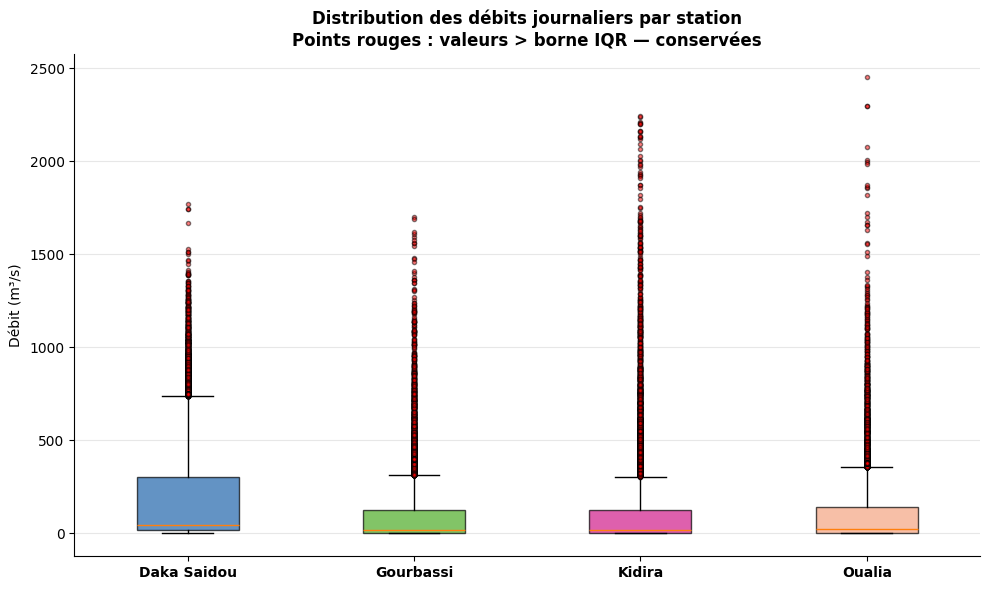

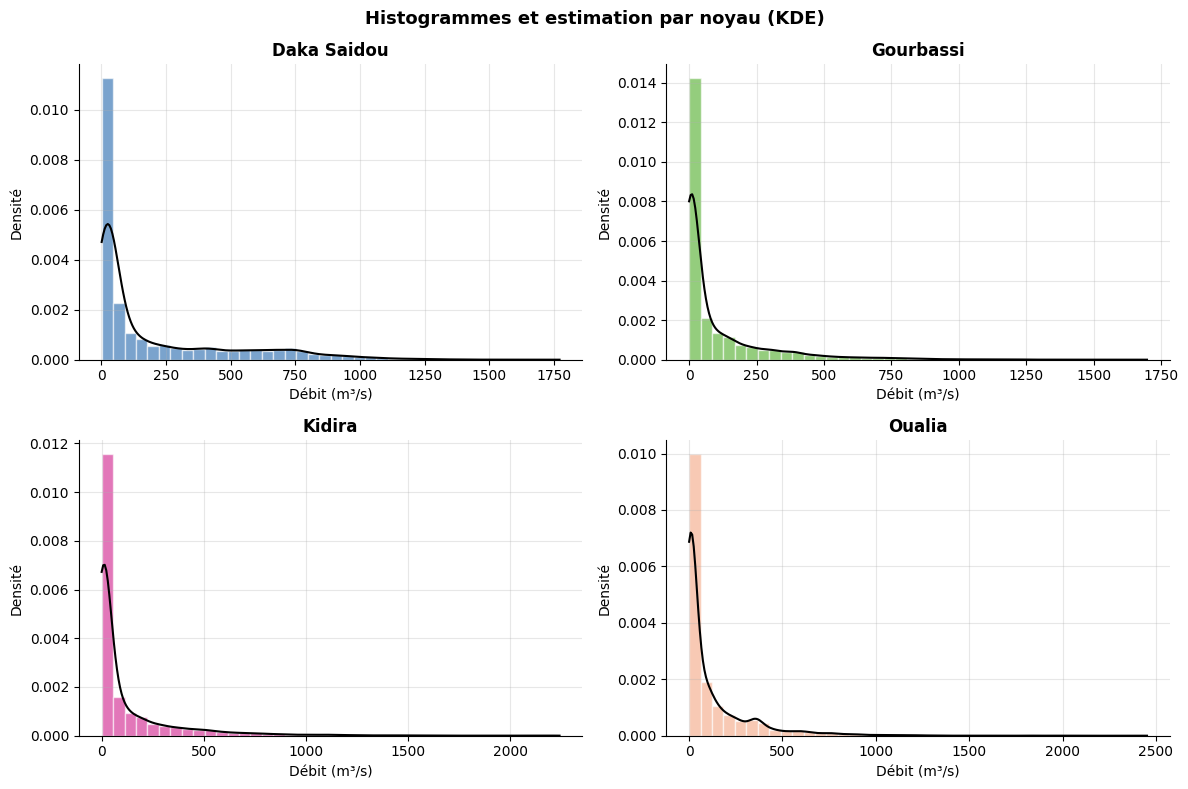

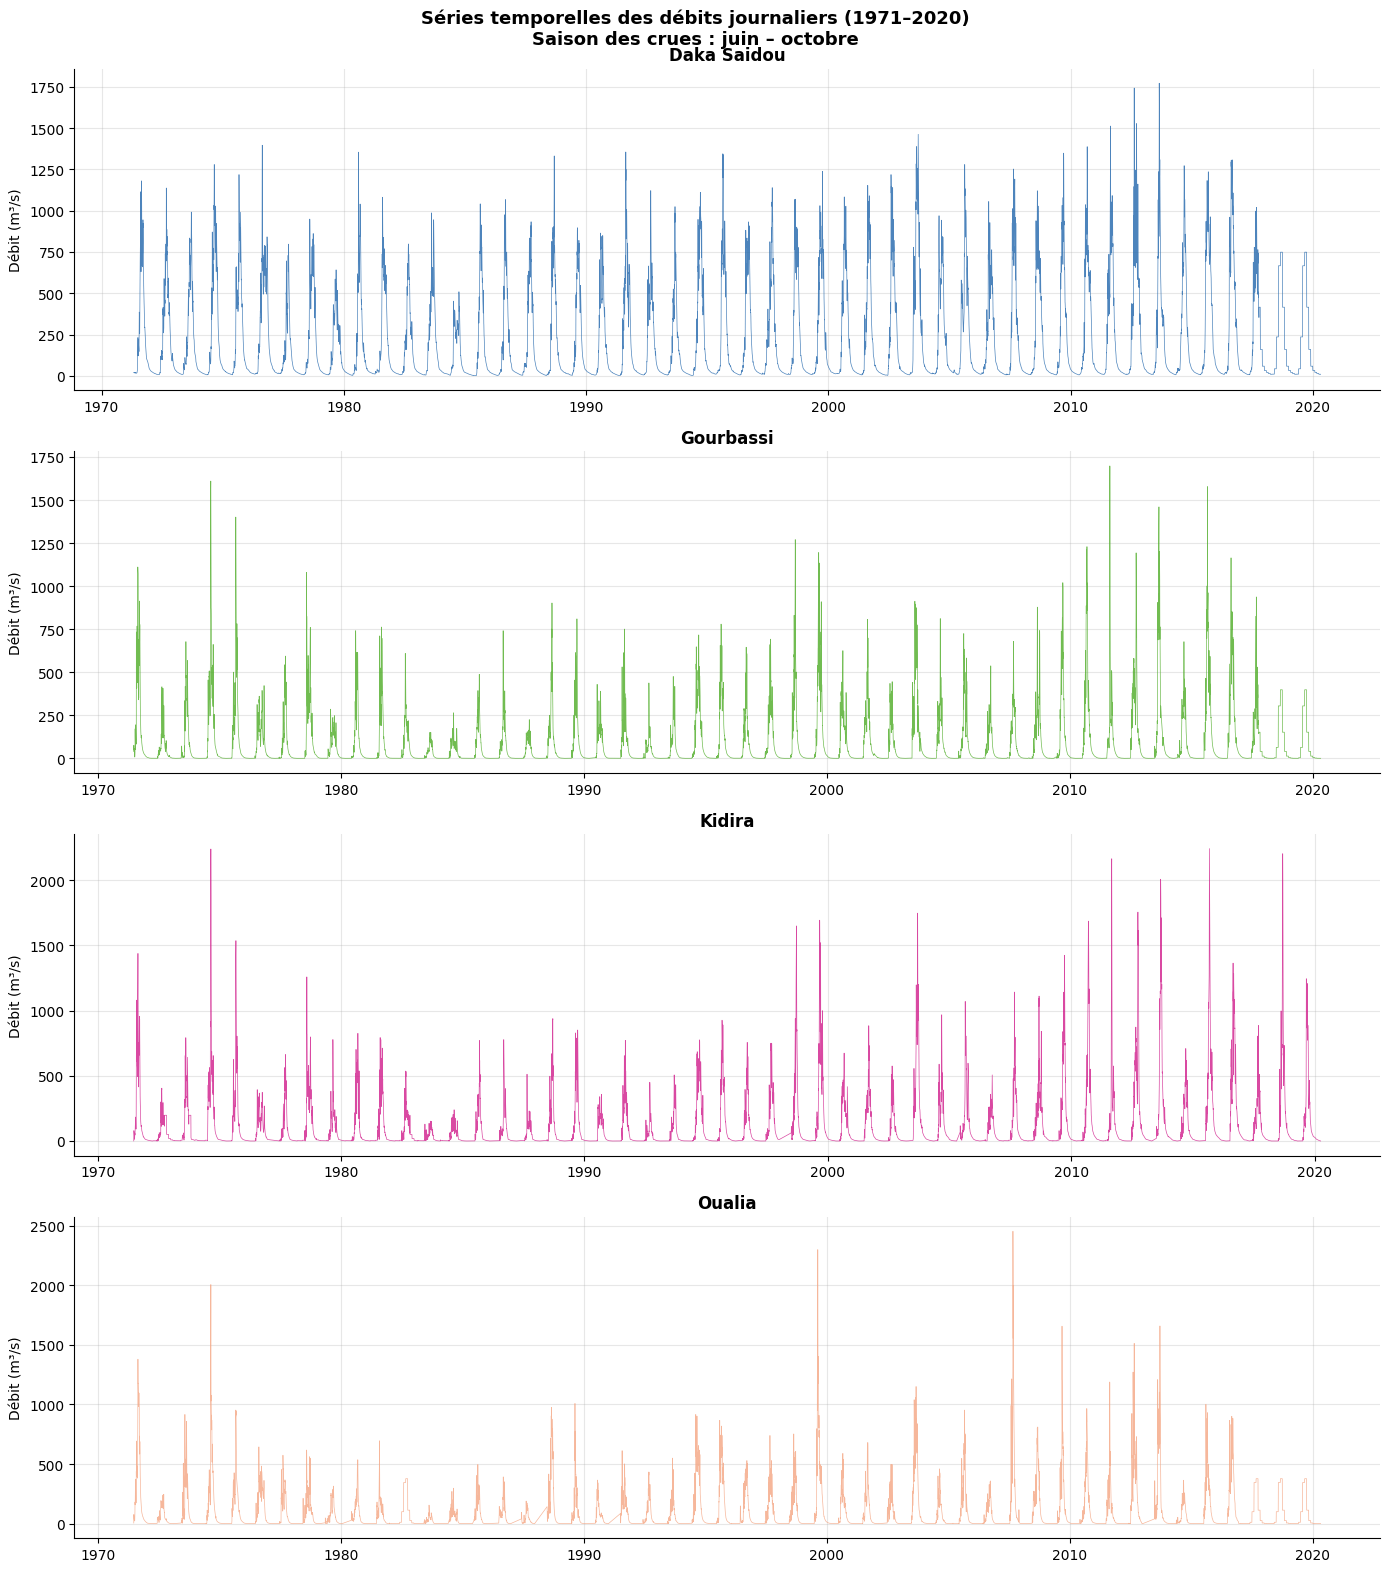

✔ Figures sauvegardées.


In [10]:
# ============================================================
# ÉTAPE 6 — VISUALISATIONS
# ============================================================

# Boxplot
fig, ax = plt.subplots(figsize=(10, 6))
data_box = [debits[col].dropna() for col in cols_debits]
data_box = [x[x > 0] for x in data_box]
bp = ax.boxplot(data_box, patch_artist=True,
                flierprops=dict(marker='o',
                                markerfacecolor='red',
                                markersize=3,
                                alpha=0.5))
for patch, nom in zip(bp['boxes'], noms_stations):
    patch.set_facecolor(couleurs[nom])
    patch.set_alpha(0.7)
ax.set_xticklabels(noms_stations, fontweight='bold')
ax.set_ylabel("Débit (m³/s)")
ax.set_title(
    "Distribution des débits journaliers par station\n"
    "Points rouges : valeurs > borne IQR — conservées",
    fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("boxplot_debits.png", dpi=300,
            bbox_inches='tight')
plt.show()

# Histogrammes + KDE
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, (col, nom) in enumerate(
        zip(cols_debits, noms_stations)):
    ax = axes[i]
    x  = debits[col].dropna()
    x  = x[x > 0]
    ax.hist(x, bins=40, density=True,
            color=couleurs[nom], alpha=0.6,
            edgecolor='white')
    kde_x = np.linspace(x.min(), x.max(), 300)
    kde   = stats.gaussian_kde(x)
    ax.plot(kde_x, kde(kde_x), color='black',
            linewidth=1.5)
    ax.set_title(nom, fontweight='bold')
    ax.set_xlabel("Débit (m³/s)")
    ax.set_ylabel("Densité")
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle(
    "Histogrammes et estimation par noyau (KDE)",
    fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig("histogrammes_kde.png", dpi=300,
            bbox_inches='tight')
plt.show()

# Séries temporelles
fig, axes = plt.subplots(4, 1, figsize=(14, 16))
for i, (col, nom) in enumerate(
        zip(cols_debits, noms_stations)):
    ax = axes[i]
    x  = debits[col].dropna()
    x  = x[x > 0]
    ax.plot(debits.loc[x.index, 'date'], x,
            color=couleurs[nom], linewidth=0.5,
            alpha=0.8)
    ax.set_title(nom, fontweight='bold', fontsize=12)
    ax.set_ylabel("Débit (m³/s)")
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle(
    "Séries temporelles des débits journaliers (1971–2020)\n"
    "Saison des crues : juin – octobre",
    fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig("series_temporelles.png", dpi=300,
            bbox_inches='tight')
plt.show()
print("✔ Figures sauvegardées.")


-- Daka Saidou -- Tau=0.1947 | p=0.0494 | Sen=5.7966 | Hausse significative
-- Gourbassi -- Tau=0.1879 | p=0.0579 | Sen=7.3052 | Pas de tendance significative
-- Kidira -- Tau=0.3044 | p=0.0021 | Sen=16.6793 | Hausse significative
-- Oualia -- Tau=0.1122 | p=0.2587 | Sen=5.0783 | Pas de tendance significative
       Station     Tau  P_value                       Tendance  Pente_Sen
0  Daka Saidou  0.1947   0.0494           Hausse significative     5.7966
1    Gourbassi  0.1879   0.0579  Pas de tendance significative     7.3052
2       Kidira  0.3044   0.0021           Hausse significative    16.6793
3       Oualia  0.1122   0.2587  Pas de tendance significative     5.0783


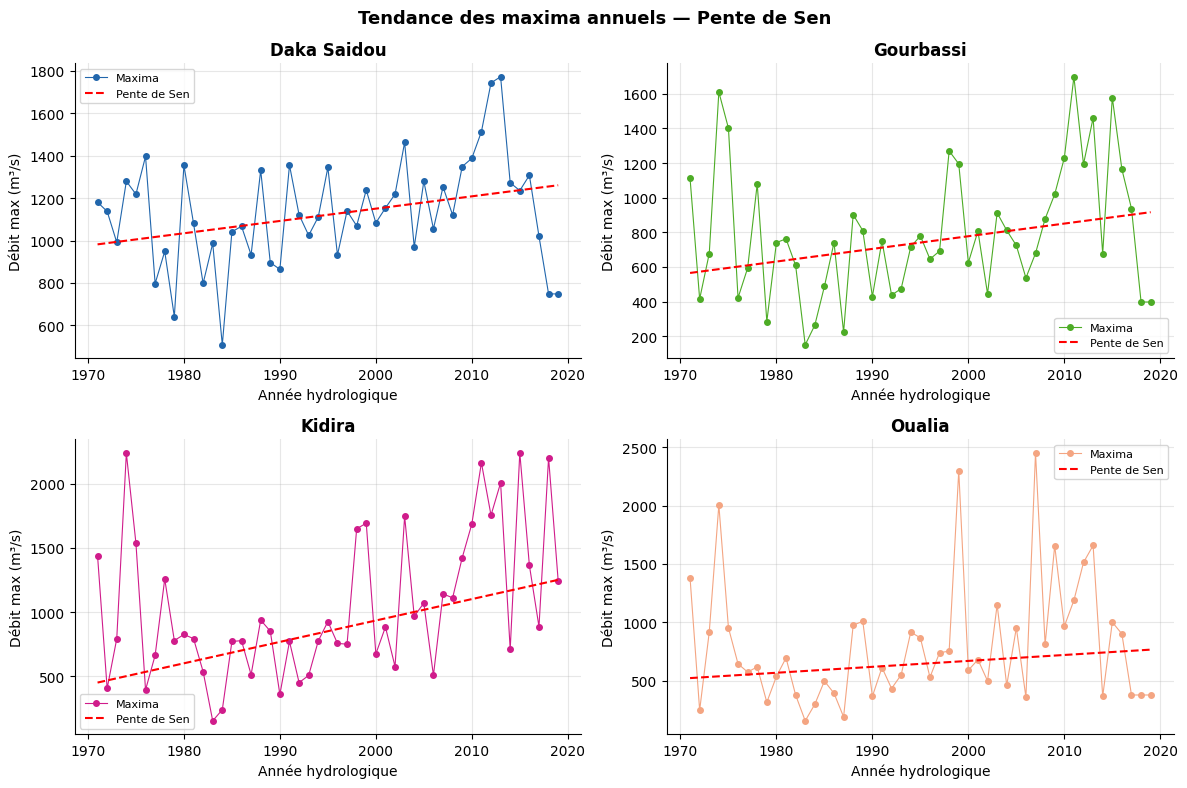

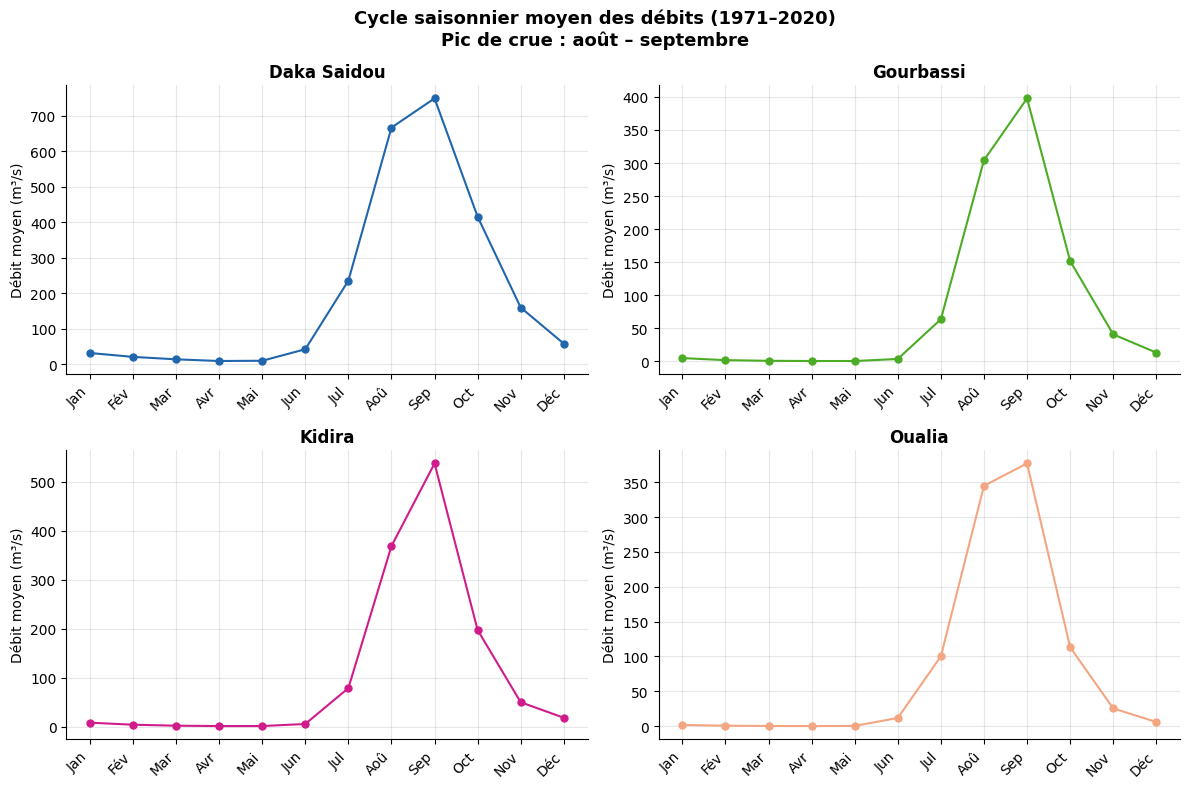

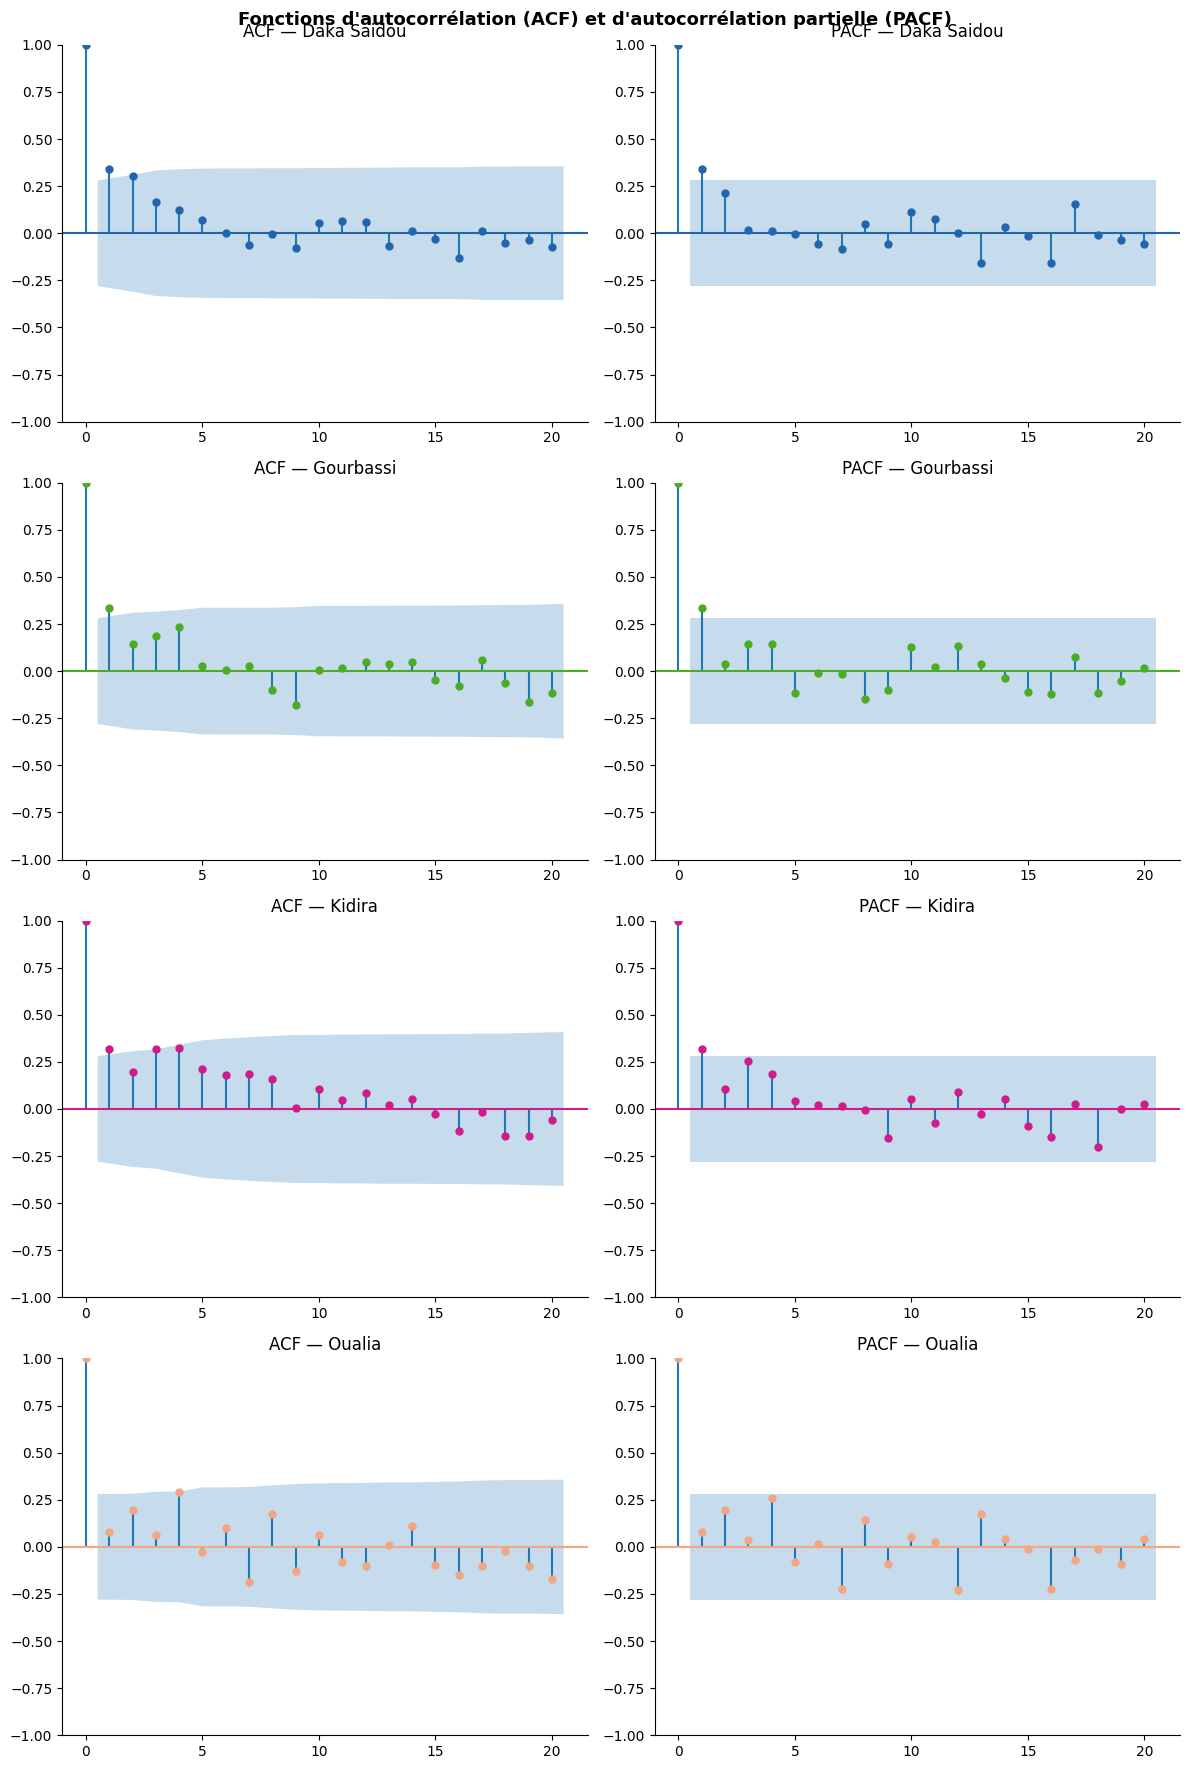

✔ Structures temporelles analysées.


In [11]:
# ============================================================
# ÉTAPE 7 — STRUCTURES TEMPORELLES
# ============================================================

# Mann-Kendall + Pente de Sen
resultats_mk = []
for col, nom in zip(cols_max, noms_stations):
    x   = AM[col].dropna().values
    res = mk_test(x)
    # Pente de Sen
    n   = len(x)
    pentes = [(x[j] - x[i])/(j - i)
              for i in range(n)
              for j in range(i+1, n)]
    sen = np.median(pentes)
    tendance = ("Hausse significative"
                if res.p < 0.05 and res.Tau > 0
                else "Baisse significative"
                if res.p < 0.05 and res.Tau < 0
                else "Pas de tendance significative")
    resultats_mk.append({
        'Station':   nom,
        'Tau':       round(res.Tau, 4),
        'P_value':   round(res.p, 4),
        'Tendance':  tendance,
        'Pente_Sen': round(sen, 4)
    })
    print(f"-- {nom} -- Tau={res.Tau:.4f} | "
          f"p={res.p:.4f} | Sen={sen:.4f} | {tendance}")

resultats_mk_df = pd.DataFrame(resultats_mk)
print(resultats_mk_df)
resultats_mk_df.to_csv(
    "mann_kendall_resultats.csv", index=False)

# Figure tendance + pente de Sen
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, (col, nom) in enumerate(
        zip(cols_max, noms_stations)):
    ax   = axes[i]
    x    = AM[col].dropna().values
    ans  = AM['annee_hydro'].values
    sen  = resultats_mk_df.loc[i, 'Pente_Sen']
    med  = np.median(x)
    idx  = np.arange(len(x))
    ord_ = med - sen * np.median(idx)
    droite = ord_ + sen * idx
    ax.plot(ans, x, color=couleurs[nom],
            marker='o', markersize=4,
            linewidth=0.8, label='Maxima')
    ax.plot(ans, droite, color='red',
            linestyle='--', linewidth=1.5,
            label='Pente de Sen')
    ax.set_title(nom, fontweight='bold')
    ax.set_xlabel("Année hydrologique")
    ax.set_ylabel("Débit max (m³/s)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle(
    "Tendance des maxima annuels — Pente de Sen",
    fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig("tendance_sen.png", dpi=300,
            bbox_inches='tight')
plt.show()

# Saisonnalité
saisonnalite = (debits.groupby('mois')[cols_debits]
                .mean()
                .reset_index())
saisonnalite.columns = (
    ['mois'] + noms_stations)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
mois_labels = ['Jan','Fév','Mar','Avr','Mai','Jun',
               'Jul','Aoû','Sep','Oct','Nov','Déc']
for i, nom in enumerate(noms_stations):
    ax = axes[i]
    ax.plot(saisonnalite['mois'],
            saisonnalite[nom],
            color=couleurs[nom],
            marker='o', markersize=5,
            linewidth=1.5)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(mois_labels,
                       rotation=45, ha='right')
    ax.set_title(nom, fontweight='bold')
    ax.set_ylabel("Débit moyen (m³/s)")
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle(
    "Cycle saisonnier moyen des débits (1971–2020)\n"
    "Pic de crue : août – septembre",
    fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig("saisonnalite.png", dpi=300,
            bbox_inches='tight')
plt.show()

# ACF et PACF
from statsmodels.graphics.tsaplots import (
    plot_acf, plot_pacf)

fig, axes = plt.subplots(4, 2, figsize=(12, 18))
for i, (col, nom) in enumerate(
        zip(cols_max, noms_stations)):
    x = AM[col].dropna().values
    plot_acf(x, lags=20, ax=axes[i, 0],
             color=couleurs[nom],
             title=f"ACF — {nom}")
    plot_pacf(x, lags=20, ax=axes[i, 1],
              color=couleurs[nom],
              title=f"PACF — {nom}",
              method='ywm')
    axes[i, 0].spines['top'].set_visible(False)
    axes[i, 0].spines['right'].set_visible(False)
    axes[i, 1].spines['top'].set_visible(False)
    axes[i, 1].spines['right'].set_visible(False)

plt.suptitle(
    "Fonctions d'autocorrélation (ACF) et "
    "d'autocorrélation partielle (PACF)",
    fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig("acf_pacf.png", dpi=300,
            bbox_inches='tight')
plt.show()
print("✔ Structures temporelles analysées.")


In [12]:
# ============================================================
# ÉTAPE 8 — TESTS DE STATIONNARITÉ
# ============================================================
resultats_stat = []
for col, nom in zip(cols_max, noms_stations):
    x = AM[col].dropna().values

    # Test ADF
    adf_res  = adfuller(x, autolag='AIC')
    adf_p    = round(adf_res[1], 4)
    adf_stat = round(adf_res[0], 4)

    # Test KPSS
    kpss_res  = kpss(x, regression='c', nlags='auto')
    kpss_p    = round(kpss_res[1], 4)
    kpss_stat = round(kpss_res[0], 4)

    adf_rejete  = adf_p  < 0.05
    kpss_rejete = kpss_p < 0.05

    if adf_rejete and not kpss_rejete:
        conclusion = "Stationnarite confirmee"
    elif not adf_rejete and kpss_rejete:
        conclusion = "Non-stationnarite confirmee"
    else:
        conclusion = "Resultats ambigus"

    resultats_stat.append({
        'Station':          nom,
        'ADF_stat':         adf_stat,
        'ADF_pvalue':       adf_p,
        'KPSS_stat':        kpss_stat,
        'KPSS_pvalue':      kpss_p,
        'Conclusion_finale': conclusion
    })
    print(f"-- {nom} -- ADF p={adf_p:.4f} | "
          f"KPSS p={kpss_p:.4f} | {conclusion}")

resultats_stat_df = pd.DataFrame(resultats_stat)
print(resultats_stat_df[['Station', 'ADF_pvalue',
                          'KPSS_pvalue',
                          'Conclusion_finale']])
resultats_stat_df.to_csv(
    "stationnarite_resultats.csv", index=False)
print("\n✔ Analyse exploratoire complète terminée.")

-- Daka Saidou -- ADF p=0.0785 | KPSS p=0.0990 | Resultats ambigus
-- Gourbassi -- ADF p=0.0001 | KPSS p=0.1000 | Stationnarite confirmee
-- Kidira -- ADF p=0.0144 | KPSS p=0.0188 | Resultats ambigus
-- Oualia -- ADF p=0.0068 | KPSS p=0.1000 | Stationnarite confirmee
       Station  ADF_pvalue  KPSS_pvalue        Conclusion_finale
0  Daka Saidou      0.0785       0.0990        Resultats ambigus
1    Gourbassi      0.0001       0.1000  Stationnarite confirmee
2       Kidira      0.0144       0.0188        Resultats ambigus
3       Oualia      0.0068       0.1000  Stationnarite confirmee

✔ Analyse exploratoire complète terminée.


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11020\2277422580.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res  = kpss(x, regression='c', nlags='auto')
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11020\2277422580.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res  = kpss(x, regression='c', nlags='auto')


-- Daka Saidou -- RMSE=284.28 | MAE=228.58 | MAPE=22.28%
-- Gourbassi -- RMSE=427.23 | MAE=342.47 | MAPE=59.67%
-- Kidira -- RMSE=648.64 | MAE=500.06 | MAPE=61.26%
-- Oualia -- RMSE=701.86 | MAE=493.56 | MAPE=77.81%
       Station     RMSE      MAE    MAPE
0  Daka Saidou  284.275  228.580  22.283
1    Gourbassi  427.228  342.473  59.667
2       Kidira  648.639  500.058  61.258
3       Oualia  701.856  493.558  77.809


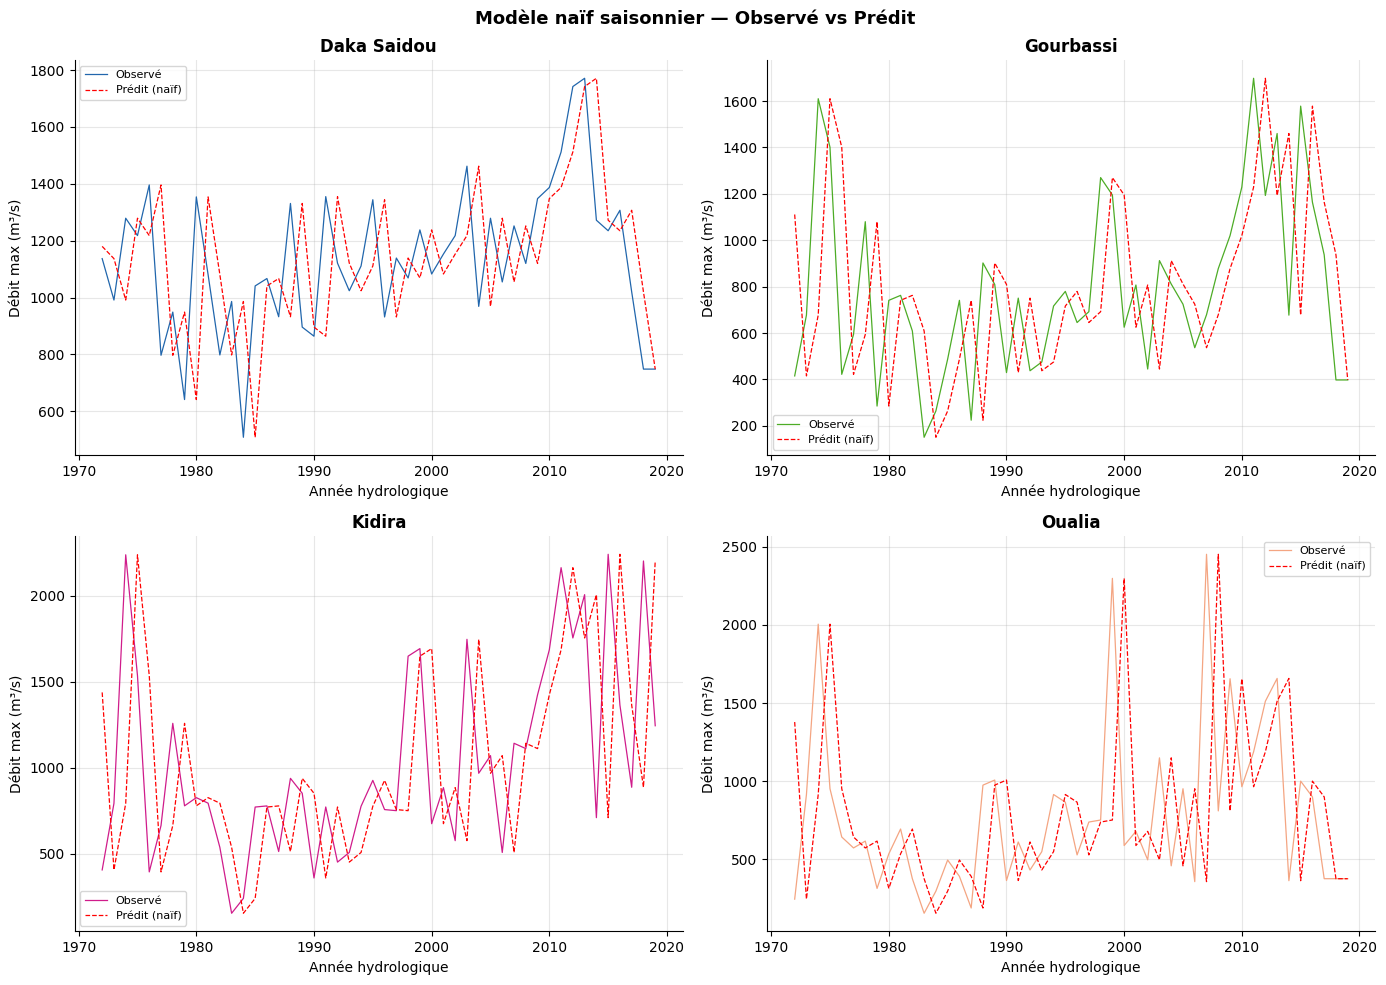

✔ Métriques modèle naïf sauvegardées.


In [13]:
# ============================================================
# ÉTAPE 9 — MODÈLE DE RÉFÉRENCE (NAÏF SAISONNIER)
# ============================================================
resultats_naif = []
predictions_naif = {}

for col, nom in zip(cols_max, noms_stations):
    x    = AM[col].values
    ans  = AM['annee_hydro'].values
    y_obs  = x[1:]
    y_pred = x[:-1]
    annees = ans[1:]
    rmse = np.sqrt(mean_squared_error(y_obs, y_pred))
    mae  = mean_absolute_error(y_obs, y_pred)
    mape = np.mean(
        np.abs((y_obs - y_pred) / y_obs)) * 100
    resultats_naif.append({
        'Station': nom,
        'RMSE':    round(rmse, 3),
        'MAE':     round(mae, 3),
        'MAPE':    round(mape, 3)
    })
    predictions_naif[nom] = pd.DataFrame({
        'annee':  annees,
        'obs':    y_obs,
        'pred':   y_pred,
        'erreur': y_obs - y_pred
    })
    print(f"-- {nom} -- RMSE={rmse:.2f} | "
          f"MAE={mae:.2f} | MAPE={mape:.2f}%")

resultats_naif_df = pd.DataFrame(resultats_naif)
print(resultats_naif_df)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, nom in enumerate(noms_stations):
    ax  = axes[i]
    df  = predictions_naif[nom]
    ax.plot(df['annee'], df['obs'],
            color=couleurs[nom], linewidth=0.9,
            label='Observé')
    ax.plot(df['annee'], df['pred'],
            color='red', linewidth=0.9,
            linestyle='--', label='Prédit (naïf)')
    ax.set_title(nom, fontweight='bold')
    ax.set_xlabel("Année hydrologique")
    ax.set_ylabel("Débit max (m³/s)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle(
    "Modèle naïf saisonnier — Observé vs Prédit",
    fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig("modele_naif.png", dpi=300,
            bbox_inches='tight')
plt.show()

resultats_naif_df.to_csv(
    "modele_naif_metriques.csv", index=False)
print("✔ Métriques modèle naïf sauvegardées.")



=== Ajustement GEV — Daka Saidou ===
   mu    = 1014.213
   sigma = 203.670
   xi    = -0.001
   Log-lik = -346.658 | AIC = 699.316 | BIC = 704.992

   Niveaux de retour :
   T =    2 ans : 1088.8 m³/s
   T =    5 ans : 1319.5 m³/s
   T =   10 ans : 1472.1 m³/s
   T =   20 ans : 1618.4 m³/s
   T =   50 ans : 1807.7 m³/s
   T =  100 ans : 1949.4 m³/s
   T =  200 ans : 2090.6 m³/s

=== Ajustement GEV — Gourbassi ===
   mu    = 622.171
   sigma = 316.955
   xi    = 0.040
   Log-lik = -357.606 | AIC = 721.212 | BIC = 726.887

   Niveaux de retour :
   T =    2 ans : 739.2 m³/s
   T =    5 ans : 1112.3 m³/s
   T =   10 ans : 1368.9 m³/s
   T =   20 ans : 1622.5 m³/s
   T =   50 ans : 1962.0 m³/s
   T =  100 ans : 2224.8 m³/s
   T =  200 ans : 2494.2 m³/s

=== Ajustement GEV — Oualia ===
   mu    = 538.416
   sigma = 313.711
   xi    = -0.207
   Log-lik = -inf | AIC = inf | BIC = inf

   Niveaux de retour :
   T =    2 ans : 649.2 m³/s
   T =    5 ans : 943.1 m³/s
   T =   10 ans : 1103.0 m

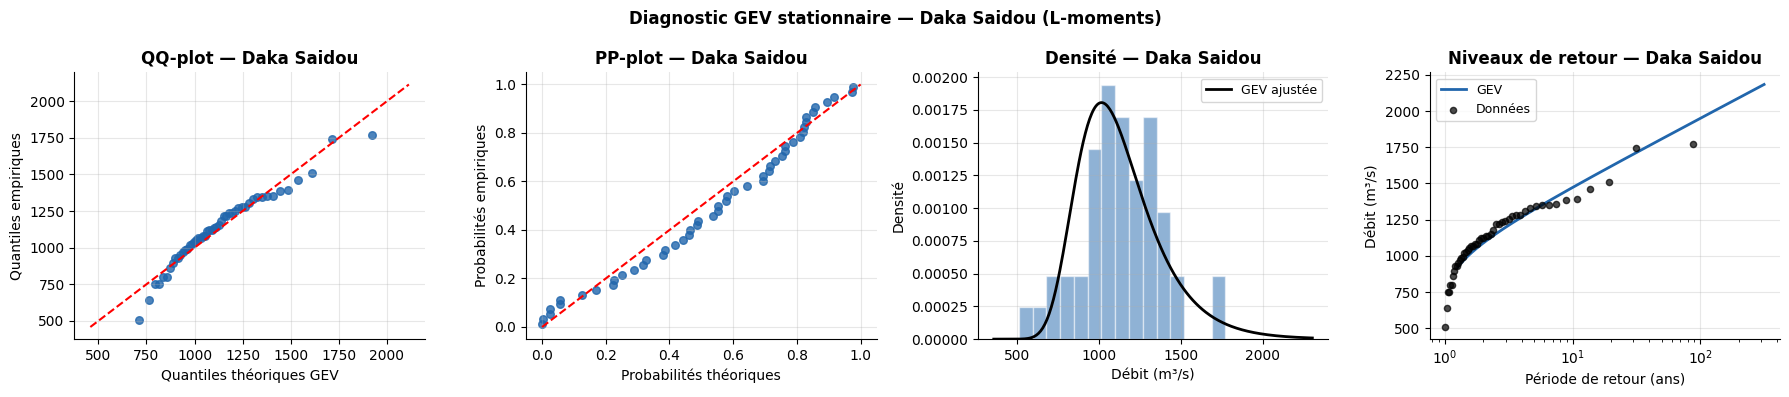

✔ Figures diagnostic sauvegardées pour Daka Saidou


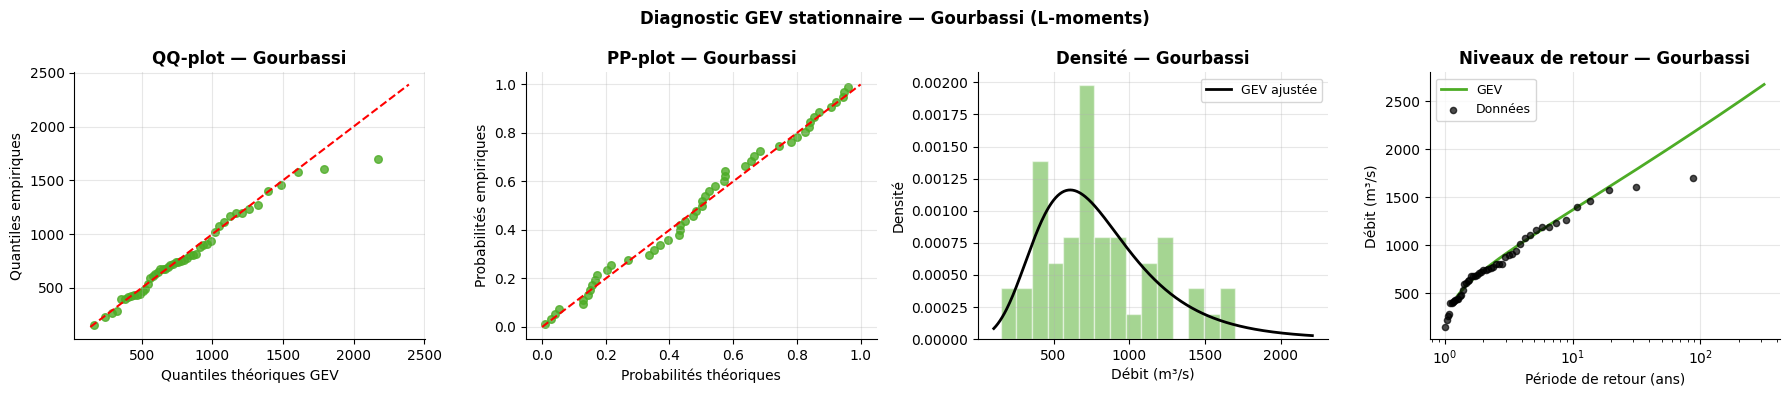

✔ Figures diagnostic sauvegardées pour Gourbassi


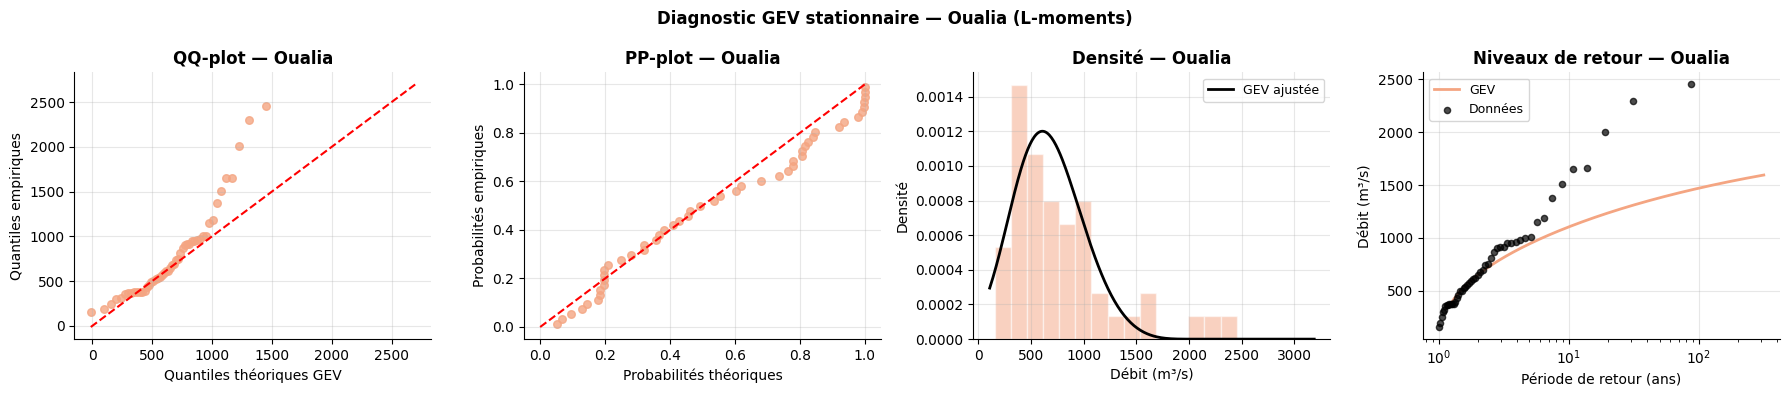

✔ Figures diagnostic sauvegardées pour Oualia


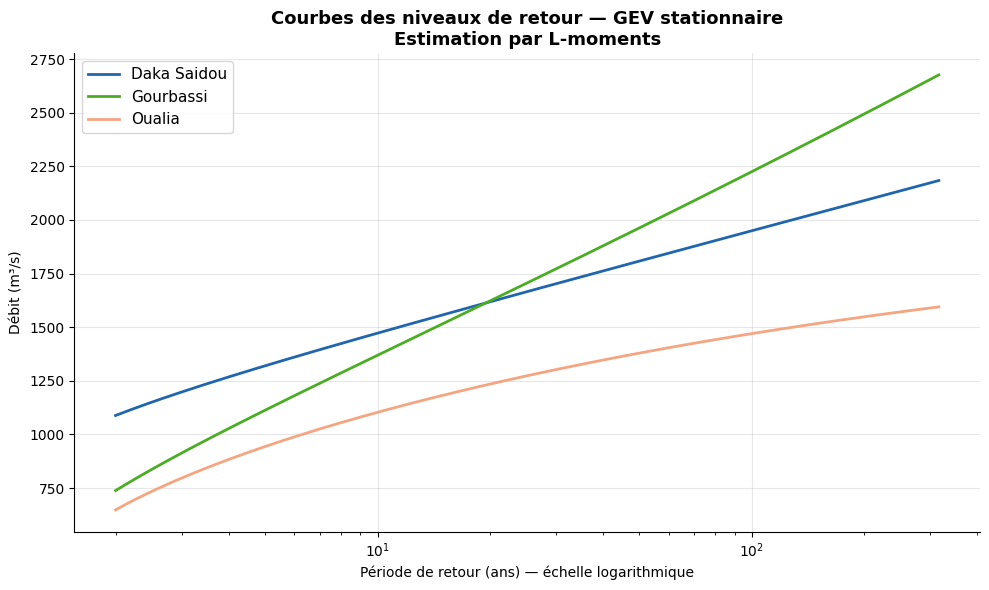


✔ Paramètres GEV sauvegardés.
✔ Niveaux de retour sauvegardés.


In [14]:
# ============================================================
# ANNEXE A — MODÉLISATION GEV STATIONNAIRE 
# Méthode : L-moments (plus robuste que MLE sur petits échantillons)
# ============================================================
# ── Fonction L-moments maison ────────────────────────────────
def lmom_gev(x):
    """
    Estimation des paramètres GEV par L-moments
    selon Hosking (1990)
    """
    x    = np.sort(x)
    n    = len(x)
    i    = np.arange(1, n + 1)

    # L-moments empiriques
    b0 = np.mean(x)
    b1 = np.sum((i - 1) / (n * (n - 1)) * x)
    b2 = np.sum((i - 1) * (i - 2) /
                (n * (n - 1) * (n - 2)) * x)

    l1 = b0
    l2 = 2 * b1 - b0
    l3 = 6 * b2 - 6 * b1 + b0

    # Ratio de L-moments
    t3 = l3 / l2

    # Estimation de xi (paramètre de forme)
    # Approximation de Hosking (1990)
    if t3 >= 0:
        z  = 2 / (t3 + 3) - np.log(2) / np.log(3)
        xi = (7.859 * z + 2.9554 * z**2) / \
             (1 + 2.1538 * z)
    else:
        z  = t3
        xi = (0.27859 * z + 0.39020 * z**2 +
              0.03030 * z**3) / \
             (1 - 0.28376 * z + 0.10910 * z**2)

    # Estimation de sigma et mu
    #g1    = np.math.gamma(1 + xi) if xi != 0 else 1.0
    from scipy.special import gamma
    g1    = gamma(1 + xi)
    sigma = l2 * xi / ((1 - 2**(-xi)) * g1)
    mu    = l1 - sigma * (1 - g1) / xi

    return mu, sigma, xi

# ── Définition des stations ──────────────────────────────────
stations_stat = {
    'Daka Saidou': AM['daka_saidou_max'].dropna().values,
    'Gourbassi':   AM['gourbassi_max'].dropna().values,
    'Oualia':      AM['oualia_max'].dropna().values
}

couleurs_stat = {
    'Daka Saidou': '#2166ac',
    'Gourbassi':   '#4dac26',
    'Oualia':      '#f4a582'
}

periodes = [2, 5, 10, 20, 50, 100, 200]

resultats_gev = []
modeles_gev   = {}
resultats_nr  = []

for nom, x in stations_stat.items():
    n = len(x)
    print(f"\n=== Ajustement GEV — {nom} ===")

    # Estimation par L-moments
    mu, sigma, xi = lmom_gev(x)

    # Log-vraisemblance (scipy convention : shape = -xi)
    loglik = np.sum(
        genextreme.logpdf(x, -xi, loc=mu, scale=sigma))
    k   = 3
    aic = -2 * loglik + 2 * k
    bic = -2 * loglik + np.log(n) * k

    # Stockage format scipy (shape = -xi)
    modeles_gev[nom] = (-xi, mu, sigma)

    print(f"   mu    = {mu:.3f}")
    print(f"   sigma = {sigma:.3f}")
    print(f"   xi    = {xi:.3f}")
    print(f"   Log-lik = {loglik:.3f} | "
          f"AIC = {aic:.3f} | BIC = {bic:.3f}")

    if abs(xi) > 0.5:
        print(f"   ⚠ xi hors de [-0.5, 0.5] "
              f"— interpréter avec prudence")

    resultats_gev.append({
        'Station': nom,
        'mu':      round(mu, 3),
        'sigma':   round(sigma, 3),
        'xi':      round(xi, 3),
        'loglik':  round(loglik, 3),
        'AIC':     round(aic, 3),
        'BIC':     round(bic, 3)
    })

    # Niveaux de retour
    print(f"\n   Niveaux de retour :")
    for T in periodes:
        p  = 1 - 1/T
        nr = genextreme.ppf(p, -xi, loc=mu, scale=sigma)
        resultats_nr.append({
            'Station': nom,
            'Periode': T,
            'NR':      round(nr, 1)
        })
        print(f"   T = {T:4d} ans : {nr:.1f} m³/s")

# ── Tableaux résultats ───────────────────────────────────────
resultats_gev_df = pd.DataFrame(resultats_gev)
resultats_nr_df  = pd.DataFrame(resultats_nr)

print("\n=== Paramètres GEV estimés (L-moments) ===")
print(resultats_gev_df)

nr_synthetique = (resultats_nr_df
                  [resultats_nr_df['Periode']
                   .isin([10, 50, 100, 200])]
                  .copy())
print("\n=== Tableau synthétique niveaux de retour ===")
print(nr_synthetique)

# ── Graphiques de diagnostic ─────────────────────────────────
for nom, x in stations_stat.items():
    xi_s, mu, sigma = modeles_gev[nom]
    xi    = -xi_s
    nom_f = nom.lower().replace(' ', '_')
    n     = len(x)
    x_sort = np.sort(x)
    p_emp  = (np.arange(1, n+1) - 0.44) / (n + 0.12)

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))

    # QQ-plot
    q_theo = genextreme.ppf(p_emp, xi_s, loc=mu, scale=sigma)
    axes[0].scatter(q_theo, x_sort,
                    color=couleurs_stat[nom], s=30, alpha=0.8)
    lim = [min(q_theo.min(), x_sort.min()) * 0.9,
           max(q_theo.max(), x_sort.max()) * 1.1]
    axes[0].plot(lim, lim, 'r--', linewidth=1.5)
    axes[0].set_title(f"QQ-plot — {nom}",
                      fontweight='bold')
    axes[0].set_xlabel("Quantiles théoriques GEV")
    axes[0].set_ylabel("Quantiles empiriques")
    axes[0].grid(True, alpha=0.3)
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)

    # PP-plot
    p_theo = genextreme.cdf(x_sort, xi_s, loc=mu, scale=sigma)
    axes[1].scatter(p_theo, p_emp,
                    color=couleurs_stat[nom], s=30, alpha=0.8)
    axes[1].plot([0, 1], [0, 1], 'r--', linewidth=1.5)
    axes[1].set_title(f"PP-plot — {nom}",
                      fontweight='bold')
    axes[1].set_xlabel("Probabilités théoriques")
    axes[1].set_ylabel("Probabilités empiriques")
    axes[1].grid(True, alpha=0.3)
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)

    # Densité
    x_range = np.linspace(x.min()*0.7, x.max()*1.3, 300)
    axes[2].hist(x, bins=15, density=True,
                 color=couleurs_stat[nom],
                 alpha=0.5, edgecolor='white')
    axes[2].plot(x_range,
                 genextreme.pdf(x_range, xi_s,
                                loc=mu, scale=sigma),
                 color='black', linewidth=2,
                 label='GEV ajustée')
    axes[2].set_title(f"Densité — {nom}",
                      fontweight='bold')
    axes[2].set_xlabel("Débit (m³/s)")
    axes[2].set_ylabel("Densité")
    axes[2].legend(fontsize=9)
    axes[2].grid(True, alpha=0.3)
    axes[2].spines['top'].set_visible(False)
    axes[2].spines['right'].set_visible(False)

    # Niveaux de retour
    T_range  = np.logspace(0.1, 2.5, 300)
    p_range  = 1 - 1/T_range
    nr_range = genextreme.ppf(p_range, xi_s,
                               loc=mu, scale=sigma)
    T_emp    = 1 / (1 - p_emp)
    axes[3].plot(T_range, nr_range,
                 color=couleurs_stat[nom],
                 linewidth=2, label='GEV')
    axes[3].scatter(T_emp, x_sort,
                    color='black', s=20,
                    alpha=0.7, zorder=5,
                    label='Données')
    axes[3].set_xscale('log')
    axes[3].set_title(f"Niveaux de retour — {nom}",
                      fontweight='bold')
    axes[3].set_xlabel("Période de retour (ans)")
    axes[3].set_ylabel("Débit (m³/s)")
    axes[3].legend(fontsize=9)
    axes[3].grid(True, alpha=0.3)
    axes[3].spines['top'].set_visible(False)
    axes[3].spines['right'].set_visible(False)

    plt.suptitle(
        f"Diagnostic GEV stationnaire — {nom} "
        f"(L-moments)",
        fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.savefig(f"diagnostic_gev_{nom_f}.png",
                dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✔ Figures diagnostic sauvegardées pour {nom}")

# ── Figure niveaux de retour comparatifs ─────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
T_range = np.logspace(0.3, 2.5, 300)
p_range = 1 - 1/T_range

for nom, (xi_s, mu, sigma) in modeles_gev.items():
    nr_range = genextreme.ppf(p_range, xi_s,
                               loc=mu, scale=sigma)
    ax.plot(T_range, nr_range,
            color=couleurs_stat[nom],
            linewidth=2, label=nom)

ax.set_xscale('log')
ax.set_xlabel(
    "Période de retour (ans) — échelle logarithmique")
ax.set_ylabel("Débit (m³/s)")
ax.set_title(
    "Courbes des niveaux de retour — GEV stationnaire\n"
    "Estimation par L-moments",
    fontweight='bold', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("niveaux_retour_gev_stationnaire.png",
            dpi=300, bbox_inches='tight')
plt.show()

# ── Sauvegarde ───────────────────────────────────────────────
resultats_gev_df.to_csv(
    "annexe_gev_parametres_stat.csv", index=False)
nr_synthetique.to_csv(
    "annexe_gev_niveaux_retour_stat.csv", index=False)

print("\n✔ Paramètres GEV sauvegardés.")
print("✔ Niveaux de retour sauvegardés.")

In [1]:
# ── Correction loglik pour Oualia ────────────────────────────
# Le problème vient de valeurs hors du support de la GEV
# On corrige en vérifiant le support avant le calcul

def loglik_gev(x, xi_s, mu, sigma):
    """
    Calcul robuste de la log-vraisemblance GEV
    xi_s = shape scipy = -xi standard
    """
    xi = -xi_s  # conversion vers convention standard
    
    if xi != 0:
        # Support de la GEV : x > mu - sigma/xi si xi > 0
        #                     x < mu - sigma/xi si xi < 0
        borne = mu - sigma / xi
        if xi > 0:
            valides = x > borne
        else:
            valides = x < borne
        if not np.all(valides):
            # Certaines valeurs hors support
            pct = (~valides).sum() / len(x) * 100
            print(f"   ⚠ {(~valides).sum()} valeurs "
                  f"({pct:.1f}%) hors support GEV")
    
    # Log-vraisemblance avec gestion des -inf
    logpdf = genextreme.logpdf(x, xi_s, loc=mu, scale=sigma)
    logpdf = logpdf[np.isfinite(logpdf)]
    return np.sum(logpdf)

# ── Recalcul pour toutes les stations ────────────────────────
for i, (nom, x) in enumerate(stations_stat.items()):
    xi_s, mu, sigma = modeles_gev[nom]
    n      = len(x)
    k      = 3
    loglik = loglik_gev(x, xi_s, mu, sigma)
    aic    = -2 * loglik + 2 * k
    bic    = -2 * loglik + np.log(n) * k

    resultats_gev[i]['loglik'] = round(loglik, 3)
    resultats_gev[i]['AIC']    = round(aic, 3)
    resultats_gev[i]['BIC']    = round(bic, 3)

    print(f"-- {nom} -- "
          f"Log-lik={loglik:.3f} | "
          f"AIC={aic:.3f} | BIC={bic:.3f}")

resultats_gev_df = pd.DataFrame(resultats_gev)
print("\n=== Paramètres GEV corrigés ===")
print(resultats_gev_df)
resultats_gev_df.to_csv(
    "annexe_gev_parametres_stat.csv", index=False)

NameError: name 'stations_stat' is not defined

=== Données Kidira ===
N = 49 années | De 1971 à 2019
Min = 152.5 | Max = 2242.0 m³/s

=== Modèle GEV stationnaire — Kidira ===
   mu    = 770.778
   sigma = 434.164
   xi    = -0.039
   Log-lik = -375.309 | AIC = 756.619 | BIC = 762.294

=== Modèle GEV non stationnaire — Kidira ===
    mu(t) = mu0 + mu1 * t
   mu0   = 794.551
   mu1   = 15.267 m³/s/an
   sigma = 370.895
   xi    = 0.076
   Log-lik = -369.553 | AIC = 747.107 | BIC = 754.674

=== Test du rapport de vraisemblance ===
   Statistique LRT = 11.5116
   p-value         = 0.0007
   Conclusion : Modèle NS significativement meilleur

=== Comparaison Stationnaire vs Non Stationnaire ===
             Modèle  Paramètres  Log-lik      AIC      BIC
0      Stationnaire           3 -375.309  756.619  762.294
1  Non stationnaire           4 -369.553  747.107  754.674

   ✔ Modèle retenu : Non stationnaire (AIC le plus faible)

=== Niveaux de retour non stationnaires ===

   Année de référence : 1971 (mu = 428.1 m³/s)
   T =    2 ans : 5

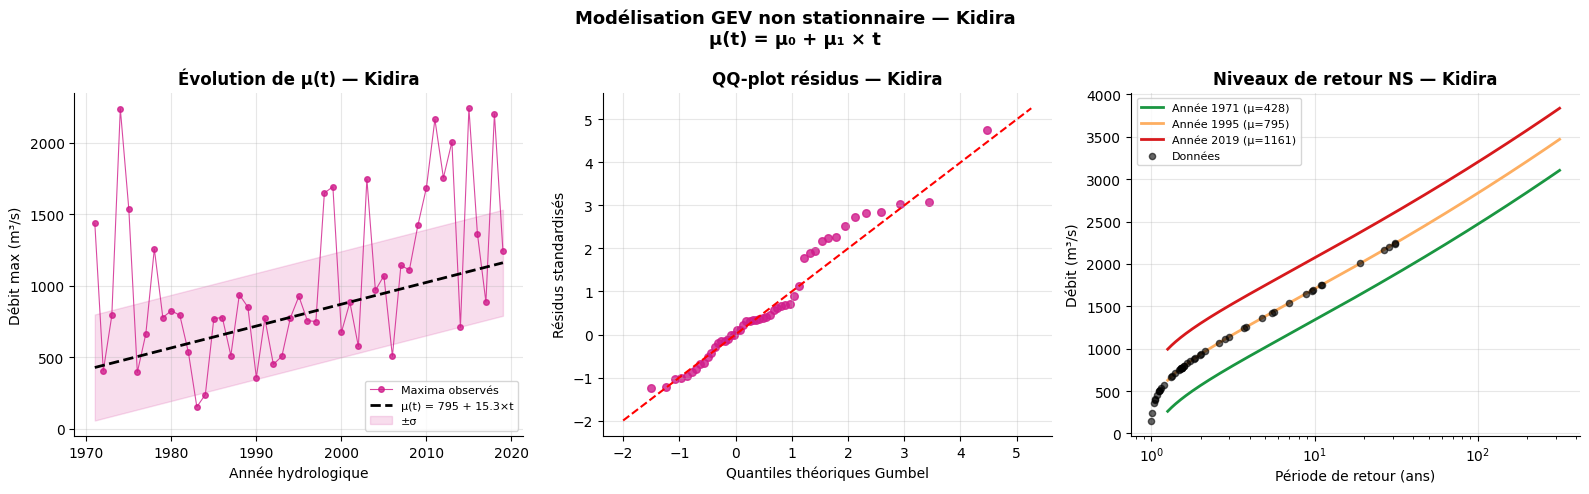

✔ Figure GEV NS sauvegardée.
✔ Paramètres GEV NS sauvegardés.
✔ Niveaux de retour NS sauvegardés.
✔ Prêt pour la modélisation GPD.


In [15]:
# ============================================================
# ANNEXE B — MODÉLISATION GEV NON STATIONNAIRE
# Station : Kidira
# Méthode : Maximum de Vraisemblance (MLE)
# Modèle  : mu(t) = mu0 + mu1 * t
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import genextreme
from scipy.optimize import minimize
from scipy.special import gamma

# ── B.1 Données Kidira ───────────────────────────────────────
x_kidira = AM['kidira_max'].dropna().values
t_kidira = AM['annee_hydro'].dropna().values
n        = len(x_kidira)

# Centrage du temps pour stabilité numérique
t_centre = t_kidira - t_kidira.mean()

print("=== Données Kidira ===")
print(f"N = {n} années | "
      f"De {t_kidira.min()} à {t_kidira.max()}")
print(f"Min = {x_kidira.min():.1f} | "
      f"Max = {x_kidira.max():.1f} m³/s")

# ── B.2 Modèle GEV stationnaire (référence) ─────────────────
print("\n=== Modèle GEV stationnaire — Kidira ===")

mu_s, sigma_s, xi_s = lmom_gev(x_kidira)
xi_scipy_s = -xi_s  # convention scipy

loglik_s = np.sum(
    genextreme.logpdf(x_kidira, xi_scipy_s,
                      loc=mu_s, scale=sigma_s))
k_s  = 3
aic_s = -2 * loglik_s + 2 * k_s
bic_s = -2 * loglik_s + np.log(n) * k_s

print(f"   mu    = {mu_s:.3f}")
print(f"   sigma = {sigma_s:.3f}")
print(f"   xi    = {xi_s:.3f}")
print(f"   Log-lik = {loglik_s:.3f} | "
      f"AIC = {aic_s:.3f} | BIC = {bic_s:.3f}")

# ── B.3 Modèle GEV non stationnaire ─────────────────────────
# mu(t) = mu0 + mu1 * t
# sigma et xi constants
print("\n=== Modèle GEV non stationnaire — Kidira ===")
print("    mu(t) = mu0 + mu1 * t")

def neg_loglik_ns(params, x, t):
    """
    Log-vraisemblance négative du modèle GEV non stationnaire
    params = [mu0, mu1, log_sigma, xi]
    log_sigma pour garantir sigma > 0
    """
    mu0, mu1, log_sigma, xi = params
    sigma = np.exp(log_sigma)
    mu_t  = mu0 + mu1 * t    # mu varie dans le temps

    # Convention scipy : shape = -xi
    logpdf = genextreme.logpdf(
        x, -xi, loc=mu_t, scale=sigma)

    # Pénalisation des valeurs infinies
    if not np.all(np.isfinite(logpdf)):
        return 1e10

    return -np.sum(logpdf)

# Valeurs initiales basées sur le modèle stationnaire
params0 = [mu_s, 0.0, np.log(sigma_s), xi_s]

# Optimisation
res_ns = minimize(
    neg_loglik_ns,
    params0,
    args=(x_kidira, t_centre),
    method='Nelder-Mead',
    options={'maxiter': 10000, 'xatol': 1e-6,
             'fatol': 1e-6}
)

mu0, mu1, log_sigma, xi_ns = res_ns.x
sigma_ns = np.exp(log_sigma)
loglik_ns = -res_ns.fun
k_ns      = 4
aic_ns    = -2 * loglik_ns + 2 * k_ns
bic_ns    = -2 * loglik_ns + np.log(n) * k_ns

print(f"   mu0   = {mu0:.3f}")
print(f"   mu1   = {mu1:.3f} m³/s/an")
print(f"   sigma = {sigma_ns:.3f}")
print(f"   xi    = {xi_ns:.3f}")
print(f"   Log-lik = {loglik_ns:.3f} | "
      f"AIC = {aic_ns:.3f} | BIC = {bic_ns:.3f}")

# ── B.4 Test du rapport de vraisemblance ─────────────────────
print("\n=== Test du rapport de vraisemblance ===")
lrt_stat = 2 * (loglik_ns - loglik_s)
from scipy.stats import chi2
p_lrt = 1 - chi2.cdf(lrt_stat, df=1)

print(f"   Statistique LRT = {lrt_stat:.4f}")
print(f"   p-value         = {p_lrt:.4f}")
print(f"   Conclusion : "
      f"{'Modèle NS significativement meilleur'if p_lrt < 0.05 else 'Pas de gain significatif'}")

# ── B.5 Comparaison AIC/BIC ──────────────────────────────────
print("\n=== Comparaison Stationnaire vs Non Stationnaire ===")
comparaison = pd.DataFrame({
    'Modèle':   ['Stationnaire', 'Non stationnaire'],
    'Paramètres': [k_s, k_ns],
    'Log-lik':  [round(loglik_s, 3), round(loglik_ns, 3)],
    'AIC':      [round(aic_s, 3), round(aic_ns, 3)],
    'BIC':      [round(bic_s, 3), round(bic_ns, 3)]
})
print(comparaison)

meilleur = ('Non stationnaire'
            if aic_ns < aic_s else 'Stationnaire')
print(f"\n   ✔ Modèle retenu : {meilleur} (AIC le plus faible)")

# ── B.6 Niveaux de retour non stationnaires ──────────────────
# Calculés pour l'année de référence (dernière année)
# et pour des années futures
print("\n=== Niveaux de retour non stationnaires ===")

periodes   = [2, 5, 10, 20, 50, 100, 200]
annees_ref = [1971, 1995, 2019]  # début, milieu, fin

resultats_nr_ns = []

for annee in annees_ref:
    t_ref = annee - t_kidira.mean()
    mu_ref = mu0 + mu1 * t_ref

    print(f"\n   Année de référence : {annee} "
          f"(mu = {mu_ref:.1f} m³/s)")
    for T in periodes:
        p  = 1 - 1/T
        nr = genextreme.ppf(
            p, -xi_ns, loc=mu_ref, scale=sigma_ns)
        resultats_nr_ns.append({
            'Annee':   annee,
            'Periode': T,
            'NR':      round(nr, 1),
            'mu_ref':  round(mu_ref, 1)
        })
        print(f"   T = {T:4d} ans : {nr:.1f} m³/s")

resultats_nr_ns_df = pd.DataFrame(resultats_nr_ns)

# ── B.7 Tableau synthétique ──────────────────────────────────
nr_ns_synthetique = (resultats_nr_ns_df
                     [resultats_nr_ns_df['Periode']
                      .isin([10, 50, 100, 200])])
print("\n=== Tableau synthétique ===")
print(nr_ns_synthetique)

# ── B.8 Figure — évolution de mu(t) ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Graphique 1 — évolution de mu(t)
mu_t_all = mu0 + mu1 * t_centre
axes[0].plot(t_kidira, x_kidira,
             color='#d01c8b', marker='o',
             markersize=4, linewidth=0.8,
             label='Maxima observés', alpha=0.8)
axes[0].plot(t_kidira, mu_t_all,
             color='black', linewidth=2,
             linestyle='--',
             label=f'μ(t) = {mu0:.0f} + '
                   f'{mu1:.1f}×t')
axes[0].fill_between(
    t_kidira,
    mu_t_all - sigma_ns,
    mu_t_all + sigma_ns,
    alpha=0.15, color='#d01c8b',
    label='±σ')
axes[0].set_title("Évolution de μ(t) — Kidira",
                  fontweight='bold')
axes[0].set_xlabel("Année hydrologique")
axes[0].set_ylabel("Débit max (m³/s)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Graphique 2 — QQ-plot résidus standardisés
mu_t_all = mu0 + mu1 * t_centre
z_scores  = (x_kidira - mu_t_all) / sigma_ns
z_sort    = np.sort(z_scores)
p_emp     = (np.arange(1, n+1) - 0.44) / (n + 0.12)
q_gumbel  = -np.log(-np.log(p_emp))

axes[1].scatter(q_gumbel, z_sort,
                color='#d01c8b', s=30, alpha=0.8)
lim = [min(q_gumbel.min(), z_sort.min()) - 0.5,
       max(q_gumbel.max(), z_sort.max()) + 0.5]
axes[1].plot(lim, lim, 'r--', linewidth=1.5)
axes[1].set_title("QQ-plot résidus — Kidira",
                  fontweight='bold')
axes[1].set_xlabel("Quantiles théoriques Gumbel")
axes[1].set_ylabel("Résidus standardisés")
axes[1].grid(True, alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Graphique 3 — niveaux de retour pour 3 années
T_range = np.logspace(0.1, 2.5, 300)
p_range = 1 - 1/T_range
couleurs_annees = {1971: '#1a9641',
                   1995: '#fdae61',
                   2019: '#d7191c'}

for annee in annees_ref:
    t_ref  = annee - t_kidira.mean()
    mu_ref = mu0 + mu1 * t_ref
    nr_range = genextreme.ppf(
        p_range, -xi_ns,
        loc=mu_ref, scale=sigma_ns)
    axes[2].plot(T_range, nr_range,
                 color=couleurs_annees[annee],
                 linewidth=2,
                 label=f'Année {annee} '
                       f'(μ={mu_ref:.0f})')

axes[2].scatter(
    1/(1 - genextreme.cdf(
        np.sort(x_kidira), -xi_ns,
        loc=mu0, scale=sigma_ns)),
    np.sort(x_kidira),
    color='black', s=20, alpha=0.6,
    zorder=5, label='Données')
axes[2].set_xscale('log')
axes[2].set_title(
    "Niveaux de retour NS — Kidira",
    fontweight='bold')
axes[2].set_xlabel(
    "Période de retour (ans)")
axes[2].set_ylabel("Débit (m³/s)")
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.suptitle(
    "Modélisation GEV non stationnaire — Kidira\n"
    "μ(t) = μ₀ + μ₁ × t",
    fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig("diagnostic_gev_ns_kidira.png",
            dpi=300, bbox_inches='tight')
plt.show()
print("✔ Figure GEV NS sauvegardée.")

# ── B.9 Sauvegarde ──────────────────────────────────────────
resultats_ns = pd.DataFrame([{
    'Station':  'Kidira',
    'Modele':   'Non stationnaire',
    'mu0':      round(mu0, 3),
    'mu1':      round(mu1, 3),
    'sigma':    round(sigma_ns, 3),
    'xi':       round(xi_ns, 3),
    'loglik':   round(loglik_ns, 3),
    'AIC':      round(aic_ns, 3),
    'BIC':      round(bic_ns, 3),
    'LRT_stat': round(lrt_stat, 4),
    'LRT_pval': round(p_lrt, 4)
}])

resultats_ns.to_csv(
    "annexe_gev_parametres_ns.csv", index=False)
nr_ns_synthetique.to_csv(
    "annexe_gev_niveaux_retour_ns.csv", index=False)
comparaison.to_csv(
    "annexe_gev_comparaison_kidira.csv", index=False)

print("✔ Paramètres GEV NS sauvegardés.")
print("✔ Niveaux de retour NS sauvegardés.")
print("✔ Prêt pour la modélisation GPD.")

=== Données Kidira ===
N = 49 années | De 1971 à 2019
Min = 152.5 | Max = 2242.0 m³/s

=== Modèle GEV stationnaire — Kidira ===
   mu    = 770.897
   sigma = 434.425
   xi    = 0.038
   Log-lik = -375.093 | AIC = 756.186 | BIC = 761.861

=== Modèle GEV non stationnaire — Kidira ===
    mu(t) = mu0 + mu1 * t
   mu0   = 794.551
   mu1   = 15.267 m³/s/an
   sigma = 370.895
   xi    = 0.076
   Log-lik = -369.553 | AIC = 747.107 | BIC = 754.674

=== Test du rapport de vraisemblance ===
   Statistique LRT = 11.0788
   p-value         = 0.0009
   Conclusion : Modèle NS significativement meilleur

=== Comparaison Stationnaire vs Non Stationnaire ===
             Modèle  Paramètres  Log-lik      AIC      BIC
0      Stationnaire           3 -375.093  756.186  761.861
1  Non stationnaire           4 -369.553  747.107  754.674

   ✔ Modèle retenu : Non stationnaire (AIC le plus faible)

=== Niveaux de retour non stationnaires ===

   Année de référence : 1971 (mu = 428.1 m³/s)
   T =    2 ans : 56

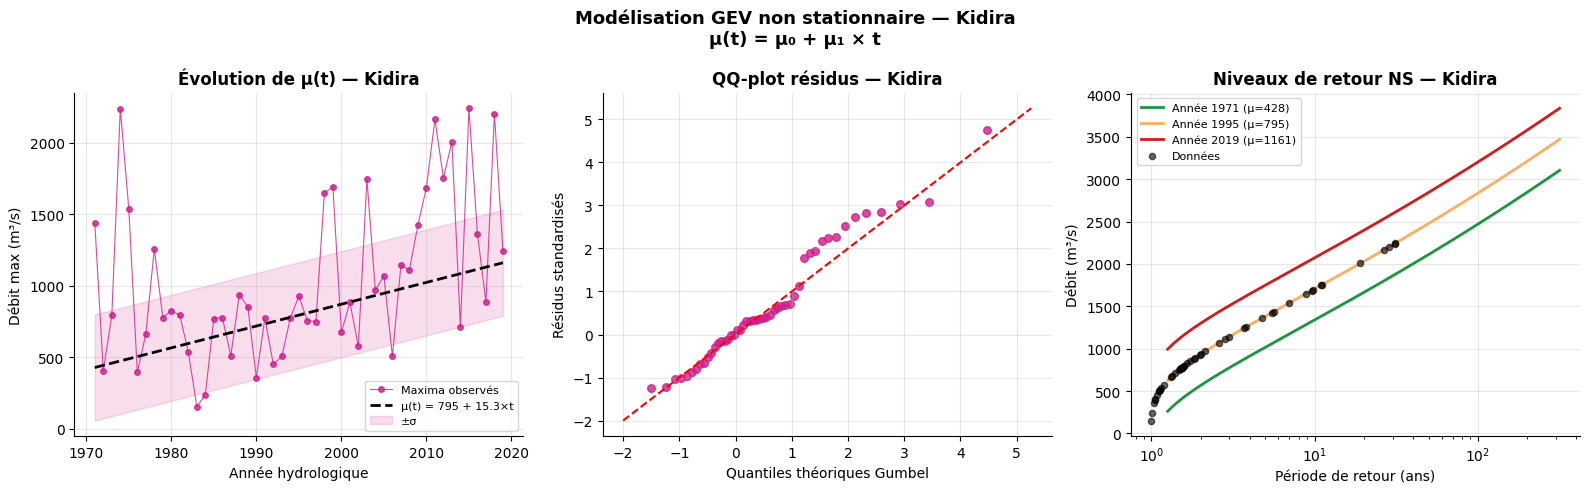

✔ Figure GEV NS sauvegardée.
✔ Paramètres GEV NS sauvegardés.
✔ Niveaux de retour NS sauvegardés.
✔ Prêt pour la modélisation GPD.


In [16]:
# ============================================================
# ANNEXE B — MODÉLISATION GEV NON STATIONNAIRE
# Station : Kidira
# Méthode : Maximum de Vraisemblance (MLE)
# Modèle  : mu(t) = mu0 + mu1 * t
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import genextreme
from scipy.optimize import minimize
from scipy.special import gamma
from lmoments3 import distr

# ---------------------------------------------------
# Fonction estimation GEV par L-moments
# ---------------------------------------------------
def lmom_gev(x):
    
    # Ajustement GEV avec lmoments3
    params = distr.gev.lmom_fit(x)
    
    # Paramètres
    mu = params["loc"]
    sigma = params["scale"]
    
    # Attention :
    # lmoments3 utilise c = -xi
    xi = -params["c"]
    
    return mu, sigma, xi

# ── B.1 Données Kidira ───────────────────────────────────────
x_kidira = AM['kidira_max'].dropna().values
t_kidira = AM['annee_hydro'].dropna().values
n        = len(x_kidira)

# Centrage du temps pour stabilité numérique
t_centre = t_kidira - t_kidira.mean()

print("=== Données Kidira ===")
print(f"N = {n} années | "
      f"De {t_kidira.min()} à {t_kidira.max()}")
print(f"Min = {x_kidira.min():.1f} | "
      f"Max = {x_kidira.max():.1f} m³/s")

# ── B.2 Modèle GEV stationnaire (référence) ─────────────────
print("\n=== Modèle GEV stationnaire — Kidira ===")

mu_s, sigma_s, xi_s = lmom_gev(x_kidira)
xi_scipy_s = -xi_s  # convention scipy

loglik_s = np.sum(
    genextreme.logpdf(x_kidira, xi_scipy_s,
                      loc=mu_s, scale=sigma_s))
k_s  = 3
aic_s = -2 * loglik_s + 2 * k_s
bic_s = -2 * loglik_s + np.log(n) * k_s

print(f"   mu    = {mu_s:.3f}")
print(f"   sigma = {sigma_s:.3f}")
print(f"   xi    = {xi_s:.3f}")
print(f"   Log-lik = {loglik_s:.3f} | "
      f"AIC = {aic_s:.3f} | BIC = {bic_s:.3f}")

# ── B.3 Modèle GEV non stationnaire ─────────────────────────
# mu(t) = mu0 + mu1 * t
# sigma et xi constants
print("\n=== Modèle GEV non stationnaire — Kidira ===")
print("    mu(t) = mu0 + mu1 * t")

def neg_loglik_ns(params, x, t):
    """
    Log-vraisemblance négative du modèle GEV non stationnaire
    params = [mu0, mu1, log_sigma, xi]
    log_sigma pour garantir sigma > 0
    """
    mu0, mu1, log_sigma, xi = params
    sigma = np.exp(log_sigma)
    mu_t  = mu0 + mu1 * t    # mu varie dans le temps

    # Convention scipy : shape = -xi
    logpdf = genextreme.logpdf(
        x, -xi, loc=mu_t, scale=sigma)

    # Pénalisation des valeurs infinies
    if not np.all(np.isfinite(logpdf)):
        return 1e10

    return -np.sum(logpdf)

# Valeurs initiales basées sur le modèle stationnaire
params0 = [mu_s, 0.0, np.log(sigma_s), xi_s]

# Optimisation
res_ns = minimize(
    neg_loglik_ns,
    params0,
    args=(x_kidira, t_centre),
    method='Nelder-Mead',
    options={'maxiter': 10000, 'xatol': 1e-6,
             'fatol': 1e-6}
)

mu0, mu1, log_sigma, xi_ns = res_ns.x
sigma_ns = np.exp(log_sigma)
loglik_ns = -res_ns.fun
k_ns      = 4
aic_ns    = -2 * loglik_ns + 2 * k_ns
bic_ns    = -2 * loglik_ns + np.log(n) * k_ns

print(f"   mu0   = {mu0:.3f}")
print(f"   mu1   = {mu1:.3f} m³/s/an")
print(f"   sigma = {sigma_ns:.3f}")
print(f"   xi    = {xi_ns:.3f}")
print(f"   Log-lik = {loglik_ns:.3f} | "
      f"AIC = {aic_ns:.3f} | BIC = {bic_ns:.3f}")

# ── B.4 Test du rapport de vraisemblance ─────────────────────
print("\n=== Test du rapport de vraisemblance ===")
lrt_stat = 2 * (loglik_ns - loglik_s)
from scipy.stats import chi2
p_lrt = 1 - chi2.cdf(lrt_stat, df=1)

print(f"   Statistique LRT = {lrt_stat:.4f}")
print(f"   p-value         = {p_lrt:.4f}")
print(f"   Conclusion : "
      f"{'Modèle NS significativement meilleur'if p_lrt < 0.05 else 'Pas de gain significatif'}")

# ── B.5 Comparaison AIC/BIC ──────────────────────────────────
print("\n=== Comparaison Stationnaire vs Non Stationnaire ===")
comparaison = pd.DataFrame({
    'Modèle':   ['Stationnaire', 'Non stationnaire'],
    'Paramètres': [k_s, k_ns],
    'Log-lik':  [round(loglik_s, 3), round(loglik_ns, 3)],
    'AIC':      [round(aic_s, 3), round(aic_ns, 3)],
    'BIC':      [round(bic_s, 3), round(bic_ns, 3)]
})
print(comparaison)

meilleur = ('Non stationnaire'
            if aic_ns < aic_s else 'Stationnaire')
print(f"\n   ✔ Modèle retenu : {meilleur} (AIC le plus faible)")

# ── B.6 Niveaux de retour non stationnaires ──────────────────
# Calculés pour l'année de référence (dernière année)
# et pour des années futures
print("\n=== Niveaux de retour non stationnaires ===")

periodes   = [2, 5, 10, 20, 50, 100, 200]
annees_ref = [1971, 1995, 2019]  # début, milieu, fin

resultats_nr_ns = []

for annee in annees_ref:
    t_ref = annee - t_kidira.mean()
    mu_ref = mu0 + mu1 * t_ref

    print(f"\n   Année de référence : {annee} "
          f"(mu = {mu_ref:.1f} m³/s)")
    for T in periodes:
        p  = 1 - 1/T
        nr = genextreme.ppf(
            p, -xi_ns, loc=mu_ref, scale=sigma_ns)
        resultats_nr_ns.append({
            'Annee':   annee,
            'Periode': T,
            'NR':      round(nr, 1),
            'mu_ref':  round(mu_ref, 1)
        })
        print(f"   T = {T:4d} ans : {nr:.1f} m³/s")

resultats_nr_ns_df = pd.DataFrame(resultats_nr_ns)

# ── B.7 Tableau synthétique ──────────────────────────────────
nr_ns_synthetique = (resultats_nr_ns_df
                     [resultats_nr_ns_df['Periode']
                      .isin([10, 50, 100, 200])])
print("\n=== Tableau synthétique ===")
print(nr_ns_synthetique)

# ── B.8 Figure — évolution de mu(t) ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Graphique 1 — évolution de mu(t)
mu_t_all = mu0 + mu1 * t_centre
axes[0].plot(t_kidira, x_kidira,
             color='#d01c8b', marker='o',
             markersize=4, linewidth=0.8,
             label='Maxima observés', alpha=0.8)
axes[0].plot(t_kidira, mu_t_all,
             color='black', linewidth=2,
             linestyle='--',
             label=f'μ(t) = {mu0:.0f} + '
                   f'{mu1:.1f}×t')
axes[0].fill_between(
    t_kidira,
    mu_t_all - sigma_ns,
    mu_t_all + sigma_ns,
    alpha=0.15, color='#d01c8b',
    label='±σ')
axes[0].set_title("Évolution de μ(t) — Kidira",
                  fontweight='bold')
axes[0].set_xlabel("Année hydrologique")
axes[0].set_ylabel("Débit max (m³/s)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Graphique 2 — QQ-plot résidus standardisés
mu_t_all = mu0 + mu1 * t_centre
z_scores  = (x_kidira - mu_t_all) / sigma_ns
z_sort    = np.sort(z_scores)
p_emp     = (np.arange(1, n+1) - 0.44) / (n + 0.12)
q_gumbel  = -np.log(-np.log(p_emp))

axes[1].scatter(q_gumbel, z_sort,
                color='#d01c8b', s=30, alpha=0.8)
lim = [min(q_gumbel.min(), z_sort.min()) - 0.5,
       max(q_gumbel.max(), z_sort.max()) + 0.5]
axes[1].plot(lim, lim, 'r--', linewidth=1.5)
axes[1].set_title("QQ-plot résidus — Kidira",
                  fontweight='bold')
axes[1].set_xlabel("Quantiles théoriques Gumbel")
axes[1].set_ylabel("Résidus standardisés")
axes[1].grid(True, alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Graphique 3 — niveaux de retour pour 3 années
T_range = np.logspace(0.1, 2.5, 300)
p_range = 1 - 1/T_range
couleurs_annees = {1971: '#1a9641',
                   1995: '#fdae61',
                   2019: '#d7191c'}

for annee in annees_ref:
    t_ref  = annee - t_kidira.mean()
    mu_ref = mu0 + mu1 * t_ref
    nr_range = genextreme.ppf(
        p_range, -xi_ns,
        loc=mu_ref, scale=sigma_ns)
    axes[2].plot(T_range, nr_range,
                 color=couleurs_annees[annee],
                 linewidth=2,
                 label=f'Année {annee} '
                       f'(μ={mu_ref:.0f})')

axes[2].scatter(
    1/(1 - genextreme.cdf(
        np.sort(x_kidira), -xi_ns,
        loc=mu0, scale=sigma_ns)),
    np.sort(x_kidira),
    color='black', s=20, alpha=0.6,
    zorder=5, label='Données')
axes[2].set_xscale('log')
axes[2].set_title(
    "Niveaux de retour NS — Kidira",
    fontweight='bold')
axes[2].set_xlabel(
    "Période de retour (ans)")
axes[2].set_ylabel("Débit (m³/s)")
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.suptitle(
    "Modélisation GEV non stationnaire — Kidira\n"
    "μ(t) = μ₀ + μ₁ × t",
    fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig("diagnostic_gev_ns_kidira.png",
            dpi=300, bbox_inches='tight')
plt.show()
print("✔ Figure GEV NS sauvegardée.")

# ── B.9 Sauvegarde ──────────────────────────────────────────
resultats_ns = pd.DataFrame([{
    'Station':  'Kidira',
    'Modele':   'Non stationnaire',
    'mu0':      round(mu0, 3),
    'mu1':      round(mu1, 3),
    'sigma':    round(sigma_ns, 3),
    'xi':       round(xi_ns, 3),
    'loglik':   round(loglik_ns, 3),
    'AIC':      round(aic_ns, 3),
    'BIC':      round(bic_ns, 3),
    'LRT_stat': round(lrt_stat, 4),
    'LRT_pval': round(p_lrt, 4)
}])

resultats_ns.to_csv(
    "annexe_gev_parametres_ns.csv", index=False)
nr_ns_synthetique.to_csv(
    "annexe_gev_niveaux_retour_ns.csv", index=False)
comparaison.to_csv(
    "annexe_gev_comparaison_kidira.csv", index=False)

print("✔ Paramètres GEV NS sauvegardés.")
print("✔ Niveaux de retour NS sauvegardés.")
print("✔ Prêt pour la modélisation GPD.")

In [17]:
# ============================================================
# ANNEXE C — MODÉLISATION GPD (POT)
# Toutes stations
# Méthode : Maximum de Vraisemblance (MLE)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import genpareto
from scipy.optimize import minimize

# ── C.1 Données POT par station ──────────────────────────────
stations_pot = {
    'Daka Saidou': {
        'exces': pot_daka['exces'].values,
        'valeur': pot_daka['valeur'].values,
        'date':   pot_daka['date'].values,
        'seuil':  seuil_daka
    },
    'Gourbassi': {
        'exces': pot_gour['exces'].values,
        'valeur': pot_gour['valeur'].values,
        'date':   pot_gour['date'].values,
        'seuil':  seuil_gour
    },
    'Kidira': {
        'exces': pot_kidi['exces'].values,
        'valeur': pot_kidi['valeur'].values,
        'date':   pot_kidi['date'].values,
        'seuil':  seuil_kidi
    },
    'Oualia': {
        'exces': pot_oual['exces'].values,
        'valeur': pot_oual['valeur'].values,
        'date':   pot_oual['date'].values,
        'seuil':  seuil_oual
    }
}

couleurs = {
    'Daka Saidou': '#2166ac',
    'Gourbassi':   '#4dac26',
    'Kidira':      '#d01c8b',
    'Oualia':      '#f4a582'
}

n_annees  = 49   # nombre d'années d'observation
periodes  = [2, 5, 10, 20, 50, 100, 200]

# ── C.2 Ajustement GPD par MLE ───────────────────────────────
resultats_gpd = []
modeles_gpd   = {}
resultats_nr  = []

for nom, data in stations_pot.items():
    exces  = data['exces']
    seuil  = data['seuil']
    n_pics = len(exces)
    n      = n_pics

    print(f"\n=== Ajustement GPD — {nom} ===")
    print(f"   Nombre de pics : {n_pics} | "
          f"Seuil : {seuil:.2f} m³/s")

    # Taux d'occurrence annuel
    lambda_u = n_pics / n_annees
    print(f"   Taux annuel λ  : {lambda_u:.3f} pics/an")

    # Ajustement GPD par MLE
    # scipy convention : c = xi (shape), scale = sigma
    xi_gpd, _, sigma_gpd = genpareto.fit(
        exces, floc=0)  # floc=0 : excès >= 0

    # Log-vraisemblance
    loglik = np.sum(
        genpareto.logpdf(exces, xi_gpd,
                         loc=0, scale=sigma_gpd))
    k   = 2
    aic = -2 * loglik + 2 * k
    bic = -2 * loglik + np.log(n) * k

    modeles_gpd[nom] = (xi_gpd, sigma_gpd,
                        seuil, lambda_u)

    print(f"   sigma = {sigma_gpd:.3f}")
    print(f"   xi    = {xi_gpd:.3f}")
    print(f"   Log-lik = {loglik:.3f} | "
          f"AIC = {aic:.3f} | BIC = {bic:.3f}")

    resultats_gpd.append({
        'Station':   nom,
        'N_pics':    n_pics,
        'Seuil':     round(seuil, 2),
        'Lambda':    round(lambda_u, 3),
        'sigma':     round(sigma_gpd, 3),
        'xi':        round(xi_gpd, 3),
        'loglik':    round(loglik, 3),
        'AIC':       round(aic, 3),
        'BIC':       round(bic, 3)
    })

    # ── Niveaux de retour GPD ────────────────────────────────
    # Formule : x_T = u + sigma/xi * [(lambda*T)^xi - 1]
    # si xi != 0
    # x_T = u + sigma * log(lambda*T) si xi = 0
    print(f"\n   Niveaux de retour :")
    for T in periodes:
        if abs(xi_gpd) > 1e-6:
            nr = seuil + (sigma_gpd / xi_gpd) * \
                 ((lambda_u * T)**xi_gpd - 1)
        else:
            nr = seuil + sigma_gpd * \
                 np.log(lambda_u * T)

        resultats_nr.append({
            'Station': nom,
            'Periode': T,
            'NR':      round(nr, 1)
        })
        print(f"   T = {T:4d} ans : {nr:.1f} m³/s")

# ── C.3 Tableaux résultats ───────────────────────────────────
resultats_gpd_df = pd.DataFrame(resultats_gpd)
resultats_nr_df  = pd.DataFrame(resultats_nr)

print("\n=== Paramètres GPD estimés ===")
print(resultats_gpd_df)

nr_synthetique = (resultats_nr_df
                  [resultats_nr_df['Periode']
                   .isin([10, 50, 100, 200])]
                  .copy())
print("\n=== Tableau synthétique niveaux de retour ===")
print(nr_synthetique)

# ── C.4 Graphiques de diagnostic ────────────────────────────
for nom, data in stations_pot.items():
    exces     = data['exces']
    seuil     = data['seuil']
    xi_gpd, sigma_gpd, _, lambda_u = modeles_gpd[nom]
    nom_f     = nom.lower().replace(' ', '_')
    n         = len(exces)
    exces_sort = np.sort(exces)
    p_emp      = (np.arange(1, n+1) - 0.44) / (n + 0.12)

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))

    # QQ-plot
    q_theo = genpareto.ppf(p_emp, xi_gpd,
                           loc=0, scale=sigma_gpd)
    axes[0].scatter(q_theo, exces_sort,
                    color=couleurs[nom], s=30, alpha=0.8)
    lim = [0, max(q_theo.max(),
                  exces_sort.max()) * 1.1]
    axes[0].plot(lim, lim, 'r--', linewidth=1.5)
    axes[0].set_title(f"QQ-plot — {nom}",
                      fontweight='bold')
    axes[0].set_xlabel("Quantiles théoriques GPD")
    axes[0].set_ylabel("Excès observés (m³/s)")
    axes[0].grid(True, alpha=0.3)
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)

    # PP-plot
    p_theo = genpareto.cdf(exces_sort, xi_gpd,
                           loc=0, scale=sigma_gpd)
    axes[1].scatter(p_theo, p_emp,
                    color=couleurs[nom], s=30, alpha=0.8)
    axes[1].plot([0, 1], [0, 1], 'r--', linewidth=1.5)
    axes[1].set_title(f"PP-plot — {nom}",
                      fontweight='bold')
    axes[1].set_xlabel("Probabilités théoriques")
    axes[1].set_ylabel("Probabilités empiriques")
    axes[1].grid(True, alpha=0.3)
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)

    # Densité
    x_range = np.linspace(0, exces.max()*1.2, 300)
    axes[2].hist(exces, bins=15, density=True,
                 color=couleurs[nom],
                 alpha=0.5, edgecolor='white')
    axes[2].plot(x_range,
                 genpareto.pdf(x_range, xi_gpd,
                               loc=0, scale=sigma_gpd),
                 color='black', linewidth=2,
                 label='GPD ajustée')
    axes[2].set_title(f"Densité — {nom}",
                      fontweight='bold')
    axes[2].set_xlabel("Excès (m³/s)")
    axes[2].set_ylabel("Densité")
    axes[2].legend(fontsize=9)
    axes[2].grid(True, alpha=0.3)
    axes[2].spines['top'].set_visible(False)
    axes[2].spines['right'].set_visible(False)

    # Niveaux de retour
    T_range = np.logspace(0.1, 2.5, 300)
    if abs(xi_gpd) > 1e-6:
        nr_range = seuil + (sigma_gpd / xi_gpd) * \
                   ((lambda_u * T_range)**xi_gpd - 1)
    else:
        nr_range = seuil + sigma_gpd * \
                   np.log(lambda_u * T_range)

    T_emp    = 1 / (lambda_u * (1 - p_emp))
    axes[3].plot(T_range, nr_range,
                 color=couleurs[nom],
                 linewidth=2, label='GPD')
    axes[3].scatter(T_emp,
                    exces_sort + seuil,
                    color='black', s=20,
                    alpha=0.7, zorder=5,
                    label='Données')
    axes[3].set_xscale('log')
    axes[3].set_title(f"Niveaux de retour — {nom}",
                      fontweight='bold')
    axes[3].set_xlabel("Période de retour (ans)")
    axes[3].set_ylabel("Débit (m³/s)")
    axes[3].legend(fontsize=9)
    axes[3].grid(True, alpha=0.3)
    axes[3].spines['top'].set_visible(False)
    axes[3].spines['right'].set_visible(False)

    plt.suptitle(
        f"Diagnostic GPD (POT) — {nom}",
        fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.savefig(f"diagnostic_gpd_{nom_f}.png",
                dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✔ Figures diagnostic GPD sauvegardées "
          f"pour {nom}")

# ── C.5 Figure comparative niveaux de retour ────────────────
fig, ax = plt.subplots(figsize=(10, 6))
T_range = np.logspace(0.1, 2.5, 300)

for nom, (xi_gpd, sigma_gpd,
          seuil, lambda_u) in modeles_gpd.items():
    if abs(xi_gpd) > 1e-6:
        nr_range = seuil + (sigma_gpd / xi_gpd) * \
                   ((lambda_u * T_range)**xi_gpd - 1)
    else:
        nr_range = seuil + sigma_gpd * \
                   np.log(lambda_u * T_range)

    ax.plot(T_range, nr_range,
            color=couleurs[nom],
            linewidth=2, label=nom)

ax.set_xscale('log')
ax.set_xlabel(
    "Période de retour (ans) — échelle logarithmique")
ax.set_ylabel("Débit (m³/s)")
ax.set_title(
    "Courbes des niveaux de retour — GPD (POT)\n"
    "Toutes stations",
    fontweight='bold', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("niveaux_retour_gpd.png",
            dpi=300, bbox_inches='tight')
plt.show()

# ── C.6 Figure comparative GEV vs GPD ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
stations_communes = ['Daka Saidou', 'Gourbassi', 'Oualia']

for i, nom in enumerate(stations_communes):
    ax      = axes[i]
    T_range = np.logspace(0.3, 2.5, 300)
    p_range = 1 - 1/T_range

    # GEV
    xi_s_gev, mu_gev, sigma_gev = modeles_gev[nom]
    nr_gev = genextreme.ppf(
        p_range, xi_s_gev,
        loc=mu_gev, scale=sigma_gev)
    ax.plot(T_range, nr_gev,
            color=couleurs[nom],
            linewidth=2, linestyle='-',
            label='GEV')

    # GPD
    xi_gpd, sigma_gpd, seuil, lambda_u = \
        modeles_gpd[nom]
    if abs(xi_gpd) > 1e-6:
        nr_gpd = seuil + (sigma_gpd / xi_gpd) * \
                 ((lambda_u * T_range)**xi_gpd - 1)
    else:
        nr_gpd = seuil + sigma_gpd * \
                 np.log(lambda_u * T_range)
    ax.plot(T_range, nr_gpd,
            color=couleurs[nom],
            linewidth=2, linestyle='--',
            label='GPD')

    ax.set_xscale('log')
    ax.set_title(nom, fontweight='bold')
    ax.set_xlabel("Période de retour (ans)")
    ax.set_ylabel("Débit (m³/s)")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle(
    "Comparaison GEV vs GPD — Niveaux de retour",
    fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig("comparaison_gev_gpd.png",
            dpi=300, bbox_inches='tight')
plt.show()

# ── C.7 Sauvegarde ──────────────────────────────────────────
resultats_gpd_df.to_csv(
    "annexe_gpd_parametres.csv", index=False)
nr_synthetique.to_csv(
    "annexe_gpd_niveaux_retour.csv", index=False)

print("\n✔ Paramètres GPD sauvegardés.")
print("✔ Niveaux de retour GPD sauvegardés.")
print("✔ Prêt pour la modélisation Machine Learning.")

NameError: name 'pot_daka' is not defined

In [ ]:
# ============================================================
# ÉTAPE ML.1 — PRÉPARATION DES DONNÉES
# Commune à tous les modèles
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (mean_squared_error,
                             mean_absolute_error)
import warnings
warnings.filterwarnings('ignore')

# ── ML.1.1 Rechargement si nécessaire ────────────────────────
AM     = pd.read_csv("C:\\Users\\LENOVO\\Documents\\Enquêtes\\ENQUETE RECHERC\\maxima_annuels.csv")
debits = pd.read_csv("C:\\Users\\LENOVO\\Documents\\Enquêtes\\ENQUETE RECHERC\\debits_propres.csv",
                     parse_dates=['date'])

cols_max      = ['daka_saidou_max', 'gourbassi_max',
                 'kidira_max', 'oualia_max']
noms_stations = ['Daka Saidou', 'Gourbassi',
                 'Kidira', 'Oualia']
couleurs = {
    'Daka Saidou': '#2166ac',
    'Gourbassi':   '#4dac26',
    'Kidira':      '#d01c8b',
    'Oualia':      '#f4a582'
}

# ── ML.1.2 Construction des features ─────────────────────────
features = ['annee_norm', 'annee2',
            'lag1', 'lag2', 'lag3',
            'moy_3', 'moy_5', 'std_3']

def construire_features(serie, nom_station):
    df = pd.DataFrame({
        'annee': AM['annee_hydro'].values,
        'y':     serie
    }).dropna().reset_index(drop=True)

    # Tendance temporelle
    df['annee_norm'] = (df['annee'] -
                        df['annee'].min()) / \
                       (df['annee'].max() -
                        df['annee'].min())
    df['annee2'] = df['annee_norm']**2

    # Lags
    df['lag1'] = df['y'].shift(1)
    df['lag2'] = df['y'].shift(2)
    df['lag3'] = df['y'].shift(3)

    # Moyennes et écart-type mobiles
    df['moy_3'] = df['y'].shift(1).rolling(3).mean()
    df['moy_5'] = df['y'].shift(1).rolling(5).mean()
    df['std_3'] = df['y'].shift(1).rolling(3).std()

    # Imputation NA par la moyenne
    cols_imp = ['lag1', 'lag2', 'lag3',
                'moy_3', 'moy_5', 'std_3']
    for col in cols_imp:
        n_na = df[col].isna().sum()
        if n_na > 0:
            moy = df[col].mean(skipna=True)
            df[col] = df[col].fillna(moy)

    df['station'] = nom_station
    return df

# Construction pour chaque station
dfs = {}
for col, nom in zip(cols_max, noms_stations):
    serie    = AM[col].values
    dfs[nom] = construire_features(serie, nom)

print("=== Aperçu des features ===")
print(dfs['Daka Saidou'][features + ['y']].head(8))

# ── ML.1.3 Split train/test ───────────────────────────────────
# Dernières 10 années = test
n_test = 10

splits = {}
for nom, df in dfs.items():
    n       = len(df)
    n_train = n - n_test
    train   = df.iloc[:n_train]
    test    = df.iloc[n_train:]

    splits[nom] = {
        'X_train':     train[features].values,
        'y_train':     train['y'].values,
        'X_test':      test[features].values,
        'y_test':      test['y'].values,
        'annee_train': train['annee'].values,
        'annee_test':  test['annee'].values
    }

print("\n=== Split train/test ===")
for nom, data in splits.items():
    df = dfs[nom]
    print(f"\n{nom} :")
    print(f"   Train : {data['annee_train'].min()}–"
          f"{data['annee_train'].max()} "
          f"({len(data['y_train'])} années)")
    print(f"   Test  : {data['annee_test'].min()}–"
          f"{data['annee_test'].max()} "
          f"({len(data['y_test'])} années)")

# ── ML.1.4 Fonction métriques ────────────────────────────────
def calculer_metriques(y_true, y_pred,
                       nom_modele, nom_station):
    rmse = np.sqrt(mean_squared_error(
        y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(
        np.abs((y_true - y_pred) /
               y_true)) * 100
    return {
        'Station': nom_station,
        'Modele':  nom_modele,
        'RMSE':    round(rmse, 3),
        'MAE':     round(mae, 3),
        'MAPE':    round(mape, 3)
    }

print("\n✔ Données préparées pour tous les modèles.")
print(f"✔ Features : {features}")
print(f"✔ Train : {49 - n_test} années | "
      f"Test : {n_test} années")
print("\n✔ Prêt pour Random Forest (étape ML.2)")

In [ ]:
# ============================================================
# ÉTAPE ML.2 — RANDOM FOREST
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# ── ML.2.1 Optimisation des hyperparamètres ──────────────────
print("=== Optimisation hyperparamètres RF ===")

param_grid = {
    'n_estimators':     [100, 300, 500],
    'max_depth':        [3, 5, 7, None],
    'min_samples_leaf': [2, 3, 5],
    'max_features':     ['sqrt', 'log2']
}

resultats_rf   = []
modeles_rf     = {}
predictions_rf = {}
meilleurs_params_rf = {}

for nom, data in splits.items():
    print(f"\n--- {nom} ---")

    # Grid Search avec validation croisée
    rf_base = RandomForestRegressor(
        random_state=42, n_jobs=-1)

    grid_search = GridSearchCV(
        rf_base,
        param_grid,
        cv           = 5,
        scoring      = 'neg_mean_squared_error',
        n_jobs       = -1,
        verbose      = 0
    )
    grid_search.fit(
        data['X_train'],
        data['y_train'])

    meilleurs_params = grid_search.best_params_
    meilleurs_params_rf[nom] = meilleurs_params
    print(f"   Meilleurs paramètres : "
          f"{meilleurs_params}")

    # Entraînement avec meilleurs paramètres
    rf = RandomForestRegressor(
        **meilleurs_params,
        random_state = 42,
        n_jobs       = -1
    )
    rf.fit(data['X_train'], data['y_train'])

    # Prédictions
    y_pred_train = rf.predict(data['X_train'])
    y_pred_test  = rf.predict(data['X_test'])

    modeles_rf[nom]     = rf
    predictions_rf[nom] = {
        'train': y_pred_train,
        'test':  y_pred_test
    }

    # Métriques train
    metr_train = calculer_metriques(
        data['y_train'], y_pred_train,
        'RF_train', nom)

    # Métriques test
    metr_test = calculer_metriques(
        data['y_test'], y_pred_test,
        'Random Forest', nom)
    resultats_rf.append(metr_test)

    print(f"   Train : RMSE={metr_train['RMSE']:.2f} | "
          f"MAE={metr_train['MAE']:.2f} | "
          f"MAPE={metr_train['MAPE']:.2f}%")
    print(f"   Test  : RMSE={metr_test['RMSE']:.2f} | "
          f"MAE={metr_test['MAE']:.2f} | "
          f"MAPE={metr_test['MAPE']:.2f}%")

# ── ML.2.2 Tableau résultats RF ──────────────────────────────
resultats_rf_df = pd.DataFrame(resultats_rf)
print("\n=== Résumé Random Forest ===")
print(resultats_rf_df)

# ── ML.2.3 Importance des variables ──────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

importances_rf = {}
for i, nom in enumerate(noms_stations):
    ax = axes[i]
    rf = modeles_rf[nom]

    importances = pd.Series(
        rf.feature_importances_,
        index=features
    ).sort_values(ascending=True)
    importances_rf[nom] = importances

    colors = [couleurs[nom]
              if v >= importances.quantile(0.5)
              else '#cccccc'
              for v in importances.values]

    importances.plot(
        kind='barh', ax=ax,
        color=colors,
        edgecolor='white',
        linewidth=0.5)

    ax.set_title(
        f"Importance des variables — {nom}",
        fontweight='bold', fontsize=11)
    ax.set_xlabel("Importance (impureté de Gini)")
    ax.axvline(x=1/len(features),
               color='red', linestyle='--',
               linewidth=1, alpha=0.7,
               label='Importance uniforme')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='x')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle(
    "Importance des variables — Random Forest\n"
    "Variables colorées : au-dessus de la médiane",
    fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig("rf_importance_variables.png",
            dpi=300, bbox_inches='tight')
plt.show()
print("✔ Figure importance sauvegardée.")

# ── ML.2.4 Visualisation observé vs prédit ───────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, nom in enumerate(noms_stations):
    ax   = axes[i]
    data = splits[nom]

    # Train
    ax.plot(data['annee_train'],
            data['y_train'],
            color='grey', linewidth=0.8,
            alpha=0.5, label='Train observé')
    ax.plot(data['annee_train'],
            predictions_rf[nom]['train'],
            color=couleurs[nom],
            linewidth=0.8, linestyle='--',
            alpha=0.5, label='Train prédit')

    # Test
    ax.plot(data['annee_test'],
            data['y_test'],
            color='black', linewidth=2,
            marker='o', markersize=6,
            label='Test observé')
    ax.plot(data['annee_test'],
            predictions_rf[nom]['test'],
            color=couleurs[nom],
            linewidth=2, linestyle='--',
            marker='s', markersize=5,
            label='Test prédit (RF)')

    # Ligne verticale train/test
    ax.axvline(
        x=data['annee_test'].min() - 0.5,
        color='red', linestyle=':',
        linewidth=1.5, alpha=0.7,
        label='Séparation train/test')

    ax.set_title(nom, fontweight='bold',
                 fontsize=12)
    ax.set_xlabel("Année hydrologique")
    ax.set_ylabel("Débit max (m³/s)")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle(
    "Random Forest — Observé vs Prédit\n"
    "Train (1971–2009) | Test (2010–2019)",
    fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig("rf_predictions.png",
            dpi=300, bbox_inches='tight')
plt.show()
print("✔ Figure prédictions RF sauvegardée.")

# ── ML.2.5 Courbe d'apprentissage ────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, nom in enumerate(noms_stations):
    ax   = axes[i]
    data = splits[nom]
    params = meilleurs_params_rf[nom].copy()

    train_scores = []
    test_scores  = []
    n_trees      = [10, 50, 100, 200, 300, 500]

    for n in n_trees:
        rf_tmp = RandomForestRegressor(
            n_estimators    = n,
            max_depth       = params['max_depth'],
            min_samples_leaf= params['min_samples_leaf'],
            max_features    = params['max_features'],
            random_state    = 42,
            n_jobs          = -1
        )
        rf_tmp.fit(data['X_train'], data['y_train'])

        rmse_train = np.sqrt(mean_squared_error(
            data['y_train'],
            rf_tmp.predict(data['X_train'])))
        rmse_test  = np.sqrt(mean_squared_error(
            data['y_test'],
            rf_tmp.predict(data['X_test'])))

        train_scores.append(rmse_train)
        test_scores.append(rmse_test)

    ax.plot(n_trees, train_scores,
            color=couleurs[nom],
            linewidth=1.5, marker='o',
            markersize=4, label='Train RMSE')
    ax.plot(n_trees, test_scores,
            color='red', linewidth=1.5,
            marker='s', markersize=4,
            linestyle='--', label='Test RMSE')
    ax.set_title(nom, fontweight='bold')
    ax.set_xlabel("Nombre d'arbres")
    ax.set_ylabel("RMSE (m³/s)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle(
    "Courbe d'apprentissage — Random Forest",
    fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig("rf_courbe_apprentissage.png",
            dpi=300, bbox_inches='tight')
plt.show()
print("✔ Figure courbe apprentissage sauvegardée.")

# ── ML.2.6 Sauvegarde ────────────────────────────────────────
resultats_rf_df.to_csv(
    "rf_metriques.csv", index=False)

print("\n=== Meilleurs hyperparamètres RF ===")
for nom, params in meilleurs_params_rf.items():
    print(f"   {nom} : {params}")

print("\n✔ Résultats Random Forest sauvegardés.")
print("✔ Prêt pour XGBoost (étape ML.3)")

In [ ]:
!pip install xgboost

In [ ]:
# ============================================================
# ÉTAPE ML.2 — RANDOM FOREST (version propre et robuste)
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ------------------------------------------------------------
# 0) Paramètres globaux
# ------------------------------------------------------------
np.random.seed(42)
OUTPUT_DIR = Path("sorties_random_forest")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 1) Vérifications d'entrée
# ------------------------------------------------------------
if "splits" not in globals():
    raise NameError(
        "Le dictionnaire 'splits' est introuvable. "
        "Il doit contenir, pour chaque station, les clés : "
        "'X_train', 'X_test', 'y_train', 'y_test'."
    )

if not isinstance(splits, dict) or len(splits) == 0:
    raise ValueError("'splits' doit être un dictionnaire non vide.")

required_keys = {"X_train", "X_test", "y_train", "y_test"}

for station, data in splits.items():
    missing = required_keys - set(data.keys())
    if missing:
        raise KeyError(
            f"La station '{station}' ne contient pas les clés requises : {missing}"
        )

# ------------------------------------------------------------
# 2) Fonctions utilitaires
# ------------------------------------------------------------
def to_1d(y):
    """Convertit y en vecteur 1D numpy."""
    if isinstance(y, (pd.Series, pd.DataFrame)):
        y = np.asarray(y).ravel()
    else:
        y = np.array(y).ravel()
    return y

def get_feature_names(X):
    """Récupère les noms des variables explicatives."""
    if isinstance(X, pd.DataFrame):
        return list(X.columns)
    return [f"X{i+1}" for i in range(X.shape[1])]

def get_time_axis(data, split_name):
    """
    Retourne l'axe temporel pour train/test.
    Priorité :
    - data['annee_train'] ou data['annee_test']
    - index de y_train / y_test si pertinent
    - sinon un index numérique
    """
    year_key = f"annee_{split_name}"
    y_key = f"y_{split_name}"

    if year_key in data:
        return np.asarray(data[year_key])

    y = data[y_key]
    if isinstance(y, pd.Series) and not isinstance(y.index, pd.RangeIndex):
        return np.asarray(y.index)

    return np.arange(len(y))

def calculer_metriques(y_true, y_pred, modele, station, jeu):
    """Calcule les métriques de performance."""
    y_true = to_1d(y_true)
    y_pred = to_1d(y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    # MAPE robuste : ignore les y_true == 0
    mask = y_true != 0
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.nan

    # R²
    if len(np.unique(y_true)) > 1:
        r2 = r2_score(y_true, y_pred)
    else:
        r2 = np.nan

    return {
        "Station": station,
        "Modele": modele,
        "Jeu": jeu,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape,
        "R2": r2
    }

def make_tscv(n_samples, desired_splits=5):
    """
    Crée un TimeSeriesSplit robuste selon la taille de l'échantillon.
    """
    if n_samples < 6:
        raise ValueError(
            f"Pas assez d'observations d'entraînement ({n_samples}) "
            "pour une validation croisée temporelle fiable."
        )
    n_splits = min(desired_splits, n_samples - 1)
    return TimeSeriesSplit(n_splits=n_splits)

# ------------------------------------------------------------
# 3) Paramètres RF
# ------------------------------------------------------------
print("=== Optimisation des hyperparamètres Random Forest ===")

param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", "log2"]
}

noms_stations = list(splits.keys())

# Palette automatique si 'couleurs' n'existe pas
if "couleurs" in globals() and isinstance(couleurs, dict):
    couleurs_plot = couleurs.copy()
else:
    cmap = plt.get_cmap("tab10")
    couleurs_plot = {
        station: cmap(i % 10) for i, station in enumerate(noms_stations)
    }

# ------------------------------------------------------------
# 4) Entraînement + optimisation
# ------------------------------------------------------------
resultats_complets_rf = []
resultats_test_rf = []
modeles_rf = {}
predictions_rf = {}
meilleurs_params_rf = {}
importances_rf = {}
feature_names_by_station = {}

for station, data in splits.items():
    print(f"\n--- Station : {station} ---")

    X_train = data["X_train"]
    X_test = data["X_test"]
    y_train = to_1d(data["y_train"])
    y_test = to_1d(data["y_test"])

    feature_names = get_feature_names(X_train)
    feature_names_by_station[station] = feature_names

    if len(X_train) <= 5:
        raise ValueError(
            f"Pas assez de données d'entraînement pour la station {station} "
            f"(n={len(X_train)})."
        )

    # Validation croisée temporelle
    tscv = make_tscv(len(X_train), desired_splits=5)

    # Pendant GridSearchCV, on évite la sur-parallélisation interne
    rf_base = RandomForestRegressor(
        random_state=42,
        n_jobs=1
    )

    grid_search = GridSearchCV(
        estimator=rf_base,
        param_grid=param_grid,
        cv=tscv,
        scoring="neg_mean_squared_error",
        n_jobs=-1,
        verbose=0,
        refit=True,
        error_score="raise"
    )

    grid_search.fit(X_train, y_train)

    best_params = grid_search.best_params_
    meilleurs_params_rf[station] = best_params
    print(f"Meilleurs paramètres : {best_params}")

    # Réentraînement final avec parallélisation complète
    rf = RandomForestRegressor(
        **best_params,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)

    y_pred_train = rf.predict(X_train)
    y_pred_test = rf.predict(X_test)

    modeles_rf[station] = rf
    predictions_rf[station] = {
        "train": y_pred_train,
        "test": y_pred_test
    }

    # Importances basées sur réduction d'impureté
    importances = pd.Series(
        rf.feature_importances_,
        index=feature_names,
        name=station
    ).sort_values(ascending=False)
    importances_rf[station] = importances

    # Métriques
    metr_train = calculer_metriques(
        y_true=y_train,
        y_pred=y_pred_train,
        modele="Random Forest",
        station=station,
        jeu="Train"
    )

    metr_test = calculer_metriques(
        y_true=y_test,
        y_pred=y_pred_test,
        modele="Random Forest",
        station=station,
        jeu="Test"
    )

    resultats_complets_rf.extend([metr_train, metr_test])
    resultats_test_rf.append(metr_test)

    print(
        f"Train | RMSE={metr_train['RMSE']:.2f} | "
        f"MAE={metr_train['MAE']:.2f} | "
        f"MAPE={metr_train['MAPE']:.2f}% | "
        f"R²={metr_train['R2']:.3f}"
    )
    print(
        f"Test  | RMSE={metr_test['RMSE']:.2f} | "
        f"MAE={metr_test['MAE']:.2f} | "
        f"MAPE={metr_test['MAPE']:.2f}% | "
        f"R²={metr_test['R2']:.3f}"
    )

# ------------------------------------------------------------
# 5) Tableaux de résultats
# ------------------------------------------------------------
resultats_rf_df = pd.DataFrame(resultats_complets_rf)
resultats_test_rf_df = pd.DataFrame(resultats_test_rf)

params_rf_df = pd.DataFrame.from_dict(
    meilleurs_params_rf, orient="index"
).reset_index().rename(columns={"index": "Station"})

print("\n=== Résultats complets Random Forest ===")
print(resultats_rf_df)

print("\n=== Résultats test Random Forest ===")
print(resultats_test_rf_df)

print("\n=== Meilleurs hyperparamètres RF ===")
print(params_rf_df)

# Sauvegardes CSV
resultats_rf_df.to_csv(OUTPUT_DIR / "rf_metriques_completes.csv", index=False)
resultats_test_rf_df.to_csv(OUTPUT_DIR / "rf_metriques_test.csv", index=False)
params_rf_df.to_csv(OUTPUT_DIR / "rf_meilleurs_hyperparametres.csv", index=False)

# ------------------------------------------------------------
# 6) Figure 1 — Importance des variables
# ------------------------------------------------------------
n_stations = len(noms_stations)
ncols = 2
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.5 * nrows))
axes = np.atleast_1d(axes).flatten()

for i, station in enumerate(noms_stations):
    ax = axes[i]
    importances = importances_rf[station].sort_values(ascending=True)

    mediane = importances.median()
    colors = [
        couleurs_plot[station] if val >= mediane else "#cccccc"
        for val in importances.values
    ]

    importances.plot(
        kind="barh",
        ax=ax,
        color=colors,
        edgecolor="white",
        linewidth=0.5
    )

    ax.set_title(f"Importance des variables — {station}", fontweight="bold", fontsize=11)
    ax.set_xlabel("Importance (réduction moyenne de l'impureté)")
    ax.axvline(
        x=1 / len(importances),
        color="red",
        linestyle="--",
        linewidth=1,
        alpha=0.7,
        label="Importance uniforme"
    )
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis="x")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Supprimer axes vides
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Random Forest — Importance des variables\n"
    "Variables colorées : importance ≥ médiane",
    fontweight="bold",
    fontsize=13
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "rf_importance_variables.png", dpi=300, bbox_inches="tight")
plt.show()

print("✔ Figure 'importance des variables' sauvegardée.")

# ------------------------------------------------------------
# 7) Figure 2 — Observé vs prédit
# ------------------------------------------------------------
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5 * nrows))
axes = np.atleast_1d(axes).flatten()

for i, station in enumerate(noms_stations):
    ax = axes[i]
    data = splits[station]

    x_train = get_time_axis(data, "train")
    x_test = get_time_axis(data, "test")

    y_train = to_1d(data["y_train"])
    y_test = to_1d(data["y_test"])

    # Train
    ax.plot(
        x_train, y_train,
        color="grey", linewidth=1.0, alpha=0.5, label="Train observé"
    )
    ax.plot(
        x_train, predictions_rf[station]["train"],
        color=couleurs_plot[station], linewidth=1.0, linestyle="--",
        alpha=0.6, label="Train prédit"
    )

    # Test
    ax.plot(
        x_test, y_test,
        color="black", linewidth=2, marker="o", markersize=5,
        label="Test observé"
    )
    ax.plot(
        x_test, predictions_rf[station]["test"],
        color=couleurs_plot[station], linewidth=2, linestyle="--",
        marker="s", markersize=5, label="Test prédit (RF)"
    )

    # Séparation train / test si axe numérique
    try:
        sep_x = x_test.min() - 0.5
        ax.axvline(
            x=sep_x, color="red", linestyle=":",
            linewidth=1.5, alpha=0.7, label="Séparation train/test"
        )
    except Exception:
        pass

    ax.set_title(station, fontweight="bold", fontsize=12)
    ax.set_xlabel("Année hydrologique")
    ax.set_ylabel("Débit max (m³/s)")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Supprimer axes vides
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Random Forest — Observé vs Prédit",
    fontweight="bold",
    fontsize=13
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "rf_predictions.png", dpi=300, bbox_inches="tight")
plt.show()

print("✔ Figure 'observé vs prédit' sauvegardée.")

# ------------------------------------------------------------
# 8) Figure 3 — Courbe d'apprentissage simplifiée
# ------------------------------------------------------------
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.5 * nrows))
axes = np.atleast_1d(axes).flatten()

n_trees_grid = [10, 50, 100, 200, 300, 500]

for i, station in enumerate(noms_stations):
    ax = axes[i]
    data = splits[station]

    X_train = data["X_train"]
    X_test = data["X_test"]
    y_train = to_1d(data["y_train"])
    y_test = to_1d(data["y_test"])

    best_params = meilleurs_params_rf[station].copy()

    train_scores = []
    test_scores = []

    for n_trees in n_trees_grid:
        params_tmp = best_params.copy()
        params_tmp["n_estimators"] = n_trees

        rf_tmp = RandomForestRegressor(
            **params_tmp,
            random_state=42,
            n_jobs=-1
        )
        rf_tmp.fit(X_train, y_train)

        pred_train = rf_tmp.predict(X_train)
        pred_test = rf_tmp.predict(X_test)

        rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
        rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))

        train_scores.append(rmse_train)
        test_scores.append(rmse_test)

    ax.plot(
        n_trees_grid, train_scores,
        color=couleurs_plot[station], linewidth=1.5,
        marker="o", markersize=4, label="Train RMSE"
    )
    ax.plot(
        n_trees_grid, test_scores,
        color="red", linewidth=1.5,
        linestyle="--", marker="s", markersize=4, label="Test RMSE"
    )

    ax.set_title(station, fontweight="bold")
    ax.set_xlabel("Nombre d'arbres")
    ax.set_ylabel("RMSE (m³/s)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Supprimer axes vides
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Random Forest — Courbe d'apprentissage",
    fontweight="bold",
    fontsize=13
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "rf_courbe_apprentissage.png", dpi=300, bbox_inches="tight")
plt.show()

print("✔ Figure 'courbe d'apprentissage' sauvegardée.")

# ------------------------------------------------------------
# 9) Objet final réutilisable
# ------------------------------------------------------------
rf_outputs = {
    "modeles_rf": modeles_rf,
    "predictions_rf": predictions_rf,
    "meilleurs_params_rf": meilleurs_params_rf,
    "importances_rf": importances_rf,
    "resultats_rf_df": resultats_rf_df,
    "resultats_test_rf_df": resultats_test_rf_df,
    "params_rf_df": params_rf_df,
    "output_dir": OUTPUT_DIR
}

print("\n✔ Tous les résultats Random Forest ont été sauvegardés dans :", OUTPUT_DIR.resolve())
print("✔ Objet final disponible : rf_outputs")
print("✔ Étape Random Forest terminée.")


In [ ]:
# ============================================================
# ÉTAPE ML.3 — XGBOOST
# ============================================================

import xgboost as xgb
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# ── ML.3.1 Optimisation des hyperparamètres ──────────────────
print("=== Optimisation hyperparamètres XGBoost ===")

param_grid_xgb = {
    'n_estimators':     [100, 300, 500],
    'max_depth':        [3, 4, 5],
    'learning_rate':    [0.01, 0.05, 0.1],
    'subsample':        [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

# Validation croisée temporelle
tscv = TimeSeriesSplit(n_splits=5)

resultats_xgb        = []
modeles_xgb          = {}
predictions_xgb      = {}
meilleurs_params_xgb = {}

for nom, data in splits.items():
    print(f"\n--- {nom} ---")

    xgb_base = xgb.XGBRegressor(
        random_state = 42,
        verbosity    = 0
    )

    grid_search = GridSearchCV(
        xgb_base,
        param_grid_xgb,
        cv      = tscv,
        scoring = 'neg_mean_squared_error',
        n_jobs  = -1,
        verbose = 0
    )
    grid_search.fit(
        data['X_train'],
        data['y_train'])

    meilleurs_params = grid_search.best_params_
    meilleurs_params_xgb[nom] = meilleurs_params
    print(f"   Meilleurs paramètres : "
          f"{meilleurs_params}")

    # Entraînement final
    model_xgb = xgb.XGBRegressor(
        **meilleurs_params,
        random_state = 42,
        verbosity    = 0
    )
    model_xgb.fit(
        data['X_train'],
        data['y_train'],
        eval_set = [
            (data['X_train'], data['y_train']),
            (data['X_test'],  data['y_test'])
        ],
        verbose = False
    )

    # Prédictions
    y_pred_train = model_xgb.predict(data['X_train'])
    y_pred_test  = model_xgb.predict(data['X_test'])

    modeles_xgb[nom]     = model_xgb
    predictions_xgb[nom] = {
        'train': y_pred_train,
        'test':  y_pred_test
    }

    # Métriques
    metr_train = calculer_metriques(
        data['y_train'], y_pred_train,
        'XGB_train', nom)
    metr_test = calculer_metriques(
        data['y_test'], y_pred_test,
        'XGBoost', nom)
    resultats_xgb.append(metr_test)

    print(f"   Train : RMSE={metr_train['RMSE']:.2f} | "
          f"MAE={metr_train['MAE']:.2f} | "
          f"MAPE={metr_train['MAPE']:.2f}%")
    print(f"   Test  : RMSE={metr_test['RMSE']:.2f} | "
          f"MAE={metr_test['MAE']:.2f} | "
          f"MAPE={metr_test['MAPE']:.2f}%")

# ── ML.3.2 Tableau résultats ──────────────────────────────────
resultats_xgb_df = pd.DataFrame(resultats_xgb)
print("\n=== Résumé XGBoost ===")
print(resultats_xgb_df)

# ── ML.3.3 Importance des variables ──────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, nom in enumerate(noms_stations):
    ax  = axes[i]
    mdl = modeles_xgb[nom]

    importances = pd.Series(
        mdl.feature_importances_,
        index=features
    ).sort_values(ascending=True)

    colors = [couleurs[nom]
              if v >= importances.quantile(0.5)
              else '#cccccc'
              for v in importances.values]

    importances.plot(
        kind      = 'barh',
        ax        = ax,
        color     = colors,
        edgecolor = 'white')

    ax.set_title(
        f"Importance — {nom}",
        fontweight='bold', fontsize=11)
    ax.set_xlabel("Importance (gain)")
    ax.axvline(
        x         = 1/len(features),
        color     = 'red',
        linestyle = '--',
        linewidth = 1,
        alpha     = 0.7,
        label     = 'Importance uniforme')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='x')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle(
    "Importance des variables — XGBoost",
    fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig("xgb_importance_variables.png",
            dpi=300, bbox_inches='tight')
plt.show()
print("✔ Figure importance sauvegardée.")

# ── ML.3.4 Observé vs Prédit ─────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, nom in enumerate(noms_stations):
    ax   = axes[i]
    data = splits[nom]

    ax.plot(data['annee_train'],
            data['y_train'],
            color='grey', linewidth=0.8,
            alpha=0.5, label='Train observé')
    ax.plot(data['annee_train'],
            predictions_xgb[nom]['train'],
            color=couleurs[nom],
            linewidth=0.8, linestyle='--',
            alpha=0.5, label='Train prédit')
    ax.plot(data['annee_test'],
            data['y_test'],
            color='black', linewidth=2,
            marker='o', markersize=6,
            label='Test observé')
    ax.plot(data['annee_test'],
            predictions_xgb[nom]['test'],
            color=couleurs[nom],
            linewidth=2, linestyle='--',
            marker='s', markersize=5,
            label='Test prédit (XGB)')
    ax.axvline(
        x=data['annee_test'].min() - 0.5,
        color='red', linestyle=':',
        linewidth=1.5, alpha=0.7,
        label='Séparation train/test')

    ax.set_title(nom, fontweight='bold',
                 fontsize=12)
    ax.set_xlabel("Année hydrologique")
    ax.set_ylabel("Débit max (m³/s)")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle(
    "XGBoost — Observé vs Prédit\n"
    "Train (1971–2009) | Test (2010–2019)",
    fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig("xgb_predictions.png",
            dpi=300, bbox_inches='tight')
plt.show()
print("✔ Figure prédictions sauvegardée.")

# ── ML.3.5 Courbe d'apprentissage ────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, nom in enumerate(noms_stations):
    ax      = axes[i]
    results = modeles_xgb[nom].evals_result()
    epochs  = len(results['validation_0']['rmse'])

    ax.plot(range(epochs),
            results['validation_0']['rmse'],
            color=couleurs[nom],
            linewidth=1.5,
            label='Train RMSE')
    ax.plot(range(epochs),
            results['validation_1']['rmse'],
            color='red', linewidth=1.5,
            linestyle='--',
            label='Test RMSE')
    ax.set_title(nom, fontweight='bold')
    ax.set_xlabel("Nombre d'itérations")
    ax.set_ylabel("RMSE (m³/s)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle(
    "Courbe d'apprentissage — XGBoost",
    fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig("xgb_courbe_apprentissage.png",
            dpi=300, bbox_inches='tight')
plt.show()
print("✔ Figure courbe apprentissage sauvegardée.")

# ── ML.3.6 Sauvegarde ────────────────────────────────────────
resultats_xgb_df.to_csv(
    "xgb_metriques.csv", index=False)

print("\n=== Meilleurs hyperparamètres XGBoost ===")
for nom, params in meilleurs_params_xgb.items():
    print(f"   {nom} : {params}")

print("\n✔ Résultats XGBoost sauvegardés.")
print("✔ Prêt pour LSTM (étape ML.4)")

In [ ]:
# ============================================================
# ÉTAPE ML.4 — LSTM
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (LSTM, Dense,
                                     Dropout,
                                     BatchNormalization)
from tensorflow.keras.callbacks import (EarlyStopping,
                                        ReduceLROnPlateau)
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

# ── ML.4.1 Préparation données LSTM ──────────────────────────
print("=== Préparation données LSTM ===")

resultats_lstm   = []
modeles_lstm     = {}
predictions_lstm = {}
scalers_X        = {}
scalers_y        = {}
histories        = {}

for nom, data in splits.items():
    print(f"\n--- {nom} ---")

    # Normalisation MinMax
    scaler_X = MinMaxScaler(feature_range=(0, 1))
    scaler_y = MinMaxScaler(feature_range=(0, 1))

    X_train_sc = scaler_X.fit_transform(
        data['X_train'])
    X_test_sc  = scaler_X.transform(
        data['X_test'])
    y_train_sc = scaler_y.fit_transform(
        data['y_train'].reshape(-1, 1))

    # Reshape LSTM [samples, timesteps, features]
    X_train_lstm = X_train_sc.reshape(
        X_train_sc.shape[0], 1,
        X_train_sc.shape[1])
    X_test_lstm  = X_test_sc.reshape(
        X_test_sc.shape[0], 1,
        X_test_sc.shape[1])

    scalers_X[nom] = scaler_X
    scalers_y[nom] = scaler_y

    # ── ML.4.2 Architecture LSTM ─────────────────────────────
    model_lstm = Sequential([

        # Couche 1 — LSTM principale
        LSTM(64,
             input_shape      = (1, len(features)),
             return_sequences = True,
             kernel_regularizer = tf.keras.regularizers.l2(0.01)),
        BatchNormalization(),
        Dropout(0.3),

        # Couche 2 — LSTM secondaire
        LSTM(32,
             return_sequences = False,
             kernel_regularizer = tf.keras.regularizers.l2(0.01)),
        BatchNormalization(),
        Dropout(0.2),

        # Couches denses
        Dense(16, activation='relu'),
        Dropout(0.1),
        Dense(1)
    ])

    # Compilation
    model_lstm.compile(
        optimizer = Adam(learning_rate=0.001),
        loss      = 'mse',
        metrics   = ['mae']
    )

    print(f"   Architecture LSTM :")
    model_lstm.summary()

    # ── ML.4.3 Callbacks ─────────────────────────────────────
    callbacks = [
        # Arrêt si pas d'amélioration
        EarlyStopping(
            monitor              = 'val_loss',
            patience             = 50,
            restore_best_weights = True,
            verbose              = 0),

        # Réduction du learning rate
        ReduceLROnPlateau(
            monitor  = 'val_loss',
            factor   = 0.5,
            patience = 20,
            min_lr   = 1e-6,
            verbose  = 0)
    ]

    # ── ML.4.4 Entraînement ───────────────────────────────────
    history = model_lstm.fit(
        X_train_lstm,
        y_train_sc,
        epochs           = 500,
        batch_size       = 8,
        validation_split = 0.2,
        callbacks        = callbacks,
        verbose          = 0
    )

    n_epochs = len(history.history['loss'])
    print(f"   Epochs effectués : {n_epochs}")
    print(f"   Meilleur val_loss : "
          f"{min(history.history['val_loss']):.6f}")

    histories[nom]    = history
    modeles_lstm[nom] = model_lstm

    # ── ML.4.5 Prédictions ───────────────────────────────────
    y_pred_train_sc = model_lstm.predict(
        X_train_lstm, verbose=0)
    y_pred_test_sc  = model_lstm.predict(
        X_test_lstm,  verbose=0)

    y_pred_train = scaler_y.inverse_transform(
        y_pred_train_sc).flatten()
    y_pred_test  = scaler_y.inverse_transform(
        y_pred_test_sc).flatten()

    predictions_lstm[nom] = {
        'train': y_pred_train,
        'test':  y_pred_test
    }

    # Métriques
    metr_train = calculer_metriques(
        data['y_train'], y_pred_train,
        'LSTM_train', nom)
    metr_test = calculer_metriques(
        data['y_test'], y_pred_test,
        'LSTM', nom)
    resultats_lstm.append(metr_test)

    print(f"   Train : RMSE={metr_train['RMSE']:.2f} | "
          f"MAE={metr_train['MAE']:.2f} | "
          f"MAPE={metr_train['MAPE']:.2f}%")
    print(f"   Test  : RMSE={metr_test['RMSE']:.2f} | "
          f"MAE={metr_test['MAE']:.2f} | "
          f"MAPE={metr_test['MAPE']:.2f}%")

# ── ML.4.6 Tableau résultats LSTM ────────────────────────────
resultats_lstm_df = pd.DataFrame(resultats_lstm)
print("\n=== Résumé LSTM ===")
print(resultats_lstm_df)

# ── ML.4.7 Courbes d'apprentissage ───────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, nom in enumerate(noms_stations):
    ax      = axes[i]
    history = histories[nom]

    ax.plot(history.history['loss'],
            color=couleurs[nom],
            linewidth=1.5,
            label='Train loss')
    ax.plot(history.history['val_loss'],
            color='red',
            linewidth=1.5,
            linestyle='--',
            label='Val loss')
    ax.set_title(nom, fontweight='bold')
    ax.set_xlabel("Epochs")
    ax.set_ylabel("Loss (MSE)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle(
    "Courbes d'apprentissage — LSTM",
    fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig("lstm_courbe_apprentissage.png",
            dpi=300, bbox_inches='tight')
plt.show()
print("✔ Figure courbe apprentissage sauvegardée.")

# ── ML.4.8 Observé vs Prédit ─────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, nom in enumerate(noms_stations):
    ax   = axes[i]
    data = splits[nom]

    # Train
    ax.plot(data['annee_train'],
            data['y_train'],
            color='grey', linewidth=0.8,
            alpha=0.5, label='Train observé')
    ax.plot(data['annee_train'],
            predictions_lstm[nom]['train'],
            color=couleurs[nom],
            linewidth=0.8, linestyle='--',
            alpha=0.5, label='Train prédit')

    # Test
    ax.plot(data['annee_test'],
            data['y_test'],
            color='black', linewidth=2,
            marker='o', markersize=6,
            label='Test observé')
    ax.plot(data['annee_test'],
            predictions_lstm[nom]['test'],
            color=couleurs[nom],
            linewidth=2, linestyle='--',
            marker='s', markersize=5,
            label='Test prédit (LSTM)')

    # Séparation train/test
    ax.axvline(
        x=data['annee_test'].min() - 0.5,
        color='red', linestyle=':',
        linewidth=1.5, alpha=0.7,
        label='Séparation train/test')

    ax.set_title(nom, fontweight='bold',
                 fontsize=12)
    ax.set_xlabel("Année hydrologique")
    ax.set_ylabel("Débit max (m³/s)")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle(
    "LSTM — Observé vs Prédit\n"
    "Train (1971–2009) | Test (2010–2019)",
    fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig("lstm_predictions.png",
            dpi=300, bbox_inches='tight')
plt.show()
print("✔ Figure prédictions LSTM sauvegardée.")

# ── ML.4.9 Scatter plot prédit vs observé ────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, nom in enumerate(noms_stations):
    ax   = axes[i]
    data = splits[nom]

    y_obs  = data['y_test']
    y_pred = predictions_lstm[nom]['test']

    ax.scatter(y_obs, y_pred,
               color=couleurs[nom],
               s=60, alpha=0.8,
               edgecolors='white',
               linewidth=0.5,
               zorder=5)

    # Droite de régression parfaite
    lim = [min(y_obs.min(), y_pred.min()) * 0.9,
           max(y_obs.max(), y_pred.max()) * 1.1]
    ax.plot(lim, lim,
            color='red', linestyle='--',
            linewidth=1.5,
            label='Prédiction parfaite')

    # R²
    ss_res = np.sum((y_obs - y_pred)**2)
    ss_tot = np.sum((y_obs - y_obs.mean())**2)
    r2     = 1 - ss_res/ss_tot

    ax.set_title(
        f"{nom} (R² = {r2:.3f})",
        fontweight='bold', fontsize=11)
    ax.set_xlabel("Observé (m³/s)")
    ax.set_ylabel("Prédit (m³/s)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle(
    "LSTM — Scatter plot Observé vs Prédit\n"
    "(jeu de test)",
    fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig("lstm_scatter.png",
            dpi=300, bbox_inches='tight')
plt.show()
print("✔ Figure scatter plot sauvegardée.")

# ── ML.4.10 Sauvegarde ───────────────────────────────────────
resultats_lstm_df.to_csv(
    "lstm_metriques.csv", index=False)

print("\n✔ Résultats LSTM sauvegardés.")
print("✔ Prêt pour la comparaison finale (étape ML.5)")

In [ ]:
# ============================================================
# COMPARAISON RAPIDE — RF vs XGBoost vs LSTM (preview)
# ============================================================

# Naïf comme référence
naif = pd.read_csv("C:\\Users\\LENOVO\\Documents\\Enquêtes\\ENQUETE RECHERC\\modele_naif_metriques.csv")
naif['Modele'] = 'Naïf'

# RF déjà fait
print("=== Random Forest (déjà calculé) ===")
print(resultats_rf_df[['Station', 'RMSE',
                        'MAE', 'MAPE']])

# ── Test rapide XGBoost sans GridSearch ──────────────────────
print("\n=== XGBoost rapide (test) ===")
import xgboost as xgb

resultats_xgb_rapide = []
for nom, data in splits.items():
    mdl = xgb.XGBRegressor(
        n_estimators  = 300,
        max_depth     = 3,
        learning_rate = 0.05,
        random_state  = 42,
        verbosity     = 0
    )
    mdl.fit(data['X_train'], data['y_train'])
    y_pred = mdl.predict(data['X_test'])
    metr   = calculer_metriques(
        data['y_test'], y_pred, 'XGBoost', nom)
    resultats_xgb_rapide.append(metr)
    print(f"   {nom} : RMSE={metr['RMSE']:.1f} | "
          f"MAPE={metr['MAPE']:.1f}%")

# ── Test rapide LSTM sans optimisation ───────────────────────
print("\n=== LSTM rapide (test) ===")
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (LSTM, Dense,
                                     Dropout)
from sklearn.preprocessing import MinMaxScaler

tf.random.set_seed(42)
resultats_lstm_rapide = []

for nom, data in splits.items():
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_train_sc = scaler_X.fit_transform(
        data['X_train'])
    X_test_sc  = scaler_X.transform(
        data['X_test'])
    y_train_sc = scaler_y.fit_transform(
        data['y_train'].reshape(-1, 1))

    X_train_lstm = X_train_sc.reshape(
        X_train_sc.shape[0], 1,
        X_train_sc.shape[1])
    X_test_lstm  = X_test_sc.reshape(
        X_test_sc.shape[0], 1,
        X_test_sc.shape[1])

    mdl = Sequential([
        LSTM(32, input_shape=(1, len(features))),
        Dense(1)
    ])
    mdl.compile(optimizer='adam', loss='mse')
    mdl.fit(X_train_lstm, y_train_sc,
            epochs=100, batch_size=8,
            verbose=0)

    y_pred_sc = mdl.predict(X_test_lstm, verbose=0)
    y_pred    = scaler_y.inverse_transform(
        y_pred_sc).flatten()

    metr = calculer_metriques(
        data['y_test'], y_pred, 'LSTM', nom)
    resultats_lstm_rapide.append(metr)
    print(f"   {nom} : RMSE={metr['RMSE']:.1f} | "
          f"MAPE={metr['MAPE']:.1f}%")

# ── Tableau comparatif final ──────────────────────────────────
print("\n=== TABLEAU COMPARATIF FINAL ===")
tous = pd.concat([
    naif[['Station', 'Modele', 'RMSE', 'MAPE']],
    resultats_rf_df[['Station', 'Modele',
                     'RMSE', 'MAPE']],
    pd.DataFrame(resultats_xgb_rapide)[
        ['Station', 'Modele', 'RMSE', 'MAPE']],
    pd.DataFrame(resultats_lstm_rapide)[
        ['Station', 'Modele', 'RMSE', 'MAPE']]
], ignore_index=True)

pivot_rmse = tous.pivot(
    index='Station',
    columns='Modele',
    values='RMSE').round(1)
pivot_mape = tous.pivot(
    index='Station',
    columns='Modele',
    values='MAPE').round(1)

print("\nRMSE par modèle :")
print(pivot_rmse)
print("\nMAPE (%) par modèle :")
print(pivot_mape)

# Meilleur modèle par station
print("\n=== Meilleur modèle par station ===")
for nom in noms_stations:
    df_nom = tous[tous['Station'] == nom]
    idx    = df_nom['RMSE'].idxmin()
    meill  = df_nom.loc[idx]
    print(f"   {nom} : {meill['Modele']} "
          f"(RMSE={meill['RMSE']:.1f})")

MODÈLE HYBRIDE RF–GEV (version corrigée)

Station : Daka Saidou
Paramètres RF utilisés : {'n_estimators': 300, 'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt'}
Corrélation RF-OOS / Observé : 0.270
RMSE RF hors échantillon     : 248.35
Observations valides hybride : 33 / 49

Paramètres estimés du modèle hybride :
beta0 = 757.5213
beta1 = -1.6578
beta2 = -0.7505
gamma0 = 6.2069
gamma1 = 0.1891
xi     = -0.4900
logLik = -239.110
AIC    = 490.219
AICc   = 493.450
BIC    = 499.198

Station : Gourbassi
Paramètres RF utilisés : {'n_estimators': 300, 'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt'}
Corrélation RF-OOS / Observé : 0.253
RMSE RF hors échantillon     : 368.11
Observations valides hybride : 33 / 49

Paramètres estimés du modèle hybride :
beta0 = 698.2115
beta1 = -213.0482
beta2 = 278.6247
gamma0 = 5.5872
gamma1 = 0.3591
xi     = -0.1489
logLik = -233.910
AIC    = 479.820
AICc   = 483.051
BIC    = 488.799

S

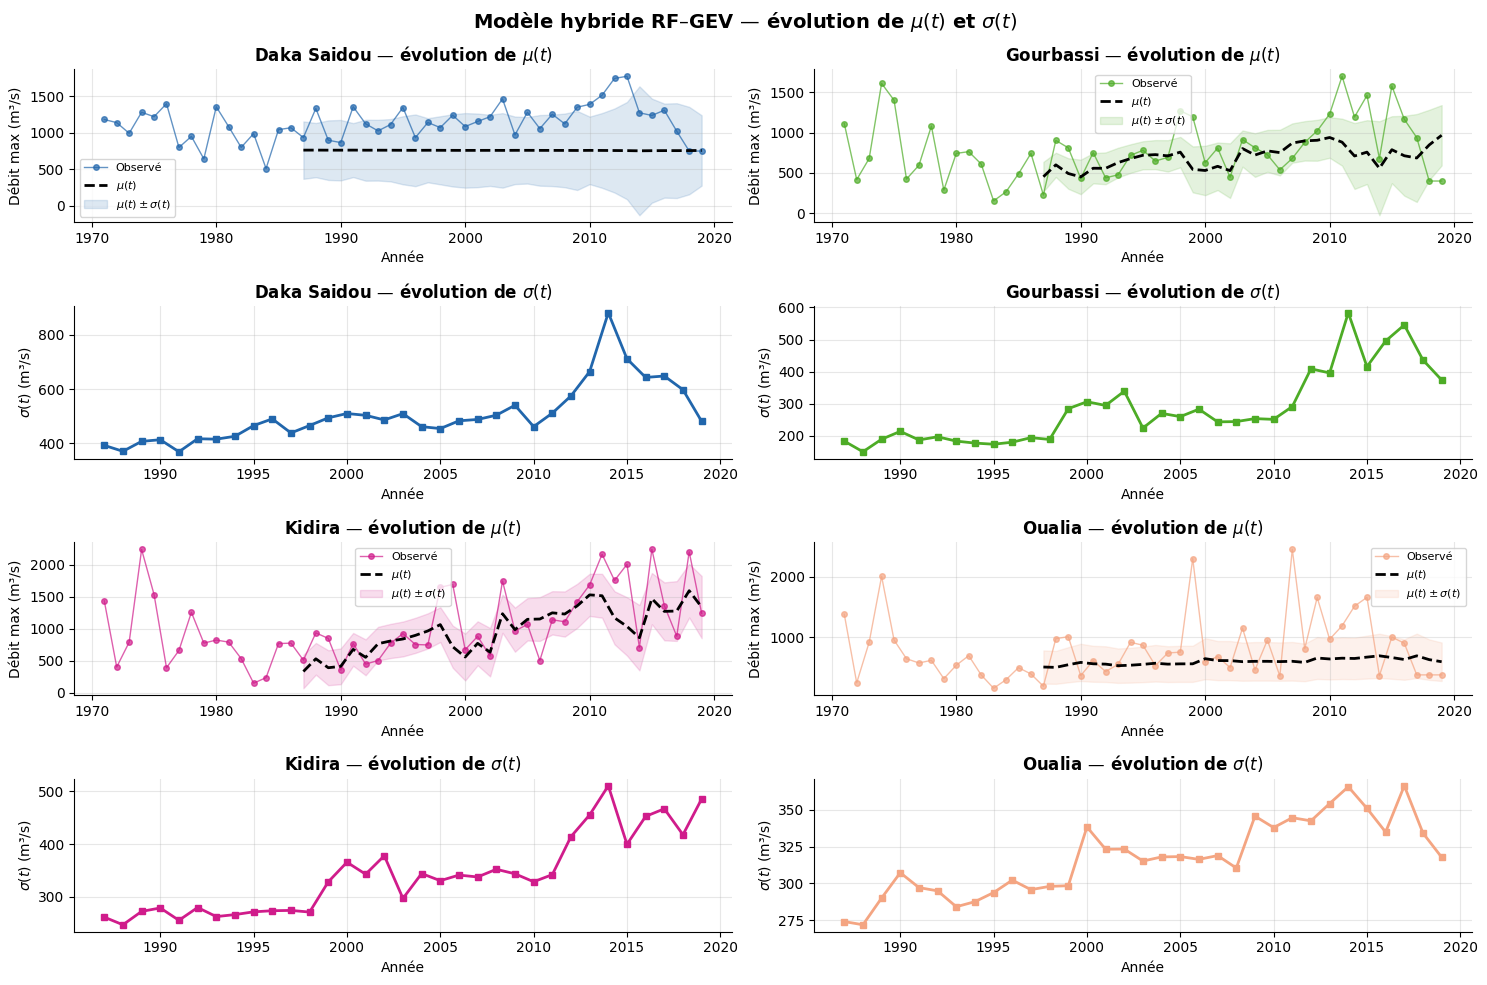

✔ Figure paramètres temporels sauvegardée.


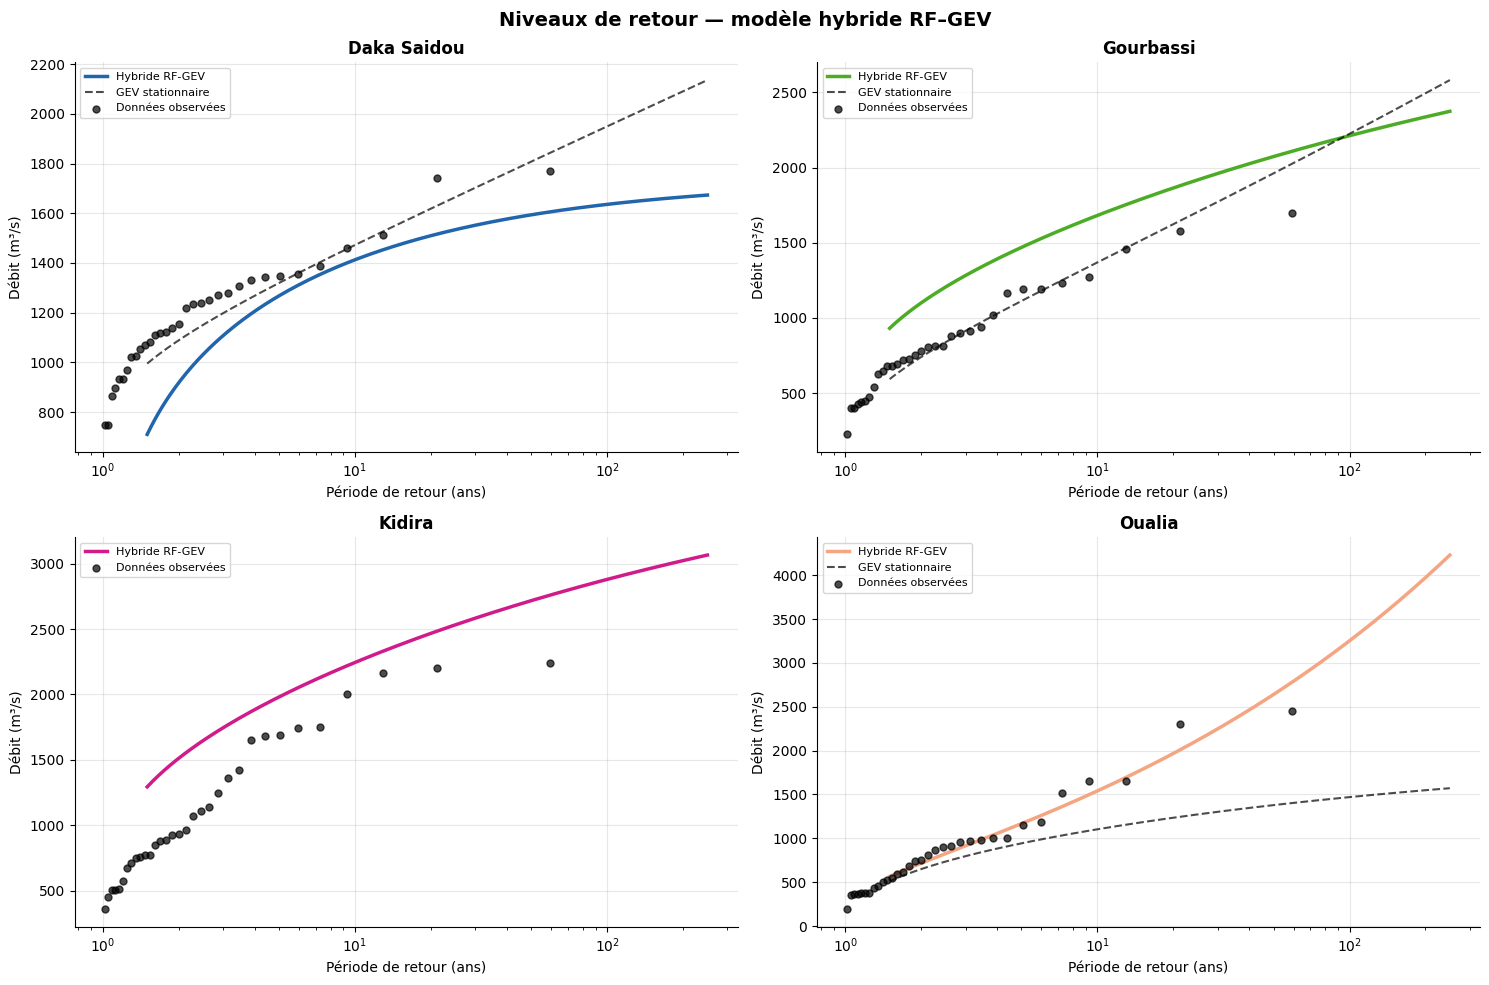

✔ Figure niveaux de retour sauvegardée.


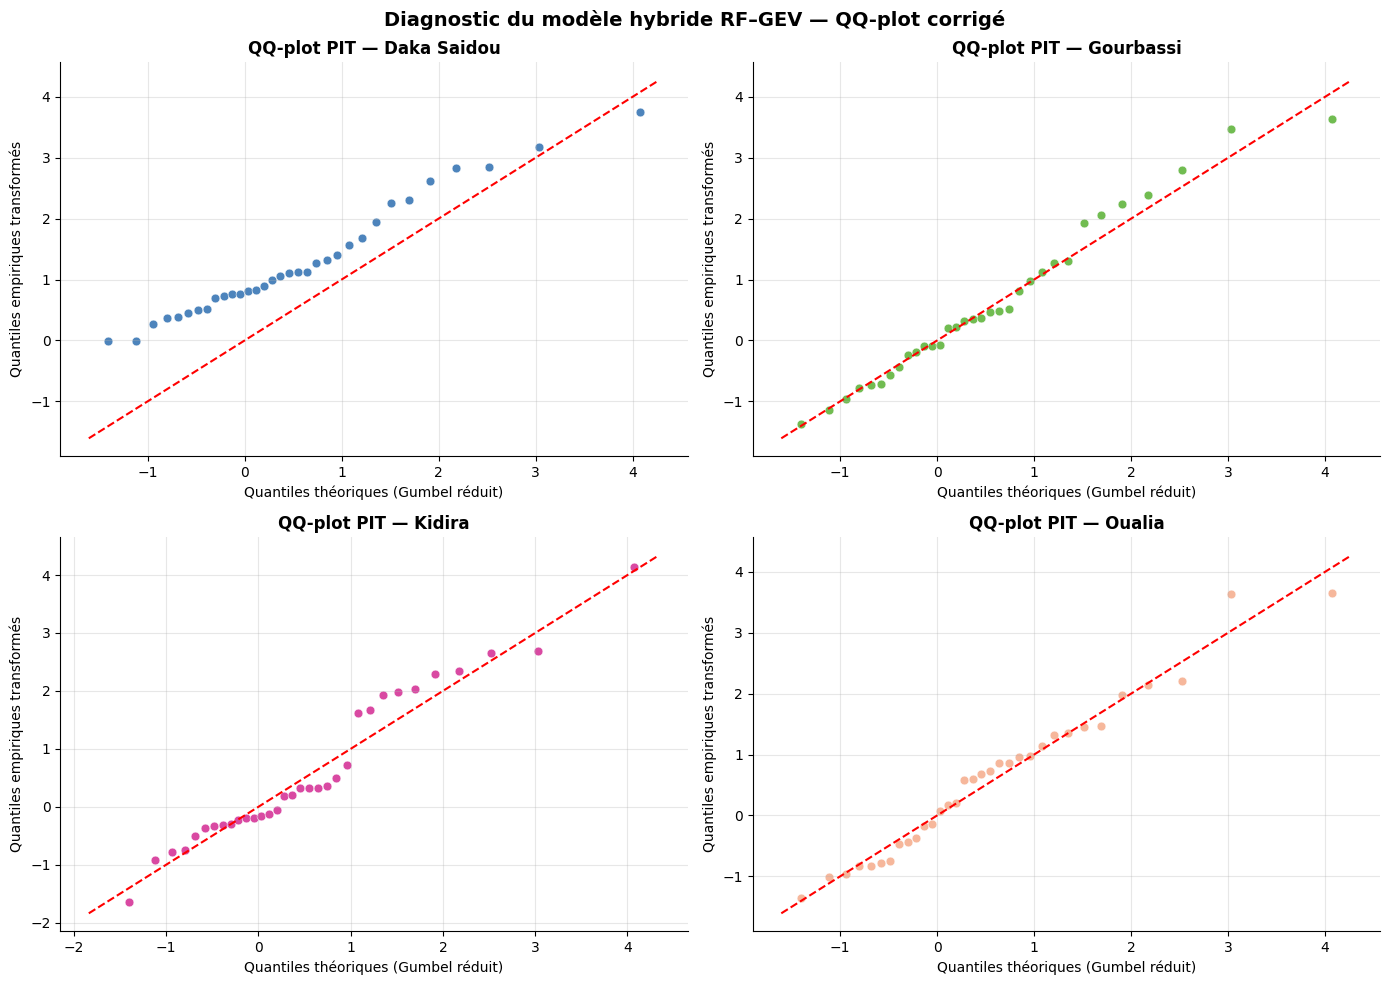

✔ Figure QQ-plot corrigée sauvegardée.

✔ Paramètres hybrides sauvegardés.
✔ Niveaux de retour hybrides sauvegardés.
✔ Comparaison AIC sauvegardée.
✔ Objet final disponible : hybrid_outputs
✔ Étape hybride RF–GEV terminée.


In [18]:
# ============================================================
# ANNEXE E — MODÈLE HYBRIDE RF-GEV (version corrigée)
# Architecture :
#   mu(t)     = beta0 + beta1 * Q_RF(t) + beta2 * Annee_c(t)
#   log sigma(t) = gamma0 + gamma1 * Q_RF(t)
#   xi = constant
# Convention :
#   xi = paramètre de forme "Coles"
#   scipy.stats.genextreme utilise c = -xi
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from scipy.optimize import minimize
from scipy.stats import genextreme
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

warnings.filterwarnings("ignore")
np.random.seed(42)

# ------------------------------------------------------------
# 0) Répertoire de sortie
# ------------------------------------------------------------
OUTPUT_DIR = Path("sorties_hybride_rf_gev")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 1) Vérifications minimales
# ------------------------------------------------------------
required_globals = ["dfs", "noms_stations", "features"]
for g in required_globals:
    if g not in globals():
        raise NameError(f"La variable globale '{g}' est requise mais absente.")

if "couleurs" not in globals() or not isinstance(couleurs, dict):
    cmap = plt.get_cmap("tab10")
    couleurs = {nom: cmap(i % 10) for i, nom in enumerate(noms_stations)}

# ------------------------------------------------------------
# 2) Fonctions utilitaires
# ------------------------------------------------------------
def standardize(x):
    x = np.asarray(x, dtype=float)
    mu = np.nanmean(x)
    sd = np.nanstd(x)
    if sd < 1e-12:
        return x * 0.0, mu, sd
    return (x - mu) / sd, mu, sd

def get_rf_params_for_station(station):
    """
    Utilise les meilleurs hyperparamètres RF s'ils existent,
    sinon applique une configuration par défaut raisonnable.
    """
    default_params = {
        "n_estimators": 300,
        "max_depth": 5,
        "min_samples_split": 2,
        "min_samples_leaf": 2,
        "max_features": "sqrt"
    }

    if "meilleurs_params_rf" in globals():
        if station in meilleurs_params_rf:
            params = default_params.copy()
            params.update(meilleurs_params_rf[station])
            return params

    return default_params

def fit_stationary_gev_init(x):
    """
    Ajustement stationnaire initial via SciPy.
    Retourne (mu0, sigma0, xi0) dans la convention Coles.
    """
    x = np.asarray(x, dtype=float)
    c0, loc0, scale0 = genextreme.fit(x)   # SciPy: c = -xi
    xi0 = -c0
    sigma0 = max(scale0, 1e-6)
    return loc0, sigma0, xi0

def neg_loglik_hybride(params, x, q_rf_z, year_z):
    """
    Log-vraisemblance négative de la GEV non stationnaire hybride.

    params = [beta0, beta1, beta2, gamma0, gamma1, xi]
    mu(t) = beta0 + beta1*q_rf_z + beta2*year_z
    sigma(t) = exp(gamma0 + gamma1*q_rf_z)
    xi constant
    """
    beta0, beta1, beta2, gamma0, gamma1, xi = params

    # borne de sécurité sur xi
    if not (-0.49 < xi < 0.49):
        return 1e12

    mu_t = beta0 + beta1 * q_rf_z + beta2 * year_z
    sigma_t = np.exp(gamma0 + gamma1 * q_rf_z)

    if np.any(~np.isfinite(mu_t)) or np.any(~np.isfinite(sigma_t)):
        return 1e12
    if np.any(sigma_t <= 1e-8):
        return 1e12

    # Convention scipy : c = -xi
    c_scipy = -xi
    logpdf = genextreme.logpdf(x, c=c_scipy, loc=mu_t, scale=sigma_t)

    if np.any(~np.isfinite(logpdf)):
        return 1e12

    return -np.sum(logpdf)

def get_hybrid_params_full(params, q_rf_z_full, year_z_full, valid_mask):
    """
    Calcule mu(t) et sigma(t) sur toute la série.
    Les observations sans prédiction RF hors échantillon restent en NaN.
    """
    beta0, beta1, beta2, gamma0, gamma1, xi = params

    mu_full = np.full(len(q_rf_z_full), np.nan, dtype=float)
    sigma_full = np.full(len(q_rf_z_full), np.nan, dtype=float)

    mu_full[valid_mask] = beta0 + beta1 * q_rf_z_full[valid_mask] + beta2 * year_z_full[valid_mask]
    sigma_full[valid_mask] = np.exp(gamma0 + gamma1 * q_rf_z_full[valid_mask])

    return mu_full, sigma_full

def expanding_oos_rf_predictions(X, y, rf_params, min_train_size=10):
    """
    Génère des prédictions réellement hors échantillon
    selon une logique expanding window :
    - on entraîne sur [0:t-1]
    - on prédit y[t]

    Les premières observations (avant min_train_size) restent à NaN.
    """
    X = np.asarray(X)
    y = np.asarray(y).ravel()

    n = len(y)
    if n <= min_train_size:
        raise ValueError(
            f"Série trop courte (n={n}) pour générer des prédictions OOS "
            f"avec min_train_size={min_train_size}."
        )

    preds = np.full(n, np.nan, dtype=float)

    for t in range(min_train_size, n):
        X_train = X[:t]
        y_train = y[:t]
        X_test = X[t:t+1]

        rf = RandomForestRegressor(
            **rf_params,
            random_state=42,
            n_jobs=-1
        )
        rf.fit(X_train, y_train)
        preds[t] = rf.predict(X_test)[0]

    return preds

def fit_hybrid_station(x, q_rf_oos, year):
    """
    Ajuste le modèle hybride seulement sur les observations
    disposant d'une prédiction RF réellement hors échantillon.
    """
    x = np.asarray(x, dtype=float)
    year = np.asarray(year, dtype=float)
    q_rf_oos = np.asarray(q_rf_oos, dtype=float)

    valid_mask = np.isfinite(q_rf_oos)
    if valid_mask.sum() < 15:
        raise ValueError("Trop peu d'observations valides pour ajuster le modèle hybride.")

    x_fit = x[valid_mask]
    q_fit = q_rf_oos[valid_mask]
    year_fit = year[valid_mask]

    q_rf_z, q_mu, q_sd = standardize(q_fit)
    year_z, y_mu, y_sd = standardize(year_fit)

    mu0, sigma0, xi0 = fit_stationary_gev_init(x_fit)

    params0 = np.array([
        mu0,              # beta0
        0.0,              # beta1
        0.0,              # beta2
        np.log(sigma0),   # gamma0
        0.0,              # gamma1
        np.clip(xi0, -0.3, 0.3)   # xi initial borné
    ], dtype=float)

    # bornes : plus robustes que Nelder-Mead libre
    x_scale = max(np.std(x_fit), 1.0)
    bounds = [
        (None, None),                # beta0
        (-5 * x_scale, 5 * x_scale), # beta1
        (-5 * x_scale, 5 * x_scale), # beta2
        (np.log(1e-3), np.log(1e5)), # gamma0
        (-5.0, 5.0),                 # gamma1
        (-0.49, 0.49)                # xi
    ]

    res = minimize(
        neg_loglik_hybride,
        x0=params0,
        args=(x_fit, q_rf_z, year_z),
        method="L-BFGS-B",
        bounds=bounds,
        options={"maxiter": 5000}
    )

    if not res.success:
        print("⚠ Optimisation non pleinement convergée :", res.message)

    params_hat = res.x
    loglik = -res.fun
    k = len(params_hat)
    n_fit = len(x_fit)
    aic = 2 * k - 2 * loglik
    bic = np.log(n_fit) * k - 2 * loglik

    if (n_fit - k - 1) > 0:
        aicc = aic + (2 * k * (k + 1)) / (n_fit - k - 1)
    else:
        aicc = np.nan

    # standardisation pleine série pour les graphiques
    q_full_z = np.full(len(x), np.nan)
    q_full_z[valid_mask] = (q_rf_oos[valid_mask] - q_mu) / q_sd if q_sd > 1e-12 else 0.0

    year_full_z = np.full(len(x), np.nan)
    year_full_z[valid_mask] = (year[valid_mask] - y_mu) / y_sd if y_sd > 1e-12 else 0.0

    mu_full, sigma_full = get_hybrid_params_full(
        params_hat, q_full_z, year_full_z, valid_mask
    )

    return {
        "params": params_hat,
        "loglik": loglik,
        "AIC": aic,
        "AICc": aicc,
        "BIC": bic,
        "valid_mask": valid_mask,
        "q_rf_oos": q_rf_oos,
        "q_rf_z_full": q_full_z,
        "year_z_full": year_full_z,
        "mu_full": mu_full,
        "sigma_full": sigma_full,
        "x": x,
        "year": year
    }

def compute_return_levels_current(model_dict, periodes):
    """
    Niveaux de retour calculés pour la dernière observation valide.
    """
    params = model_dict["params"]
    beta0, beta1, beta2, gamma0, gamma1, xi = params

    valid_idx = np.where(model_dict["valid_mask"])[0]
    idx_last = valid_idx[-1]

    q_last = model_dict["q_rf_z_full"][idx_last]
    year_last = model_dict["year_z_full"][idx_last]

    mu_last = beta0 + beta1 * q_last + beta2 * year_last
    sigma_last = np.exp(gamma0 + gamma1 * q_last)

    out = []
    for T in periodes:
        p = 1 - 1 / T
        rl = genextreme.ppf(p, c=-xi, loc=mu_last, scale=sigma_last)
        out.append({
            "Annee": int(model_dict["year"][idx_last]),
            "Periode": T,
            "ReturnLevel": rl,
            "mu_t": mu_last,
            "sigma_t": sigma_last,
            "xi": xi
        })
    return out

def extract_stationary_aic(resultats_gev_df, station):
    """
    Extrait l'AIC du modèle GEV stationnaire si disponible.
    """
    if resultats_gev_df is None:
        return np.nan
    if "Station" not in resultats_gev_df.columns or "AIC" not in resultats_gev_df.columns:
        return np.nan

    row = resultats_gev_df.loc[resultats_gev_df["Station"] == station]
    if row.empty:
        return np.nan
    return float(row["AIC"].iloc[0])

def get_stationary_gev_curve(station, p_range):
    """
    Essaie de récupérer une courbe GEV stationnaire pour comparaison.
    Supporte :
    - tuple/list : (shape_scipy, loc, scale)
    - dict avec clés {'shape', 'loc', 'scale'}
    - dict avec clés {'xi', 'mu', 'sigma'} en convention Coles
    """
    if "modeles_gev" not in globals():
        return None

    if station not in modeles_gev:
        return None

    obj = modeles_gev[station]

    try:
        if isinstance(obj, (tuple, list)) and len(obj) == 3:
            shape_scipy, loc, scale = obj
            return genextreme.ppf(p_range, c=shape_scipy, loc=loc, scale=scale)

        if isinstance(obj, dict):
            if {"shape", "loc", "scale"}.issubset(obj.keys()):
                return genextreme.ppf(p_range, c=obj["shape"], loc=obj["loc"], scale=obj["scale"])
            if {"xi", "mu", "sigma"}.issubset(obj.keys()):
                return genextreme.ppf(p_range, c=-obj["xi"], loc=obj["mu"], scale=obj["sigma"])
    except Exception:
        return None

    return None

# ------------------------------------------------------------
# 3) Boucle principale
# ------------------------------------------------------------
print("=" * 70)
print("MODÈLE HYBRIDE RF–GEV (version corrigée)")
print("=" * 70)

periodes = [2, 5, 10, 20, 50, 100, 200]

modeles_hybride = {}
resultats_hybride = []
niveaux_retour_hybride = []
comparaison_aic = []

resultats_gev_ref = globals().get("resultats_gev_df", None)

for station in noms_stations:
    print(f"\n{'='*55}")
    print(f"Station : {station}")
    print(f"{'='*55}")

    if station not in dfs:
        print(f"⚠ Station absente de dfs : {station}")
        continue

    df = dfs[station].copy()

    required_cols = ["y", "annee"] + list(features)
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise KeyError(f"Colonnes manquantes pour {station} : {missing_cols}")

    df = df.dropna(subset=required_cols).reset_index(drop=True)

    x = df["y"].to_numpy(dtype=float)
    year = df["annee"].to_numpy(dtype=float)
    X = df[features].to_numpy(dtype=float)

    rf_params = get_rf_params_for_station(station)
    print("Paramètres RF utilisés :", rf_params)

    # Prédictions RF réellement hors échantillon
    min_train_size = max(10, len(df) // 3)
    q_rf_oos = expanding_oos_rf_predictions(
        X=X,
        y=x,
        rf_params=rf_params,
        min_train_size=min_train_size
    )

    valid_mask = np.isfinite(q_rf_oos)
    corr_rf_obs = np.corrcoef(q_rf_oos[valid_mask], x[valid_mask])[0, 1]
    rmse_rf_oos = np.sqrt(mean_squared_error(x[valid_mask], q_rf_oos[valid_mask]))

    print(f"Corrélation RF-OOS / Observé : {corr_rf_obs:.3f}")
    print(f"RMSE RF hors échantillon     : {rmse_rf_oos:.2f}")
    print(f"Observations valides hybride : {valid_mask.sum()} / {len(valid_mask)}")

    # Ajustement hybride
    fit = fit_hybrid_station(x=x, q_rf_oos=q_rf_oos, year=year)

    beta0, beta1, beta2, gamma0, gamma1, xi = fit["params"]

    print("\nParamètres estimés du modèle hybride :")
    print(f"beta0 = {beta0:.4f}")
    print(f"beta1 = {beta1:.4f}")
    print(f"beta2 = {beta2:.4f}")
    print(f"gamma0 = {gamma0:.4f}")
    print(f"gamma1 = {gamma1:.4f}")
    print(f"xi     = {xi:.4f}")
    print(f"logLik = {fit['loglik']:.3f}")
    print(f"AIC    = {fit['AIC']:.3f}")
    print(f"AICc   = {fit['AICc']:.3f}")
    print(f"BIC    = {fit['BIC']:.3f}")

    modeles_hybride[station] = fit

    resultats_hybride.append({
        "Station": station,
        "beta0": beta0,
        "beta1": beta1,
        "beta2": beta2,
        "gamma0": gamma0,
        "gamma1": gamma1,
        "xi": xi,
        "logLik": fit["loglik"],
        "AIC": fit["AIC"],
        "AICc": fit["AICc"],
        "BIC": fit["BIC"],
        "RMSE_RF_OOS": rmse_rf_oos,
        "Corr_RF_OOS": corr_rf_obs,
        "n_valid": int(fit["valid_mask"].sum())
    })

    # Niveaux de retour
    rl_station = compute_return_levels_current(fit, periodes)
    for item in rl_station:
        niveaux_retour_hybride.append({
            "Station": station,
            **item
        })

    # Comparaison AIC avec GEV stationnaire si disponible
    aic_stat = extract_stationary_aic(resultats_gev_ref, station)
    comparaison_aic.append({
        "Station": station,
        "AIC_GEV_stat": aic_stat,
        "AIC_Hybride": fit["AIC"],
        "Gain_AIC": aic_stat - fit["AIC"] if np.isfinite(aic_stat) else np.nan,
        "Modele_retenu": (
            "Hybride RF-GEV"
            if np.isfinite(aic_stat) and fit["AIC"] < aic_stat
            else "GEV stationnaire" if np.isfinite(aic_stat)
            else "Non comparable"
        )
    })

# ------------------------------------------------------------
# 4) Tableaux
# ------------------------------------------------------------
resultats_hybride_df = pd.DataFrame(resultats_hybride)
nr_hybride_df = pd.DataFrame(niveaux_retour_hybride)
comparaison_aic_df = pd.DataFrame(comparaison_aic)

print("\n=== Paramètres du modèle hybride ===")
print(resultats_hybride_df.round(3))

print("\n=== Niveaux de retour hybrides ===")
print(nr_hybride_df.round(2))

print("\n=== Comparaison AIC ===")
print(comparaison_aic_df.round(2))

resultats_hybride_df.to_csv(OUTPUT_DIR / "hybride_parametres.csv", index=False)
nr_hybride_df.to_csv(OUTPUT_DIR / "hybride_niveaux_retour.csv", index=False)
comparaison_aic_df.to_csv(OUTPUT_DIR / "hybride_comparaison_aic.csv", index=False)

# ------------------------------------------------------------
# 5) Figure 1 — Evolution temporelle de mu(t) et sigma(t)
# ------------------------------------------------------------
n_stations = len(modeles_hybride)
ncols = 2
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(2 * nrows, ncols, figsize=(15, 5 * nrows))
axes = np.atleast_2d(axes)

stations_fit = list(modeles_hybride.keys())

for idx, station in enumerate(stations_fit):
    row_mu = (idx // ncols) * 2
    col = idx % ncols
    row_sig = row_mu + 1

    ax_mu = axes[row_mu, col]
    ax_sig = axes[row_sig, col]

    mdl = modeles_hybride[station]
    year = mdl["year"]
    x = mdl["x"]
    mu_t = mdl["mu_full"]
    sigma_t = mdl["sigma_full"]
    valid = mdl["valid_mask"]

    ax_mu.plot(year, x, color=couleurs[station], marker="o", markersize=4,
               linewidth=1, alpha=0.7, label="Observé")
    ax_mu.plot(year[valid], mu_t[valid], color="black", linestyle="--",
               linewidth=2, label=r"$\mu(t)$")
    ax_mu.fill_between(year[valid],
                       mu_t[valid] - sigma_t[valid],
                       mu_t[valid] + sigma_t[valid],
                       color=couleurs[station], alpha=0.15,
                       label=r"$\mu(t)\pm\sigma(t)$")
    ax_mu.set_title(f"{station} — évolution de $\\mu(t)$", fontweight="bold")
    ax_mu.set_xlabel("Année")
    ax_mu.set_ylabel("Débit max (m³/s)")
    ax_mu.grid(True, alpha=0.3)
    ax_mu.legend(fontsize=8)
    ax_mu.spines["top"].set_visible(False)
    ax_mu.spines["right"].set_visible(False)

    ax_sig.plot(year[valid], sigma_t[valid], color=couleurs[station],
                linewidth=2, marker="s", markersize=4)
    ax_sig.set_title(f"{station} — évolution de $\\sigma(t)$", fontweight="bold")
    ax_sig.set_xlabel("Année")
    ax_sig.set_ylabel(r"$\sigma(t)$ (m³/s)")
    ax_sig.grid(True, alpha=0.3)
    ax_sig.spines["top"].set_visible(False)
    ax_sig.spines["right"].set_visible(False)

# supprimer axes vides
total_axes = 2 * nrows * ncols
used_axes = 2 * len(stations_fit)
flat_axes = axes.flatten()
for k in range(used_axes, total_axes):
    fig.delaxes(flat_axes[k])

plt.suptitle("Modèle hybride RF–GEV — évolution de $\\mu(t)$ et $\\sigma(t)$",
             fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "hybride_parametres_temporels.png", dpi=300, bbox_inches="tight")
plt.show()

print("✔ Figure paramètres temporels sauvegardée.")

# ------------------------------------------------------------
# 6) Figure 2 — Niveaux de retour hybrides
# ------------------------------------------------------------
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5 * nrows))
axes = np.atleast_1d(axes).flatten()

T_range = np.logspace(np.log10(1.5), np.log10(250), 300)
p_range = 1 - 1 / T_range

for i, station in enumerate(stations_fit):
    ax = axes[i]
    mdl = modeles_hybride[station]
    params = mdl["params"]
    beta0, beta1, beta2, gamma0, gamma1, xi = params

    valid_idx = np.where(mdl["valid_mask"])[0]
    idx_last = valid_idx[-1]

    q_last = mdl["q_rf_z_full"][idx_last]
    year_last = mdl["year_z_full"][idx_last]

    mu_last = beta0 + beta1 * q_last + beta2 * year_last
    sigma_last = np.exp(gamma0 + gamma1 * q_last)

    rl_curve = genextreme.ppf(p_range, c=-xi, loc=mu_last, scale=sigma_last)

    ax.plot(T_range, rl_curve, color=couleurs[station], linewidth=2.5,
            label="Hybride RF-GEV")

    # courbe stationnaire si disponible
    stat_curve = get_stationary_gev_curve(station, p_range)
    if stat_curve is not None:
        ax.plot(T_range, stat_curve, color="black", linestyle="--",
                linewidth=1.5, alpha=0.7, label="GEV stationnaire")

    # points empiriques
    x_valid = mdl["x"][mdl["valid_mask"]]
    x_sort = np.sort(x_valid)
    n = len(x_sort)
    p_emp = (np.arange(1, n + 1) - 0.44) / (n + 0.12)
    T_emp = 1 / (1 - p_emp)

    ax.scatter(T_emp, x_sort, color="black", s=25, alpha=0.7, zorder=5,
               label="Données observées")

    ax.set_xscale("log")
    ax.set_title(station, fontweight="bold")
    ax.set_xlabel("Période de retour (ans)")
    ax.set_ylabel("Débit (m³/s)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Niveaux de retour — modèle hybride RF–GEV",
             fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "hybride_niveaux_retour.png", dpi=300, bbox_inches="tight")
plt.show()

print("✔ Figure niveaux de retour sauvegardée.")

# ------------------------------------------------------------
# 7) Figure 3 — Diagnostic QQ-plot corrigé via PIT
# ------------------------------------------------------------
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows))
axes = np.atleast_1d(axes).flatten()

for i, station in enumerate(stations_fit):
    ax = axes[i]
    mdl = modeles_hybride[station]
    valid = mdl["valid_mask"]

    x = mdl["x"][valid]
    mu_t = mdl["mu_full"][valid]
    sigma_t = mdl["sigma_full"][valid]
    xi = mdl["params"][-1]

    # PIT : u_t = F_t(x_t)
    u = genextreme.cdf(x, c=-xi, loc=mu_t, scale=sigma_t)

    # éviter 0 et 1 exacts
    u = np.clip(u, 1e-6, 1 - 1e-6)

    # variable réduite Gumbel
    z_emp = np.sort(-np.log(-np.log(u)))

    n = len(z_emp)
    p_emp = (np.arange(1, n + 1) - 0.44) / (n + 0.12)
    z_theo = -np.log(-np.log(p_emp))

    ax.scatter(z_theo, z_emp, color=couleurs[station], s=40,
               alpha=0.8, edgecolors="white", linewidth=0.5)

    lim_min = min(z_theo.min(), z_emp.min()) - 0.2
    lim_max = max(z_theo.max(), z_emp.max()) + 0.2
    ax.plot([lim_min, lim_max], [lim_min, lim_max], "r--", linewidth=1.5)

    ax.set_title(f"QQ-plot PIT — {station}", fontweight="bold")
    ax.set_xlabel("Quantiles théoriques (Gumbel réduit)")
    ax.set_ylabel("Quantiles empiriques transformés")
    ax.grid(True, alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Diagnostic du modèle hybride RF–GEV — QQ-plot corrigé",
             fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "hybride_qqplot_corrige.png", dpi=300, bbox_inches="tight")
plt.show()

print("✔ Figure QQ-plot corrigée sauvegardée.")

# ------------------------------------------------------------
# 8) Objet final réutilisable
# ------------------------------------------------------------
hybrid_outputs = {
    "modeles_hybride": modeles_hybride,
    "resultats_hybride_df": resultats_hybride_df,
    "nr_hybride_df": nr_hybride_df,
    "comparaison_aic_df": comparaison_aic_df,
    "output_dir": OUTPUT_DIR
}

print("\n✔ Paramètres hybrides sauvegardés.")
print("✔ Niveaux de retour hybrides sauvegardés.")
print("✔ Comparaison AIC sauvegardée.")
print("✔ Objet final disponible : hybrid_outputs")
print("✔ Étape hybride RF–GEV terminée.")
